# MARBERT Parameter-Efficient Adaptation Experiments

## Final Controlled Experimental Pipeline

This notebook implements the final experimental protocol for evaluating parameter-efficient adaptation strategies on Arabic social-media classification using MARBERT.

### Tasks

Two supervised classification tasks are evaluated:

1. **Hate and Offensive Language Detection (HOF)**
   - Clean
   - Hate/Offensive (HOF)

2. **Sentiment Classification**
   - Positive
   - Negative
   - Neutral

### Backbone

All experiments use the same pretrained language model:

**UBC-NLP/MARBERT**

The backbone is intentionally fixed so that the study isolates the effect of the adaptation strategy rather than differences between pretrained language models.

### Adaptation Strategies

The main comparison includes:

- Full fine-tuning
- Frozen encoder
- LoRA-r8
- LoRA-r16
- LoRA-r32
- IA³
- AdaLoRA
- DoRA-r16

### Experimental Principles

The final protocol follows these principles:

- the same cleaned corpus is used for both tasks;
- the same train/validation/test partitions are used for all methods;
- duplicate canonical texts cannot cross partitions;
- conflicting duplicate groups were removed during dataset preparation;
- no new data split is created in this notebook;
- the test set is never used for model selection;
- validation Macro-F1 is the model-selection criterion;
- all main experiments use seed 42;
- all main experiments use the same effective batch size;
- early stopping is applied using validation Macro-F1;
- the best validation checkpoint is evaluated once on the fixed test set;
- per-class and aggregate metrics are retained;
- individual test predictions are saved for paired statistical testing;
- computational efficiency is measured separately from predictive effectiveness;
- GPU-memory comparisons are additionally evaluated under a standardized controlled protocol.

### Reproducibility

The notebook records:

- software versions;
- CUDA and GPU information;
- dataset hashes;
- dataset sizes and class distributions;
- random seeds;
- model configurations;
- training histories;
- best checkpoints;
- test predictions;
- per-class reports;
- confusion matrices;
- efficiency measurements;
- statistical comparisons.

The resulting artifacts are intended to support transparent reproduction of the reported experiments.

## 1. Environment and Reproducibility Check

Before loading the dataset or constructing any model, the computational environment is inspected.

This step verifies:

- Python version;
- PyTorch version;
- Transformers version;
- PEFT version;
- CUDA availability;
- CUDA runtime;
- GPU model;
- available GPU memory;
- required scientific Python libraries.

PyTorch is not installed or upgraded inside this notebook because the existing CUDA-enabled environment has already been validated. Changing the PyTorch build during the experiment could alter the software stack and compromise reproducibility.

In [2]:
# ============================================================
# CELL 3 — ENVIRONMENT AND SOFTWARE VERIFICATION
# ============================================================

import os
import sys
import gc
import json
import math
import time
import random
import hashlib
import shutil
import platform
import warnings
from pathlib import Path
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd

import torch

# ------------------------------------------------------------
# Helper: safe package-version lookup
# ------------------------------------------------------------

def package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "NOT INSTALLED"


# ------------------------------------------------------------
# Basic environment information
# ------------------------------------------------------------

print("=" * 90)
print("MARBERT FINAL REVIEWER EXPERIMENTS")
print("ENVIRONMENT VERIFICATION")
print("=" * 90)

print(f"Timestamp              : {datetime.now().isoformat()}")
print(f"Operating system       : {platform.platform()}")
print(f"Python executable      : {sys.executable}")
print(f"Python version         : {sys.version.split()[0]}")

print()
print("CORE PACKAGES")
print("-" * 90)

packages = {
    "torch": package_version("torch"),
    "transformers": package_version("transformers"),
    "peft": package_version("peft"),
    "datasets": package_version("datasets"),
    "accelerate": package_version("accelerate"),
    "safetensors": package_version("safetensors"),
    "huggingface-hub": package_version("huggingface-hub"),
    "scikit-learn": package_version("scikit-learn"),
    "scipy": package_version("scipy"),
    "pandas": package_version("pandas"),
    "numpy": package_version("numpy"),
    "pyarrow": package_version("pyarrow"),
    "openpyxl": package_version("openpyxl"),
    "xlsxwriter": package_version("xlsxwriter"),
    "nvidia-ml-py": package_version("nvidia-ml-py"),
    "psutil": package_version("psutil"),
}

for name, ver in packages.items():
    print(f"{name:<22}: {ver}")


# ------------------------------------------------------------
# CUDA verification
# ------------------------------------------------------------

print()
print("CUDA / GPU")
print("-" * 90)

print(f"PyTorch version        : {torch.__version__}")
print(f"PyTorch CUDA runtime   : {torch.version.cuda}")
print(f"CUDA available         : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. "
        "Do not start the experiments until the GPU environment is fixed."
    )

gpu_index = 0

gpu_name = torch.cuda.get_device_name(gpu_index)
gpu_properties = torch.cuda.get_device_properties(gpu_index)

total_gpu_gb = gpu_properties.total_memory / (1024 ** 3)

print(f"GPU                    : {gpu_name}")
print(f"CUDA device index      : {gpu_index}")
print(f"Total GPU memory       : {total_gpu_gb:.3f} GB")
print(f"CUDA capability        : {gpu_properties.major}.{gpu_properties.minor}")


# ------------------------------------------------------------
# Confirm required packages
# ------------------------------------------------------------

required_packages = [
    "transformers",
    "peft",
    "datasets",
    "accelerate",
    "safetensors",
    "scikit-learn",
    "scipy",
    "pandas",
    "numpy",
    "pyarrow",
    "openpyxl",
    "xlsxwriter",
    "psutil",
]

missing_packages = [
    pkg
    for pkg in required_packages
    if package_version(pkg) == "NOT INSTALLED"
]

if missing_packages:
    raise RuntimeError(
        "Missing required packages:\n"
        + "\n".join(f" - {pkg}" for pkg in missing_packages)
    )


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("=" * 90)
print("ENVIRONMENT CHECK: PASSED")
print("=" * 90)

MARBERT FINAL REVIEWER EXPERIMENTS
ENVIRONMENT VERIFICATION
Timestamp              : 2026-08-12T09:36:53.791478
Operating system       : Windows-10-10.0.26200-SP0
Python executable      : C:\Users\bitl19\anaconda3\envs\nlp5060\python.exe
Python version         : 3.11.15

CORE PACKAGES
------------------------------------------------------------------------------------------
torch                 : 2.12.0+cu130
transformers          : 5.14.1
peft                  : 0.19.1
datasets              : 5.0.0
accelerate            : 1.14.0
safetensors           : 0.8.0
huggingface-hub       : 1.24.0
scikit-learn          : 1.9.0
scipy                 : 1.17.1
pandas                : 3.0.3
numpy                 : 2.4.4
pyarrow               : 25.0.0
openpyxl              : 3.1.5
xlsxwriter            : 3.2.9
nvidia-ml-py          : 13.610.43
psutil                : 7.2.2

CUDA / GPU
------------------------------------------------------------------------------------------
PyTorch version        

## 2. Project Directory Structure

A dedicated experiment directory is used to separate:

- prepared datasets;
- tokenizer caches;
- main experiments;
- sensitivity experiments;
- statistical analyses;
- reproducibility metadata;
- controlled GPU-memory benchmarks.

The original audited partitions are preserved unchanged. They are copied from the previous data-preparation stage into the final experiment directory only when necessary.

This notebook does **not** regenerate, reshuffle, or re-stratify the dataset.

In [3]:
# ============================================================
# CELL 5 — PROJECT DIRECTORY STRUCTURE
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Main project
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"D:\Informatics\MARBERT_Final_Reviewer_Experiments"
)


# ------------------------------------------------------------
# Source of the already-audited unified splits
# ------------------------------------------------------------

SOURCE_PREPARED_DATA = Path(
    r"D:\Russia\MARBERT_Reviewer_Experiments\02_prepared_data"
)


# ------------------------------------------------------------
# Final project folders
# ------------------------------------------------------------

PREPARED_DATA_DIR = PROJECT_ROOT / "02_prepared_data"
TOKENIZED_DIR = PROJECT_ROOT / "03_tokenized"
MAIN_RUNS_DIR = PROJECT_ROOT / "04_main_runs"
SENSITIVITY_DIR = PROJECT_ROOT / "05_sensitivity"
ANALYSIS_DIR = PROJECT_ROOT / "06_analysis"
REPRO_DIR = PROJECT_ROOT / "07_reproducibility"
GPU_BENCHMARK_DIR = PROJECT_ROOT / "08_controlled_gpu_benchmark"


ALL_DIRS = [
    PROJECT_ROOT,
    PREPARED_DATA_DIR,
    TOKENIZED_DIR,
    MAIN_RUNS_DIR,
    SENSITIVITY_DIR,
    ANALYSIS_DIR,
    REPRO_DIR,
    GPU_BENCHMARK_DIR,
]


for directory in ALL_DIRS:
    directory.mkdir(parents=True, exist_ok=True)


print("=" * 90)
print("PROJECT DIRECTORY STRUCTURE")
print("=" * 90)

for directory in ALL_DIRS:
    print(directory)

print()
print("Directory setup: PASSED")

PROJECT DIRECTORY STRUCTURE
D:\Informatics\MARBERT_Final_Reviewer_Experiments
D:\Informatics\MARBERT_Final_Reviewer_Experiments\02_prepared_data
D:\Informatics\MARBERT_Final_Reviewer_Experiments\03_tokenized
D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs
D:\Informatics\MARBERT_Final_Reviewer_Experiments\05_sensitivity
D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis
D:\Informatics\MARBERT_Final_Reviewer_Experiments\07_reproducibility
D:\Informatics\MARBERT_Final_Reviewer_Experiments\08_controlled_gpu_benchmark

Directory setup: PASSED


## 3. Import the Fixed Audited Dataset Splits

The final experiments reuse the unified partitions created during the dedicated data-preparation stage.

Expected partition sizes are:

| Partition | Number of comments |
|---|---:|
| Train | 274,057 |
| Validation | 58,726 |
| Test | 58,727 |
| **Total** | **391,510** |

The same records are used for HOF and sentiment classification.

To prevent accidental modification, the files are copied only when they are absent from the final project directory. If a destination file already exists, its SHA-256 hash is compared with the source file instead of silently overwriting it.

In [4]:
# ============================================================
# CELL 7 — COPY AND VERIFY FIXED DATASET FILES
# ============================================================

EXPECTED_FILES = [
    "train.csv",
    "validation.csv",
    "test.csv",
    "clean_dual_label_corpus.csv",
    "dataset_manifest.json",
]


def sha256_file(path, chunk_size=1024 * 1024):
    """
    Compute SHA-256 hash without loading the complete file into memory.
    """
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


print("=" * 90)
print("FIXED DATASET IMPORT")
print("=" * 90)


# ------------------------------------------------------------
# Verify source directory
# ------------------------------------------------------------

if not SOURCE_PREPARED_DATA.exists():
    raise FileNotFoundError(
        f"Source prepared-data folder does not exist:\n"
        f"{SOURCE_PREPARED_DATA}"
    )


# ------------------------------------------------------------
# Copy or verify each file
# ------------------------------------------------------------

copy_report = {}

for filename in EXPECTED_FILES:

    source = SOURCE_PREPARED_DATA / filename
    destination = PREPARED_DATA_DIR / filename

    if not source.exists():
        raise FileNotFoundError(
            f"Required source file is missing:\n{source}"
        )

    source_hash = sha256_file(source)

    if destination.exists():

        destination_hash = sha256_file(destination)

        if source_hash != destination_hash:
            raise RuntimeError(
                f"Existing destination differs from source:\n"
                f"{destination}\n\n"
                f"Source SHA256      : {source_hash}\n"
                f"Destination SHA256 : {destination_hash}\n\n"
                f"File was NOT overwritten."
            )

        status = "EXISTS — HASH MATCH"

    else:

        shutil.copy2(source, destination)

        destination_hash = sha256_file(destination)

        if source_hash != destination_hash:
            raise RuntimeError(
                f"Hash mismatch after copying {filename}"
            )

        status = "COPIED"


    copy_report[filename] = {
        "source": str(source),
        "destination": str(destination),
        "sha256": source_hash,
        "status": status,
    }

    print(f"{filename:<32} {status}")


# ------------------------------------------------------------
# Save provenance information
# ------------------------------------------------------------

copy_manifest_path = REPRO_DIR / "data_copy_manifest.json"

with open(copy_manifest_path, "w", encoding="utf-8") as f:
    json.dump(
        copy_report,
        f,
        indent=2,
        ensure_ascii=False,
    )


print()
print(f"Manifest saved to: {copy_manifest_path}")

print()
print("=" * 90)
print("DATASET COPY/HASH CHECK: PASSED")
print("=" * 90)

FIXED DATASET IMPORT
train.csv                        EXISTS — HASH MATCH
validation.csv                   EXISTS — HASH MATCH
test.csv                         EXISTS — HASH MATCH
clean_dual_label_corpus.csv      EXISTS — HASH MATCH
dataset_manifest.json            EXISTS — HASH MATCH

Manifest saved to: D:\Informatics\MARBERT_Final_Reviewer_Experiments\07_reproducibility\data_copy_manifest.json

DATASET COPY/HASH CHECK: PASSED


## 4. Dataset Integrity and Leakage Audit

Before model training, the fixed partitions are independently verified.

The audit checks:

1. expected partition sizes;
2. required columns;
3. valid HOF labels;
4. valid sentiment labels;
5. the dataset constraint that every HOF comment is labeled Negative for sentiment;
6. absence of ID overlap across train, validation, and test;
7. absence of canonical-text overlap across partitions;
8. absence of duplicate canonical-text representatives within each split;
9. class distributions;
10. joint-label distributions;
11. SHA-256 hashes of the final experiment files.

Failure of any critical assertion terminates the experiment before model training.

In [5]:
# ============================================================
# CELL 9 — LOAD AND AUDIT THE FINAL FIXED SPLITS
# ============================================================

TRAIN_PATH = PREPARED_DATA_DIR / "train.csv"
VAL_PATH = PREPARED_DATA_DIR / "validation.csv"
TEST_PATH = PREPARED_DATA_DIR / "test.csv"


print("=" * 90)
print("LOADING FIXED SPLITS")
print("=" * 90)

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)


# ------------------------------------------------------------
# Expected sizes
# ------------------------------------------------------------

EXPECTED_SIZES = {
    "train": 274_057,
    "validation": 58_726,
    "test": 58_727,
}


actual_sizes = {
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
}


print("Dataset sizes")
print("-" * 90)

for split, size in actual_sizes.items():
    expected = EXPECTED_SIZES[split]

    print(
        f"{split:<15}: "
        f"{size:,} "
        f"(expected {expected:,})"
    )

    assert size == expected, (
        f"{split} size mismatch: "
        f"expected {expected:,}, got {size:,}"
    )


assert sum(actual_sizes.values()) == 391_510


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

BASE_REQUIRED_COLUMNS = {
    "ID",
    "Comments",
    "hate_binary",
    "sentiment_2",
}


for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    missing = BASE_REQUIRED_COLUMNS - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{split_name} is missing columns: {sorted(missing)}"
        )


print()
print("Required columns: PASSED")


# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    missing = df[list(BASE_REQUIRED_COLUMNS)].isna().sum()

    if missing.sum() != 0:
        print()
        print(f"Missing values in {split_name}:")
        print(missing)

        raise RuntimeError(
            f"Required-column missing values detected in {split_name}"
        )


print("Required-field missing-value check: PASSED")


# ------------------------------------------------------------
# Label domains
# ------------------------------------------------------------

EXPECTED_HOF_LABELS = {0, 1}
EXPECTED_SENTIMENT_LABELS = {0, 1, 2}


for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    hof_labels = set(
        df["hate_binary"]
        .astype(int)
        .unique()
        .tolist()
    )

    sent_labels = set(
        df["sentiment_2"]
        .astype(int)
        .unique()
        .tolist()
    )

    assert hof_labels <= EXPECTED_HOF_LABELS, (
        f"Unexpected HOF labels in {split_name}: {hof_labels}"
    )

    assert sent_labels <= EXPECTED_SENTIMENT_LABELS, (
        f"Unexpected sentiment labels in {split_name}: {sent_labels}"
    )


print("Label-domain validation: PASSED")


# ------------------------------------------------------------
# HOF => Negative constraint
#
# HOF = 1
# Negative sentiment = 1
# ------------------------------------------------------------

for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    invalid_constraint = df[
        (df["hate_binary"].astype(int) == 1)
        &
        (df["sentiment_2"].astype(int) != 1)
    ]

    if len(invalid_constraint) > 0:
        raise RuntimeError(
            f"{len(invalid_constraint)} HOF=>Negative violations "
            f"detected in {split_name}"
        )


print("HOF => Negative constraint: PASSED")


# ------------------------------------------------------------
# ID leakage
# ------------------------------------------------------------

train_ids = set(train_df["ID"].astype(str))
val_ids = set(val_df["ID"].astype(str))
test_ids = set(test_df["ID"].astype(str))


id_overlap_train_val = train_ids & val_ids
id_overlap_train_test = train_ids & test_ids
id_overlap_val_test = val_ids & test_ids


assert len(id_overlap_train_val) == 0
assert len(id_overlap_train_test) == 0
assert len(id_overlap_val_test) == 0


print("ID leakage check: PASSED")


# ------------------------------------------------------------
# Canonical-text leakage
# ------------------------------------------------------------

if "_group_key" not in train_df.columns:
    raise RuntimeError(
        "_group_key is missing from the prepared splits. "
        "The canonical-text leakage audit cannot be reproduced."
    )


train_groups = set(train_df["_group_key"].astype(str))
val_groups = set(val_df["_group_key"].astype(str))
test_groups = set(test_df["_group_key"].astype(str))


group_overlap_train_val = train_groups & val_groups
group_overlap_train_test = train_groups & test_groups
group_overlap_val_test = val_groups & test_groups


assert len(group_overlap_train_val) == 0
assert len(group_overlap_train_test) == 0
assert len(group_overlap_val_test) == 0


print("Canonical-text leakage check: PASSED")


# ------------------------------------------------------------
# One representative per canonical group
# ------------------------------------------------------------

for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    duplicate_groups = df["_group_key"].duplicated().sum()

    assert duplicate_groups == 0, (
        f"{duplicate_groups} repeated canonical groups "
        f"remain in {split_name}"
    )


print("Canonical-group uniqueness check: PASSED")


# ------------------------------------------------------------
# Split hashes
# ------------------------------------------------------------

split_hashes = {
    "train.csv": sha256_file(TRAIN_PATH),
    "validation.csv": sha256_file(VAL_PATH),
    "test.csv": sha256_file(TEST_PATH),
}


print()
print("FINAL SPLIT SHA-256 HASHES")
print("-" * 90)

for filename, digest in split_hashes.items():
    print(f"{filename:<20}: {digest}")


# ------------------------------------------------------------
# Class distributions
# ------------------------------------------------------------

def print_distribution(df, column, title):

    counts = (
        df[column]
        .value_counts(dropna=False)
        .sort_index()
    )

    percentages = (
        df[column]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .sort_index()
        * 100
    )

    result = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
    })

    print()
    print(title)
    print(result)


for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),
]:

    print()
    print("=" * 90)
    print(name)
    print("=" * 90)

    print_distribution(
        df,
        "hate_binary",
        "HOF distribution"
    )

    print_distribution(
        df,
        "sentiment_2",
        "Sentiment distribution"
    )


# ------------------------------------------------------------
# Joint-label audit
# ------------------------------------------------------------

for df in [train_df, val_df, test_df]:

    df["_audit_joint_label"] = (
        df["hate_binary"].astype(int).astype(str)
        + "_"
        + df["sentiment_2"].astype(int).astype(str)
    )


expected_joint_labels = {
    "0_0",
    "0_1",
    "0_2",
    "1_1",
}


for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    observed = set(
        df["_audit_joint_label"].unique()
    )

    unexpected = observed - expected_joint_labels

    assert not unexpected, (
        f"Unexpected joint labels in {split_name}: {unexpected}"
    )


print()
print("Joint-label validation: PASSED")


# ------------------------------------------------------------
# Remove temporary audit column
# ------------------------------------------------------------

for df in [train_df, val_df, test_df]:
    df.drop(
        columns=["_audit_joint_label"],
        inplace=True,
    )


# ------------------------------------------------------------
# Save reproducibility audit
# ------------------------------------------------------------

data_audit = {
    "timestamp": datetime.now().isoformat(),

    "sizes": actual_sizes,

    "total_rows": int(
        sum(actual_sizes.values())
    ),

    "sha256": split_hashes,

    "id_overlap": {
        "train_validation": len(id_overlap_train_val),
        "train_test": len(id_overlap_train_test),
        "validation_test": len(id_overlap_val_test),
    },

    "canonical_group_overlap": {
        "train_validation": len(group_overlap_train_val),
        "train_test": len(group_overlap_train_test),
        "validation_test": len(group_overlap_val_test),
    },

    "constraint": {
        "rule": "hate_binary=1 => sentiment_2=1",
        "violations": 0,
    },
}


with open(
    REPRO_DIR / "final_split_integrity_audit.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        data_audit,
        f,
        ensure_ascii=False,
        indent=2,
    )


print()
print("=" * 90)
print("FINAL DATASET INTEGRITY AUDIT: PASSED")
print("=" * 90)

LOADING FIXED SPLITS
Dataset sizes
------------------------------------------------------------------------------------------
train          : 274,057 (expected 274,057)
validation     : 58,726 (expected 58,726)
test           : 58,727 (expected 58,727)

Required columns: PASSED
Required-field missing-value check: PASSED
Label-domain validation: PASSED
HOF => Negative constraint: PASSED
ID leakage check: PASSED
Canonical-text leakage check: PASSED
Canonical-group uniqueness check: PASSED

FINAL SPLIT SHA-256 HASHES
------------------------------------------------------------------------------------------
train.csv           : 502ba7210b446be69a9537a1b33969a9a91bab82f55953b5ee373569fe193723
validation.csv      : 6511f21b664dbb32f7bea86b6167902dd3d56d6bb996657be4c743f6f13c25e4
test.csv            : 4b899902c48094a421ab716c3182ce556f1d93405654dc411e4f1c3e519b43ad

TRAIN

HOF distribution
              count  percentage
hate_binary                    
0            195409    71.30232
1     

## 5. Randomness Control and MARBERT Revision Pinning

The dataset partitions are now fixed and verified. The next stage establishes the model-level reproducibility controls.

A single random seed (`42`) is used for Python, NumPy, PyTorch, CUDA, and the Hugging Face training pipeline.

The MARBERT repository revision is also resolved and recorded. All subsequent tokenizer and model loading operations use this same revision so that changes to the remote repository cannot silently alter the experimental backbone.

The objective is reproducibility under a fixed software, data, model, and random-seed configuration.

Because computational efficiency is also evaluated in this study, strict full-determinism modes that may substantially alter GPU performance are not enabled. Instead, the random generators and cuDNN behavior are explicitly controlled and the complete environment is recorded.

In [6]:
# ============================================================
# CELL 11 — RANDOMNESS CONTROL AND MODEL REVISION PINNING
# ============================================================

import random
import numpy as np
import torch

from transformers import AutoConfig, set_seed


# ------------------------------------------------------------
# Global random seed
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)


# ------------------------------------------------------------
# cuDNN reproducibility controls
# ------------------------------------------------------------

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# Backbone
# ------------------------------------------------------------

MODEL_NAME = "UBC-NLP/MARBERT"


# ------------------------------------------------------------
# Resolve exact Hub revision
#
# Strategy:
# 1. Try Hugging Face Hub API.
# 2. If network access fails, inspect the cached config.
# ------------------------------------------------------------

MODEL_REVISION = None
revision_source = None


try:
    from huggingface_hub import HfApi

    model_info = HfApi().model_info(MODEL_NAME)

    MODEL_REVISION = model_info.sha
    revision_source = "Hugging Face Hub API"

except Exception as hub_error:

    print(
        "Hub revision lookup was unavailable; "
        "attempting to recover revision from cached configuration."
    )

    print(
        f"Hub lookup message: "
        f"{type(hub_error).__name__}: {hub_error}"
    )

    probe_config = AutoConfig.from_pretrained(
        MODEL_NAME,
        trust_remote_code=False,
    )

    MODEL_REVISION = getattr(
        probe_config,
        "_commit_hash",
        None,
    )

    revision_source = "cached AutoConfig metadata"


# ------------------------------------------------------------
# The final experiment should not silently use an unknown
# backbone revision.
# ------------------------------------------------------------

if not MODEL_REVISION:
    raise RuntimeError(
        "The exact MARBERT revision could not be resolved. "
        "Do not start training until the model revision can be recorded."
    )


# ------------------------------------------------------------
# Reload configuration explicitly from the resolved revision
# ------------------------------------------------------------

base_config = AutoConfig.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    trust_remote_code=False,
)


# ------------------------------------------------------------
# Verify that the resolved configuration corresponds to BERT
# ------------------------------------------------------------

if base_config.model_type != "bert":
    raise RuntimeError(
        f"Unexpected MARBERT model_type: {base_config.model_type}"
    )


# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 90)
print("REPRODUCIBILITY AND MARBERT REVISION")
print("=" * 90)

print(f"Seed                   : {SEED}")
print(f"Model                  : {MODEL_NAME}")
print(f"Resolved revision      : {MODEL_REVISION}")
print(f"Revision source        : {revision_source}")
print(f"Model type             : {base_config.model_type}")
print(f"Vocabulary size        : {base_config.vocab_size}")
print(f"Hidden size            : {base_config.hidden_size}")
print(f"Hidden layers          : {base_config.num_hidden_layers}")
print(f"Attention heads        : {base_config.num_attention_heads}")
print(
    f"Intermediate size      : "
    f"{base_config.intermediate_size}"
)
print(
    f"Max position embeddings: "
    f"{base_config.max_position_embeddings}"
)


# ------------------------------------------------------------
# Save backbone provenance
# ------------------------------------------------------------

backbone_manifest = {
    "timestamp": datetime.now().isoformat(),
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "revision_source": revision_source,
    "seed": SEED,
    "model_type": base_config.model_type,
    "vocab_size": base_config.vocab_size,
    "hidden_size": base_config.hidden_size,
    "num_hidden_layers": base_config.num_hidden_layers,
    "num_attention_heads": base_config.num_attention_heads,
    "intermediate_size": base_config.intermediate_size,
    "max_position_embeddings":
        base_config.max_position_embeddings,
}


with open(
    REPRO_DIR / "backbone_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        backbone_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


print()
print("=" * 90)
print("RANDOMNESS / MODEL REVISION CHECK: PASSED")
print("=" * 90)

REPRODUCIBILITY AND MARBERT REVISION
Seed                   : 42
Model                  : UBC-NLP/MARBERT
Resolved revision      : 88e1fa192dd723cf0b3563500aec46209762eb22
Revision source        : Hugging Face Hub API
Model type             : bert
Vocabulary size        : 100000
Hidden size            : 768
Hidden layers          : 12
Attention heads        : 12
Intermediate size      : 3072
Max position embeddings: 512

RANDOMNESS / MODEL REVISION CHECK: PASSED


## 6. MARBERT Tokenizer Verification

The tokenizer associated with the exact MARBERT revision is loaded before any downstream model is constructed.

The tokenizer itself is not modified. No additional vocabulary items, special tokens, normalization rules, stemming procedures, or external preprocessing operations are introduced.

This preserves alignment between the pretrained MARBERT vocabulary and the downstream experiments.

The tokenizer configuration and special-token identifiers are recorded for reproducibility.

In [7]:
# ============================================================
# CELL 13 — LOAD AND VERIFY MARBERT TOKENIZER
# ============================================================

from transformers import AutoTokenizer


print("=" * 90)
print("MARBERT TOKENIZER")
print("=" * 90)


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    use_fast=True,
    trust_remote_code=False,
)


# ------------------------------------------------------------
# Basic tokenizer information
# ------------------------------------------------------------

tokenizer_info = {
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "tokenizer_class": tokenizer.__class__.__name__,
    "is_fast": bool(tokenizer.is_fast),
    "vocab_size": int(tokenizer.vocab_size),
    "model_max_length": int(tokenizer.model_max_length),
    "pad_token": tokenizer.pad_token,
    "pad_token_id": tokenizer.pad_token_id,
    "unk_token": tokenizer.unk_token,
    "unk_token_id": tokenizer.unk_token_id,
    "cls_token": tokenizer.cls_token,
    "cls_token_id": tokenizer.cls_token_id,
    "sep_token": tokenizer.sep_token,
    "sep_token_id": tokenizer.sep_token_id,
    "mask_token": tokenizer.mask_token,
    "mask_token_id": tokenizer.mask_token_id,
}


for key, value in tokenizer_info.items():
    print(f"{key:<25}: {value}")


# ------------------------------------------------------------
# Critical checks
# ------------------------------------------------------------

if tokenizer.pad_token_id is None:
    raise RuntimeError(
        "MARBERT tokenizer does not have a padding token."
    )

if tokenizer.cls_token_id is None:
    raise RuntimeError(
        "MARBERT tokenizer does not have a CLS token."
    )

if tokenizer.sep_token_id is None:
    raise RuntimeError(
        "MARBERT tokenizer does not have a SEP token."
    )

if tokenizer.vocab_size != base_config.vocab_size:
    raise RuntimeError(
        "Tokenizer vocabulary size does not match "
        "the MARBERT model configuration."
    )


# ------------------------------------------------------------
# Small functional test
# ------------------------------------------------------------

tokenizer_test_texts = [
    "هذا مثال باللغة العربية",
    "واش راك خويا",
    "test عربي 123",
]


test_encoding = tokenizer(
    tokenizer_test_texts,
    add_special_tokens=True,
    truncation=False,
    padding=False,
)


assert len(test_encoding["input_ids"]) == len(
    tokenizer_test_texts
)


# ------------------------------------------------------------
# Save tokenizer information
# ------------------------------------------------------------

with open(
    REPRO_DIR / "tokenizer_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        tokenizer_info,
        f,
        indent=2,
        ensure_ascii=False,
    )


print()
print("Tokenizer functional test: PASSED")

print()
print("=" * 90)
print("TOKENIZER VERIFICATION: PASSED")
print("=" * 90)

MARBERT TOKENIZER
model_name               : UBC-NLP/MARBERT
model_revision           : 88e1fa192dd723cf0b3563500aec46209762eb22
tokenizer_class          : BertTokenizer
is_fast                  : True
vocab_size               : 100000
model_max_length         : 1000000000000000019884624838656
pad_token                : [PAD]
pad_token_id             : 0
unk_token                : [UNK]
unk_token_id             : 1
cls_token                : [CLS]
cls_token_id             : 2
sep_token                : [SEP]
sep_token_id             : 3
mask_token               : [MASK]
mask_token_id            : 4

Tokenizer functional test: PASSED

TOKENIZER VERIFICATION: PASSED


## 7. Train-Only Token-Length Audit

The maximum input length must be justified empirically rather than selected arbitrarily.

Token-length analysis is therefore performed **only on the training partition**. Validation and test data are not inspected for hyperparameter selection.

Each training comment is tokenized without truncation or padding. Special MARBERT tokens are included because they are present during downstream classification.

The following statistics are calculated:

- minimum length;
- mean and standard deviation;
- median;
- 90th percentile;
- 95th percentile;
- 99th percentile;
- maximum length;
- percentage of training comments fitting within 64 tokens;
- percentage fitting within 128 tokens;
- percentage fitting within 256 tokens;
- percentage fitting within 512 tokens.

The result provides an empirical justification for the maximum sequence length used in the main experiments and the sequence-length sensitivity analysis.

In [8]:
# ============================================================
# CELL 15 — TRAIN-ONLY TOKEN-LENGTH AUDIT
# ============================================================

from tqdm.auto import tqdm


print("=" * 90)
print("TRAIN-ONLY TOKEN-LENGTH AUDIT")
print("=" * 90)


# ------------------------------------------------------------
# Use the original prepared training text exactly as stored.
# ------------------------------------------------------------

train_texts = train_df["Comments"].astype(str).tolist()

n_train = len(train_texts)


# ------------------------------------------------------------
# Additional sanity check
# ------------------------------------------------------------

empty_after_strip = sum(
    1
    for text in train_texts
    if len(text.strip()) == 0
)

if empty_after_strip != 0:
    raise RuntimeError(
        f"{empty_after_strip} empty/whitespace-only "
        f"training comments detected."
    )


print(f"Training comments: {n_train:,}")


# ------------------------------------------------------------
# Batched token-length computation
#
# No truncation.
# No padding.
# Special tokens included.
# ------------------------------------------------------------

TOKEN_AUDIT_BATCH_SIZE = 4096

token_lengths = np.empty(
    n_train,
    dtype=np.int32,
)


for start in tqdm(
    range(0, n_train, TOKEN_AUDIT_BATCH_SIZE),
    desc="Token-length audit",
):

    end = min(
        start + TOKEN_AUDIT_BATCH_SIZE,
        n_train,
    )

    batch_texts = train_texts[start:end]

    encoded = tokenizer(
        batch_texts,
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True,
        return_attention_mask=False,
        return_token_type_ids=False,
    )

    batch_lengths = np.asarray(
        encoded["length"],
        dtype=np.int32,
    )

    if len(batch_lengths) != len(batch_texts):
        raise RuntimeError(
            "Tokenizer length-output mismatch."
        )

    token_lengths[start:end] = batch_lengths


# ------------------------------------------------------------
# Statistical summary
# ------------------------------------------------------------

percentile_values = np.percentile(
    token_lengths,
    [50, 90, 95, 99],
)


length_stats = {
    "n": int(len(token_lengths)),
    "minimum": int(token_lengths.min()),
    "mean": float(token_lengths.mean()),
    "std": float(token_lengths.std()),
    "median_p50": float(percentile_values[0]),
    "p90": float(percentile_values[1]),
    "p95": float(percentile_values[2]),
    "p99": float(percentile_values[3]),
    "maximum": int(token_lengths.max()),
}


# ------------------------------------------------------------
# Coverage at candidate sequence lengths
# ------------------------------------------------------------

candidate_lengths = [
    64,
    128,
    256,
    512,
]


coverage = {}

for max_len in candidate_lengths:

    n_fit = int(
        np.sum(token_lengths <= max_len)
    )

    n_exceed = int(
        np.sum(token_lengths > max_len)
    )

    pct_fit = float(
        100.0 * n_fit / len(token_lengths)
    )

    pct_exceed = float(
        100.0 * n_exceed / len(token_lengths)
    )

    coverage[str(max_len)] = {
        "n_fit": n_fit,
        "n_exceed": n_exceed,
        "percentage_fit": pct_fit,
        "percentage_exceed": pct_exceed,
    }


# ------------------------------------------------------------
# Print report
# ------------------------------------------------------------

print()
print("TOKEN-LENGTH STATISTICS")
print("-" * 90)

for key, value in length_stats.items():

    if isinstance(value, float):
        print(f"{key:<20}: {value:.3f}")

    else:
        print(f"{key:<20}: {value:,}")


print()
print("SEQUENCE-LENGTH COVERAGE")
print("-" * 90)

for max_len in candidate_lengths:

    result = coverage[str(max_len)]

    print(
        f"<= {max_len:>3} tokens : "
        f"{result['percentage_fit']:>8.4f}% "
        f"({result['n_fit']:,}/{n_train:,})"
    )

    print(
        f">  {max_len:>3} tokens : "
        f"{result['percentage_exceed']:>8.4f}% "
        f"({result['n_exceed']:,}/{n_train:,})"
    )


# ------------------------------------------------------------
# Save row-level audit
# ------------------------------------------------------------

token_length_df = pd.DataFrame({
    "ID": train_df["ID"].values,
    "token_length": token_lengths,
})


token_length_df.to_csv(
    ANALYSIS_DIR / "train_token_lengths.csv",
    index=False,
    encoding="utf-8",
)


# ------------------------------------------------------------
# Save aggregate audit
# ------------------------------------------------------------

token_audit_report = {
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "partition_used": "train only",
    "add_special_tokens": True,
    "truncation": False,
    "padding": False,
    "statistics": length_stats,
    "coverage": coverage,
}


with open(
    ANALYSIS_DIR / "train_token_length_audit.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        token_audit_report,
        f,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# Scientific safeguard
#
# 128 is our main candidate. If it unexpectedly covers
# less than 99% of training samples, stop and reconsider.
# ------------------------------------------------------------

coverage_128 = coverage["128"]["percentage_fit"]

if coverage_128 < 99.0:

    raise RuntimeError(
        f"Only {coverage_128:.3f}% of training comments "
        f"fit within 128 tokens. "
        f"Reconsider MAX_LENGTH before training."
    )


print()
print(
    f"Coverage at 128 tokens: "
    f"{coverage_128:.4f}%"
)

print()
print("=" * 90)
print("TRAIN-ONLY TOKEN-LENGTH AUDIT: PASSED")
print("=" * 90)

TRAIN-ONLY TOKEN-LENGTH AUDIT
Training comments: 274,057


Token-length audit:   0%|          | 0/67 [00:00<?, ?it/s]


TOKEN-LENGTH STATISTICS
------------------------------------------------------------------------------------------
n                   : 274,057
minimum             : 3
mean                : 15.353
std                 : 11.783
median_p50          : 12.000
p90                 : 29.000
p95                 : 41.000
p99                 : 60.000
maximum             : 494

SEQUENCE-LENGTH COVERAGE
------------------------------------------------------------------------------------------
<=  64 tokens :  99.4319% (272,500/274,057)
>   64 tokens :   0.5681% (1,557/274,057)
<= 128 tokens :  99.9839% (274,013/274,057)
>  128 tokens :   0.0161% (44/274,057)
<= 256 tokens :  99.9989% (274,054/274,057)
>  256 tokens :   0.0011% (3/274,057)
<= 512 tokens : 100.0000% (274,057/274,057)
>  512 tokens :   0.0000% (0/274,057)

Coverage at 128 tokens: 99.9839%

TRAIN-ONLY TOKEN-LENGTH AUDIT: PASSED


## 8. MARBERT Architecture and Adaptation-Target Inspection

Parameter-efficient methods modify selected internal modules of the Transformer. Their target modules must therefore be identified from the actual loaded MARBERT architecture rather than assumed from generic BERT naming conventions.

A temporary sequence-classification model is loaded from the exact MARBERT revision.

The inspection verifies the presence and number of:

- self-attention query projections;
- self-attention key projections;
- self-attention value projections;
- Transformer feed-forward output projections.

The identified module names are stored as reproducibility metadata and will later determine the exact LoRA, IA³, AdaLoRA, and DoRA targets.

The temporary classification head is not trained in this stage.

In [9]:
# ============================================================
# CELL 17 — MARBERT ARCHITECTURE INSPECTION
# ============================================================

import re
import torch.nn as nn

from transformers import AutoModelForSequenceClassification


print("=" * 90)
print("MARBERT ARCHITECTURE INSPECTION")
print("=" * 90)


# ------------------------------------------------------------
# Load temporary HOF-style classification model
# ------------------------------------------------------------

inspection_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        num_labels=2,
        trust_remote_code=False,
    )
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

config = inspection_model.config

n_layers = int(config.num_hidden_layers)


print(f"Architecture            : {inspection_model.__class__.__name__}")
print(f"Hidden layers           : {n_layers}")
print(f"Hidden size             : {config.hidden_size}")
print(f"Attention heads         : {config.num_attention_heads}")
print(f"Intermediate size       : {config.intermediate_size}")


# ------------------------------------------------------------
# Parameter statistics
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in inspection_model.parameters()
)

print(
    f"Total classification "
    f"parameters        : {total_parameters:,}"
)


# ------------------------------------------------------------
# Extract exact internal modules
# ------------------------------------------------------------

query_modules = []
key_modules = []
value_modules = []
ffn_output_modules = []


for module_name, module in inspection_model.named_modules():

    if not isinstance(module, nn.Linear):
        continue

    if re.search(
        r"\.attention\.self\.query$",
        module_name,
    ):
        query_modules.append(module_name)

    elif re.search(
        r"\.attention\.self\.key$",
        module_name,
    ):
        key_modules.append(module_name)

    elif re.search(
        r"\.attention\.self\.value$",
        module_name,
    ):
        value_modules.append(module_name)

    elif re.search(
        r"\.encoder\.layer\.\d+\.output\.dense$",
        module_name,
    ):
        ffn_output_modules.append(module_name)


# ------------------------------------------------------------
# Sort names by layer index
# ------------------------------------------------------------

def extract_layer_number(name):

    match = re.search(
        r"\.layer\.(\d+)\.",
        name,
    )

    return int(match.group(1)) if match else -1


query_modules = sorted(
    query_modules,
    key=extract_layer_number,
)

key_modules = sorted(
    key_modules,
    key=extract_layer_number,
)

value_modules = sorted(
    value_modules,
    key=extract_layer_number,
)

ffn_output_modules = sorted(
    ffn_output_modules,
    key=extract_layer_number,
)


# ------------------------------------------------------------
# Critical architectural assertions
# ------------------------------------------------------------

assert len(query_modules) == n_layers, (
    f"Expected {n_layers} query modules, "
    f"found {len(query_modules)}"
)

assert len(key_modules) == n_layers, (
    f"Expected {n_layers} key modules, "
    f"found {len(key_modules)}"
)

assert len(value_modules) == n_layers, (
    f"Expected {n_layers} value modules, "
    f"found {len(value_modules)}"
)

assert len(ffn_output_modules) == n_layers, (
    f"Expected {n_layers} FFN output modules, "
    f"found {len(ffn_output_modules)}"
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print()
print("TARGET MODULE COUNTS")
print("-" * 90)

print(f"Query projections       : {len(query_modules)}")
print(f"Key projections         : {len(key_modules)}")
print(f"Value projections       : {len(value_modules)}")
print(f"FFN output projections  : {len(ffn_output_modules)}")


print()
print("FIRST LAYER")
print("-" * 90)

print(f"Query : {query_modules[0]}")
print(f"Key   : {key_modules[0]}")
print(f"Value : {value_modules[0]}")
print(f"FFN   : {ffn_output_modules[0]}")


print()
print("LAST LAYER")
print("-" * 90)

print(f"Query : {query_modules[-1]}")
print(f"Key   : {key_modules[-1]}")
print(f"Value : {value_modules[-1]}")
print(f"FFN   : {ffn_output_modules[-1]}")


# ------------------------------------------------------------
# Save inspection metadata
# ------------------------------------------------------------

architecture_manifest = {
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "architecture":
        inspection_model.__class__.__name__,
    "num_hidden_layers": n_layers,
    "hidden_size": int(config.hidden_size),
    "num_attention_heads":
        int(config.num_attention_heads),
    "intermediate_size":
        int(config.intermediate_size),
    "total_parameters":
        int(total_parameters),
    "query_modules": query_modules,
    "key_modules": key_modules,
    "value_modules": value_modules,
    "ffn_output_modules":
        ffn_output_modules,
}


with open(
    REPRO_DIR / "marbert_architecture_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        architecture_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


print()
print("=" * 90)
print("ARCHITECTURE INSPECTION: PASSED")
print("=" * 90)

MARBERT ARCHITECTURE INSPECTION


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Architecture            : BertForSequenceClassification
Hidden layers           : 12
Hidden size             : 768
Attention heads         : 12
Intermediate size       : 3072
Total classification parameters        : 162,842,882

TARGET MODULE COUNTS
------------------------------------------------------------------------------------------
Query projections       : 12
Key projections         : 12
Value projections       : 12
FFN output projections  : 12

FIRST LAYER
------------------------------------------------------------------------------------------
Query : bert.encoder.layer.0.attention.self.query
Key   : bert.encoder.layer.0.attention.self.key
Value : bert.encoder.layer.0.attention.self.value
FFN   : bert.encoder.layer.0.output.dense

LAST LAYER
------------------------------------------------------------------------------------------
Query : bert.encoder.layer.11.attention.self.query
Key   : bert.encoder.layer.11.attention.self.key
Value : bert.encoder.layer.11.attention.self.v

## 9. Final Main-Experiment Protocol

All main adaptation strategies are evaluated under one controlled training protocol.

### Common training configuration

| Setting | Value |
|---|---:|
| Random seed | 42 |
| Maximum sequence length | 128 |
| Training micro-batch size | 32 |
| Gradient accumulation | 2 |
| Effective batch size | 64 |
| Evaluation batch size | 64 |
| Maximum epochs | 50 |
| Early-stopping patience | 2 evaluations |
| Model-selection metric | Validation Macro-F1 |
| Weight decay | 0.01 |
| Warm-up | 500 optimizer steps |
| Learning-rate scheduler | Linear |
| Maximum gradient norm | 1.0 |
| Mixed precision | FP16 |

### Learning rates

Different adaptation families require different optimization scales while all other principal training conditions remain controlled.

| Method family | Learning rate |
|---|---:|
| Full fine-tuning | 2e-5 |
| Frozen encoder | 1e-4 |
| PEFT methods | 2e-4 |

The test partition is not used for hyperparameter selection or early stopping. The checkpoint with the highest validation Macro-F1 is retained and subsequently evaluated on the fixed test partition.

All methods use the same training, validation, and test records and the same effective batch size.

In [10]:
# ============================================================
# CELL 19 — FINAL EXPERIMENTAL PROTOCOL
# ============================================================

# ------------------------------------------------------------
# Data / sequence configuration
# ------------------------------------------------------------

MAX_LENGTH = 128

TRAIN_MICRO_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2

EFFECTIVE_BATCH_SIZE = (
    TRAIN_MICRO_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)

EVAL_BATCH_SIZE = 64


# ------------------------------------------------------------
# Training duration / model selection
# ------------------------------------------------------------

MAX_EPOCHS = 50

EARLY_STOPPING_PATIENCE = 2

MODEL_SELECTION_METRIC = "macro_f1"

GREATER_IS_BETTER = True


# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

FULL_FT_LR = 2e-5
FROZEN_LR = 1e-4
PEFT_LR = 2e-4

WEIGHT_DECAY = 0.01

WARMUP_STEPS = 500

LR_SCHEDULER_TYPE = "linear"

MAX_GRAD_NORM = 1.0


# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

USE_FP16 = True


if USE_FP16 and not torch.cuda.is_available():
    raise RuntimeError(
        "FP16 training requires CUDA."
    )


# ------------------------------------------------------------
# Validate effective batch size
# ------------------------------------------------------------

assert EFFECTIVE_BATCH_SIZE == 64


# ------------------------------------------------------------
# Tasks
# ------------------------------------------------------------

TASK_CONFIGS = {

    "hof": {
        "label_column": "hate_binary",
        "num_labels": 2,
        "id2label": {
            0: "Clean",
            1: "HOF",
        },
        "label2id": {
            "Clean": 0,
            "HOF": 1,
        },
    },

    "sentiment": {
        "label_column": "sentiment_2",
        "num_labels": 3,
        "id2label": {
            0: "Positive",
            1: "Negative",
            2: "Neutral",
        },
        "label2id": {
            "Positive": 0,
            "Negative": 1,
            "Neutral": 2,
        },
    },
}


# ------------------------------------------------------------
# Final protocol manifest
# ------------------------------------------------------------

protocol_manifest = {

    "model": {
        "name": MODEL_NAME,
        "revision": MODEL_REVISION,
    },

    "random_seed": SEED,

    "sequence": {
        "max_length": MAX_LENGTH,
    },

    "batching": {
        "training_micro_batch":
            TRAIN_MICRO_BATCH_SIZE,
        "gradient_accumulation":
            GRADIENT_ACCUMULATION_STEPS,
        "effective_batch":
            EFFECTIVE_BATCH_SIZE,
        "evaluation_batch":
            EVAL_BATCH_SIZE,
    },

    "training": {
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,
        "model_selection_metric":
            MODEL_SELECTION_METRIC,
        "greater_is_better":
            GREATER_IS_BETTER,
        "weight_decay":
            WEIGHT_DECAY,
        "warmup_steps":
            WARMUP_STEPS,
        "lr_scheduler":
            LR_SCHEDULER_TYPE,
        "max_grad_norm":
            MAX_GRAD_NORM,
        "fp16":
            USE_FP16,
    },

    "learning_rates": {
        "full_fine_tuning":
            FULL_FT_LR,
        "frozen_encoder":
            FROZEN_LR,
        "peft":
            PEFT_LR,
    },

    "tasks": TASK_CONFIGS,

    "test_used_for_model_selection": False,
}


with open(
    REPRO_DIR / "final_experimental_protocol.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        protocol_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("=" * 90)
print("FINAL EXPERIMENTAL PROTOCOL")
print("=" * 90)

print(f"Model                 : {MODEL_NAME}")
print(f"Revision              : {MODEL_REVISION}")
print(f"Seed                  : {SEED}")
print(f"Max sequence length   : {MAX_LENGTH}")
print(
    f"Training batch        : "
    f"{TRAIN_MICRO_BATCH_SIZE}"
)
print(
    f"Gradient accumulation : "
    f"{GRADIENT_ACCUMULATION_STEPS}"
)
print(
    f"Effective batch       : "
    f"{EFFECTIVE_BATCH_SIZE}"
)
print(f"Evaluation batch      : {EVAL_BATCH_SIZE}")
print(f"Maximum epochs        : {MAX_EPOCHS}")
print(
    f"Early-stop patience   : "
    f"{EARLY_STOPPING_PATIENCE}"
)
print(
    f"Selection metric      : validation "
    f"{MODEL_SELECTION_METRIC}"
)
print(f"Full FT LR            : {FULL_FT_LR}")
print(f"Frozen LR             : {FROZEN_LR}")
print(f"PEFT LR               : {PEFT_LR}")
print(f"FP16                   : {USE_FP16}")

print()
print("=" * 90)
print("FINAL EXPERIMENTAL PROTOCOL: LOCKED")
print("=" * 90)

FINAL EXPERIMENTAL PROTOCOL
Model                 : UBC-NLP/MARBERT
Revision              : 88e1fa192dd723cf0b3563500aec46209762eb22
Seed                  : 42
Max sequence length   : 128
Training batch        : 32
Gradient accumulation : 2
Effective batch       : 64
Evaluation batch      : 64
Maximum epochs        : 50
Early-stop patience   : 2
Selection metric      : validation macro_f1
Full FT LR            : 2e-05
Frozen LR             : 0.0001
PEFT LR               : 0.0002
FP16                   : True

FINAL EXPERIMENTAL PROTOCOL: LOCKED


## 10. Release the Temporary Architecture-Inspection Model

The MARBERT model loaded in the preceding section was used exclusively to inspect the Transformer architecture and identify the exact adaptation targets.

It is not a trained experimental model and is therefore removed before the main experimental pipeline is constructed.

Releasing the temporary model and clearing the CUDA cache ensures that subsequent memory measurements are not contaminated by objects left from the architecture-inspection stage.

In [11]:
# ============================================================
# CELL 21 — CLEAN UP ARCHITECTURE-INSPECTION MODEL
# ============================================================

print("=" * 90)
print("CLEANING TEMPORARY INSPECTION MODEL")
print("=" * 90)


if "inspection_model" in globals():
    del inspection_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()


allocated_gb = (
    torch.cuda.memory_allocated() / (1024 ** 3)
)

reserved_gb = (
    torch.cuda.memory_reserved() / (1024 ** 3)
)


print(f"CUDA allocated after cleanup : {allocated_gb:.4f} GB")
print(f"CUDA reserved after cleanup  : {reserved_gb:.4f} GB")

print()
print("Temporary inspection model removed.")

CLEANING TEMPORARY INSPECTION MODEL
CUDA allocated after cleanup : 0.0000 GB
CUDA reserved after cleanup  : 0.0000 GB

Temporary inspection model removed.


## 11. PEFT Capability Verification

Before creating any adaptation model, the installed PEFT implementation is inspected.

The final experiment requires support for:

- LoRA;
- IA³;
- AdaLoRA;
- DoRA;
- sequence-classification task adapters;
- explicit target-module selection;
- classifier preservation through `modules_to_save`;
- AdaLoRA rank-budget updates.

This compatibility check is performed before training so that an unsupported PEFT configuration cannot fail after several hours of computation.

In [11]:
# ============================================================
# CELL 23 — PEFT CAPABILITY VERIFICATION
# ============================================================

import inspect
import peft

from peft import (
    LoraConfig,
    IA3Config,
    AdaLoraConfig,
    TaskType,
    get_peft_model,
)


print("=" * 90)
print("PEFT CAPABILITY VERIFICATION")
print("=" * 90)

print(f"PEFT version            : {peft.__version__}")


# ------------------------------------------------------------
# Inspect configuration signatures
# ------------------------------------------------------------

lora_signature = inspect.signature(LoraConfig)
ia3_signature = inspect.signature(IA3Config)
adalora_signature = inspect.signature(AdaLoraConfig)


# ------------------------------------------------------------
# Required functionality
# ------------------------------------------------------------

required_lora_fields = {
    "r",
    "lora_alpha",
    "lora_dropout",
    "target_modules",
    "modules_to_save",
    "use_dora",
}

required_ia3_fields = {
    "target_modules",
    "feedforward_modules",
    "modules_to_save",
}

required_adalora_fields = {
    "init_r",
    "target_r",
    "tinit",
    "tfinal",
    "deltaT",
    "total_step",
    "target_modules",
    "modules_to_save",
}


missing_lora = (
    required_lora_fields
    - set(lora_signature.parameters)
)

missing_ia3 = (
    required_ia3_fields
    - set(ia3_signature.parameters)
)

missing_adalora = (
    required_adalora_fields
    - set(adalora_signature.parameters)
)


if missing_lora:
    raise RuntimeError(
        f"Missing LoraConfig fields: {sorted(missing_lora)}"
    )

if missing_ia3:
    raise RuntimeError(
        f"Missing IA3Config fields: {sorted(missing_ia3)}"
    )

if missing_adalora:
    raise RuntimeError(
        f"Missing AdaLoraConfig fields: {sorted(missing_adalora)}"
    )


# ------------------------------------------------------------
# Task-type verification
# ------------------------------------------------------------

if not hasattr(TaskType, "SEQ_CLS"):
    raise RuntimeError(
        "TaskType.SEQ_CLS is unavailable."
    )


print("LoRA support             : PASSED")
print("DoRA support             : PASSED")
print("IA3 support              : PASSED")
print("AdaLoRA support          : PASSED")
print("SEQ_CLS support          : PASSED")

print()
print("=" * 90)
print("PEFT CAPABILITY CHECK: PASSED")
print("=" * 90)

PEFT CAPABILITY VERIFICATION
PEFT version            : 0.19.1
LoRA support             : PASSED
DoRA support             : PASSED
IA3 support              : PASSED
AdaLoRA support          : PASSED
SEQ_CLS support          : PASSED

PEFT CAPABILITY CHECK: PASSED


## 12. Common Tokenization Cache

Tokenization is independent of the downstream task labels. Therefore, the text is tokenized only once for each data partition and the resulting tokenized representation is shared by the HOF and sentiment experiments.

This design has two advantages:

1. both tasks use exactly the same tokenized representation of each comment;
2. repeated tokenization is avoided across adaptation strategies.

Tokenization uses:

- the pinned MARBERT tokenizer;
- maximum length 128;
- truncation when necessary;
- no static padding.

Padding is applied dynamically at batch construction time. This avoids padding every comment to 128 tokens while preserving the same maximum sequence-length constraint.

The order of each partition is preserved exactly so that later model predictions remain aligned with the original test-set IDs.

In [12]:
# ============================================================
# CELL 25 — COMMON MARBERT TOKENIZATION CACHE
# ============================================================

from datasets import (
    Dataset,
    DatasetDict,
    load_from_disk,
)


print("=" * 90)
print("COMMON TOKENIZATION CACHE")
print("=" * 90)


# ------------------------------------------------------------
# Cache identity
# ------------------------------------------------------------

REVISION_SHORT = MODEL_REVISION[:12]

BASE_TOKEN_CACHE_DIR = (
    TOKENIZED_DIR
    / f"marbert_{REVISION_SHORT}_maxlen_{MAX_LENGTH}"
)

BASE_TOKEN_MANIFEST_PATH = (
    BASE_TOKEN_CACHE_DIR
    / "tokenization_manifest.json"
)


# ------------------------------------------------------------
# Hash ordered IDs
# ------------------------------------------------------------

def hash_ordered_values(values):
    """
    SHA-256 hash of an ordered sequence.

    Used to verify that cached tokenization preserves the
    exact row ordering of each split.
    """

    h = hashlib.sha256()

    for value in values:
        encoded = str(value).encode(
            "utf-8",
            errors="strict",
        )

        h.update(encoded)
        h.update(b"\x1e")

    return h.hexdigest()


split_dataframes = {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}


ordered_id_hashes = {
    split_name: hash_ordered_values(
        df["ID"].astype(str).tolist()
    )
    for split_name, df
    in split_dataframes.items()
}


# ------------------------------------------------------------
# Expected manifest
# ------------------------------------------------------------

expected_token_manifest = {

    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,

    "tokenizer_class":
        tokenizer.__class__.__name__,

    "tokenizer_vocab_size":
        int(tokenizer.vocab_size),

    "max_length": int(MAX_LENGTH),

    "truncation": True,
    "static_padding": False,
    "add_special_tokens": True,

    "split_sha256": split_hashes,

    "ordered_id_sha256":
        ordered_id_hashes,

    "sizes": actual_sizes,
}


# ------------------------------------------------------------
# Manifest verifier
# ------------------------------------------------------------

def verify_token_manifest(observed, expected):

    critical_keys = [
        "model_name",
        "model_revision",
        "tokenizer_class",
        "tokenizer_vocab_size",
        "max_length",
        "truncation",
        "static_padding",
        "add_special_tokens",
        "split_sha256",
        "ordered_id_sha256",
        "sizes",
    ]

    mismatches = []

    for key in critical_keys:

        if observed.get(key) != expected.get(key):
            mismatches.append(key)

    return mismatches


# ------------------------------------------------------------
# Load existing valid cache or build it
# ------------------------------------------------------------

if (
    BASE_TOKEN_CACHE_DIR.exists()
    and BASE_TOKEN_MANIFEST_PATH.exists()
):

    print("Existing tokenization cache detected.")

    with open(
        BASE_TOKEN_MANIFEST_PATH,
        "r",
        encoding="utf-8",
    ) as f:

        observed_manifest = json.load(f)

    mismatches = verify_token_manifest(
        observed_manifest,
        expected_token_manifest,
    )

    if mismatches:

        raise RuntimeError(
            "Existing tokenization cache does not match "
            "the current experiment.\n"
            f"Mismatched fields: {mismatches}\n\n"
            "Do NOT silently reuse or overwrite this cache."
        )

    tokenized_base = load_from_disk(
        str(BASE_TOKEN_CACHE_DIR)
    )

    print("Verified tokenization cache loaded.")


else:

    if BASE_TOKEN_CACHE_DIR.exists():
        raise RuntimeError(
            "Token cache directory exists without a valid "
            "manifest. Inspect it before continuing:\n"
            f"{BASE_TOKEN_CACHE_DIR}"
        )

    print("Building tokenization cache...")

    raw_text_dataset = DatasetDict({

        split_name: Dataset.from_dict({
            "text": df["Comments"]
                .astype(str)
                .tolist()
        })

        for split_name, df
        in split_dataframes.items()
    })


    def tokenize_batch(batch):

        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
            add_special_tokens=True,
            return_attention_mask=True,
        )


    tokenized_base = raw_text_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc="Tokenizing MARBERT inputs",
    )


    # --------------------------------------------------------
    # Save dataset first
    # --------------------------------------------------------

    tokenized_base.save_to_disk(
        str(BASE_TOKEN_CACHE_DIR)
    )


    # --------------------------------------------------------
    # Save manifest inside cache folder
    # --------------------------------------------------------

    with open(
        BASE_TOKEN_MANIFEST_PATH,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            expected_token_manifest,
            f,
            indent=2,
            ensure_ascii=False,
        )


    print("New tokenization cache saved.")


# ------------------------------------------------------------
# Validate split sizes
# ------------------------------------------------------------

for split_name, expected_size in EXPECTED_SIZES.items():

    observed_size = len(
        tokenized_base[split_name]
    )

    if observed_size != expected_size:

        raise RuntimeError(
            f"Tokenized {split_name} size mismatch: "
            f"{observed_size} != {expected_size}"
        )


# ------------------------------------------------------------
# Inspect generated features
# ------------------------------------------------------------

print()
print("TOKENIZED FEATURES")
print("-" * 90)

print(tokenized_base["train"].features)


print()
print("SPLIT SIZES")
print("-" * 90)

for split_name in [
    "train",
    "validation",
    "test",
]:

    print(
        f"{split_name:<15}: "
        f"{len(tokenized_base[split_name]):,}"
    )


print()
print("=" * 90)
print("COMMON TOKENIZATION CACHE: PASSED")
print("=" * 90)

COMMON TOKENIZATION CACHE
Existing tokenization cache detected.
Verified tokenization cache loaded.

TOKENIZED FEATURES
------------------------------------------------------------------------------------------
{'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}

SPLIT SIZES
------------------------------------------------------------------------------------------
train          : 274,057
validation     : 58,726
test           : 58,727

COMMON TOKENIZATION CACHE: PASSED


## 13. Task-Specific Dataset Views

The input representation is shared across tasks, while the target labels differ.

Two lightweight task-specific views are therefore created from the common tokenization cache:

### HOF

- `0`: Clean
- `1`: HOF

### Sentiment

- `0`: Positive
- `1`: Negative
- `2`: Neutral

No comments are reordered, removed, duplicated, or resampled in this stage.

The task-specific `labels` column is attached after tokenization, preserving exact alignment with the fixed original partitions.

In [13]:
# ============================================================
# CELL 27 — BUILD TASK-SPECIFIC DATASET VIEWS
# ============================================================

from datasets import DatasetDict


def build_task_dataset(task_name):

    if task_name not in TASK_CONFIGS:

        raise ValueError(
            f"Unknown task: {task_name}"
        )

    task_cfg = TASK_CONFIGS[task_name]

    label_column = task_cfg["label_column"]

    task_dataset = DatasetDict()


    for split_name, df in split_dataframes.items():

        ds = tokenized_base[split_name]

        labels = (
            df[label_column]
            .astype(int)
            .tolist()
        )


        if len(ds) != len(labels):

            raise RuntimeError(
                f"{task_name}/{split_name}: "
                "token/label alignment mismatch."
            )


        ds = ds.add_column(
            "labels",
            labels,
        )


        task_dataset[split_name] = ds


    return task_dataset


# ------------------------------------------------------------
# Construct both task views
# ------------------------------------------------------------

hof_dataset = build_task_dataset("hof")

sentiment_dataset = build_task_dataset(
    "sentiment"
)


TASK_DATASETS = {
    "hof": hof_dataset,
    "sentiment": sentiment_dataset,
}


# ------------------------------------------------------------
# Verify label domains and counts
# ------------------------------------------------------------

for task_name, dataset in TASK_DATASETS.items():

    cfg = TASK_CONFIGS[task_name]

    expected_labels = set(
        range(cfg["num_labels"])
    )

    print()
    print("=" * 90)
    print(task_name.upper())
    print("=" * 90)


    for split_name in [
        "train",
        "validation",
        "test",
    ]:

        labels = np.asarray(
            dataset[split_name]["labels"],
            dtype=np.int64,
        )

        observed_labels = set(
            np.unique(labels).tolist()
        )

        if observed_labels != expected_labels:

            raise RuntimeError(
                f"{task_name}/{split_name}: "
                f"unexpected labels {observed_labels}"
            )


        values, counts = np.unique(
            labels,
            return_counts=True,
        )

        distribution = dict(
            zip(
                values.tolist(),
                counts.tolist(),
            )
        )

        print(
            f"{split_name:<15}: "
            f"{len(labels):,} rows | "
            f"{distribution}"
        )


print()
print("=" * 90)
print("TASK DATASET VIEWS: PASSED")
print("=" * 90)


HOF
train          : 274,057 rows | {0: 195409, 1: 78648}
validation     : 58,726 rows | {0: 41873, 1: 16853}
test           : 58,727 rows | {0: 41874, 1: 16853}

SENTIMENT
train          : 274,057 rows | {0: 80470, 1: 124846, 2: 68741}
validation     : 58,726 rows | {0: 17244, 1: 26752, 2: 14730}
test           : 58,727 rows | {0: 17244, 1: 26753, 2: 14730}

TASK DATASET VIEWS: PASSED


## 14. Dynamic Padding and Evaluation Metrics

Static padding is not used during the main training experiments. Instead, examples in each mini-batch are dynamically padded to the longest sequence in that batch.

Padding is rounded to a multiple of eight to support efficient FP16 tensor operations on the GPU.

The primary evaluation metric is **Macro-F1**, because the classes are not perfectly balanced and equal consideration of each class is required.

The following aggregate metrics are computed during validation and testing:

- Accuracy;
- Macro-Precision;
- Macro-Recall;
- Macro-F1;
- Weighted-F1.

Detailed class-level precision, recall, F1-score, support, and confusion matrices will be calculated from the final test predictions after training.

In [14]:
# ============================================================
# CELL 29 — DATA COLLATOR AND METRICS
# ============================================================

from transformers import DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


# ------------------------------------------------------------
# Dynamic padding
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    pad_to_multiple_of=8,
    return_tensors="pt",
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def compute_classification_metrics(eval_prediction):

    logits, labels = eval_prediction

    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(
        logits,
        axis=-1,
    )


    accuracy = accuracy_score(
        labels,
        predictions,
    )

    macro_precision = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    macro_recall = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )


    return {
        "accuracy": float(accuracy),
        "macro_precision":
            float(macro_precision),
        "macro_recall":
            float(macro_recall),
        "macro_f1":
            float(macro_f1),
        "weighted_f1":
            float(weighted_f1),
    }


print("=" * 90)
print("DYNAMIC PADDING AND METRICS")
print("=" * 90)

print("Dynamic padding          : enabled")
print("pad_to_multiple_of       : 8")
print("Primary metric           : macro_f1")
print("Zero-division handling   : 0")

print()
print("COLLATOR / METRICS: PASSED")

DYNAMIC PADDING AND METRICS
Dynamic padding          : enabled
pad_to_multiple_of       : 8
Primary metric           : macro_f1
Zero-division handling   : 0

COLLATOR / METRICS: PASSED


## 15. Adaptation-Strategy Definitions

Every experiment begins from a fresh copy of the same pinned MARBERT checkpoint.

The following adaptation strategies are constructed.

### Full Fine-Tuning

All MARBERT and classification-head parameters are trainable.

### Frozen Encoder

The complete MARBERT encoder is frozen and only the downstream classification head is optimized.

### LoRA

LoRA is applied to the query and value projections of every self-attention layer.

Three ranks are evaluated:

- `r = 8`
- `r = 16`
- `r = 32`

The default main LoRA settings are:

- `alpha = 32`
- `dropout = 0.1`
- Q/V targets
- no LoRA bias training.

### IA³

IA³ is applied to:

- attention key projections;
- attention value projections;
- feed-forward output projections.

The feed-forward projections are explicitly identified as feed-forward modules so that IA³ applies its scaling in the intended location.

### AdaLoRA

AdaLoRA starts from rank 12 and adaptively reallocates its rank budget toward a target rank of 8.

Its allocation schedule is completed within the first three epochs. This ensures that even a run that triggers early stopping at the earliest possible point under patience 2 has completed the adaptive rank-allocation stage before termination.

### DoRA

DoRA uses the same Q/V targets and rank-16 configuration as the corresponding LoRA model, while enabling weight-decomposed low-rank adaptation.

For all PEFT configurations, the task-specific classifier remains trainable and is included in the saved adaptation artifact.

In [15]:
# ============================================================
# CELL 31 — MODEL FACTORY
# ============================================================

from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
)

from peft import (
    LoraConfig,
    IA3Config,
    AdaLoraConfig,
    TaskType,
    get_peft_model,
)


# ------------------------------------------------------------
# Exact target modules discovered during architecture audit
# ------------------------------------------------------------

QV_TARGET_MODULES = (
    query_modules
    + value_modules
)

QKV_TARGET_MODULES = (
    query_modules
    + key_modules
    + value_modules
)

IA3_TARGET_MODULES = (
    key_modules
    + value_modules
    + ffn_output_modules
)

IA3_FEEDFORWARD_MODULES = (
    list(ffn_output_modules)
)


# ------------------------------------------------------------
# Main LoRA configuration
# ------------------------------------------------------------

LORA_ALPHA = 32
LORA_DROPOUT = 0.10


# ------------------------------------------------------------
# AdaLoRA configuration
# ------------------------------------------------------------

STEPS_PER_EPOCH = math.ceil(
    len(train_df)
    /
    EFFECTIVE_BATCH_SIZE
)

assert STEPS_PER_EPOCH == 4283


# Allocation is deliberately completed within 3 epochs.
ADALORA_ALLOCATION_EPOCHS = 3

ADALORA_TOTAL_STEP = (
    STEPS_PER_EPOCH
    * ADALORA_ALLOCATION_EPOCHS
)

ADALORA_TINIT = max(
    1,
    round(
        0.10
        * ADALORA_TOTAL_STEP
    ),
)

ADALORA_TFINAL = max(
    1,
    round(
        0.10
        * ADALORA_TOTAL_STEP
    ),
)

ADALORA_DELTAT = max(
    1,
    round(
        0.01
        * ADALORA_TOTAL_STEP
    ),
)


print("=" * 90)
print("ADALORA ALLOCATION SCHEDULE")
print("=" * 90)

print(f"Optimizer steps/epoch    : {STEPS_PER_EPOCH}")
print(f"Allocation epochs        : {ADALORA_ALLOCATION_EPOCHS}")
print(f"total_step               : {ADALORA_TOTAL_STEP}")
print(f"tinit                    : {ADALORA_TINIT}")
print(f"tfinal                   : {ADALORA_TFINAL}")
print(f"deltaT                   : {ADALORA_DELTAT}")


# ------------------------------------------------------------
# Base classifier loader
# ------------------------------------------------------------

def load_fresh_classifier(task_name):

    if task_name not in TASK_CONFIGS:

        raise ValueError(
            f"Unknown task: {task_name}"
        )


    task_cfg = TASK_CONFIGS[task_name]


    model_config = AutoConfig.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        trust_remote_code=False,

        num_labels=task_cfg["num_labels"],

        id2label=task_cfg["id2label"],
        label2id=task_cfg["label2id"],
    )


    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            MODEL_NAME,
            revision=MODEL_REVISION,
            config=model_config,
            trust_remote_code=False,
        )
    )


    return model


# ------------------------------------------------------------
# Parameter counter
# ------------------------------------------------------------

def get_parameter_statistics(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    percentage = (
        100.0 * trainable / total
        if total > 0
        else 0.0
    )


    return {
        "total_parameters":
            int(total),

        "trainable_parameters":
            int(trainable),

        "trainable_percentage":
            float(percentage),
    }


# ------------------------------------------------------------
# Model factory
# ------------------------------------------------------------

def build_experiment_model(
    task_name,
    method_name,
):

    """
    Return a fresh MARBERT sequence classifier configured
    according to one adaptation strategy.

    Supported methods:
        Full_FT
        Frozen
        LoRA_r8
        LoRA_r16
        LoRA_r32
        IA3
        AdaLoRA
        DoRA_r16
    """

    model = load_fresh_classifier(
        task_name
    )


    # ========================================================
    # FULL FINE-TUNING
    # ========================================================

    if method_name == "Full_FT":

        for parameter in model.parameters():
            parameter.requires_grad = True


    # ========================================================
    # FROZEN ENCODER
    # ========================================================

    elif method_name == "Frozen":

        for parameter in model.bert.parameters():
            parameter.requires_grad = False

        for parameter in model.classifier.parameters():
            parameter.requires_grad = True


    # ========================================================
    # LoRA
    # ========================================================

    elif method_name in {
        "LoRA_r8",
        "LoRA_r16",
        "LoRA_r32",
    }:

        rank_map = {
            "LoRA_r8": 8,
            "LoRA_r16": 16,
            "LoRA_r32": 32,
        }

        rank = rank_map[method_name]


        peft_config = LoraConfig(

            task_type=TaskType.SEQ_CLS,

            r=rank,

            lora_alpha=LORA_ALPHA,

            lora_dropout=LORA_DROPOUT,

            target_modules=
                QV_TARGET_MODULES,

            bias="none",

            modules_to_save=[
                "classifier"
            ],
        )


        model = get_peft_model(
            model,
            peft_config,
        )


    # ========================================================
    # IA3
    # ========================================================

    elif method_name == "IA3":

        peft_config = IA3Config(

            task_type=TaskType.SEQ_CLS,

            target_modules=
                IA3_TARGET_MODULES,

            feedforward_modules=
                IA3_FEEDFORWARD_MODULES,

            modules_to_save=[
                "classifier"
            ],

            init_ia3_weights=True,
        )


        model = get_peft_model(
            model,
            peft_config,
        )


    # ========================================================
    # AdaLoRA
    # ========================================================

    elif method_name == "AdaLoRA":

        peft_config = AdaLoraConfig(

            task_type=TaskType.SEQ_CLS,

            target_modules=
                QV_TARGET_MODULES,

            modules_to_save=[
                "classifier"
            ],

            init_r=12,
            target_r=8,

            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,

            bias="none",

            total_step=
                ADALORA_TOTAL_STEP,

            tinit=
                ADALORA_TINIT,

            tfinal=
                ADALORA_TFINAL,

            deltaT=
                ADALORA_DELTAT,

            beta1=0.85,
            beta2=0.85,

            orth_reg_weight=0.5,
        )


        model = get_peft_model(
            model,
            peft_config,
        )


    # ========================================================
    # DoRA
    # ========================================================

    elif method_name == "DoRA_r16":

        peft_config = LoraConfig(

            task_type=TaskType.SEQ_CLS,

            r=16,

            lora_alpha=LORA_ALPHA,

            lora_dropout=LORA_DROPOUT,

            target_modules=
                QV_TARGET_MODULES,

            bias="none",

            modules_to_save=[
                "classifier"
            ],

            use_dora=True,
        )


        model = get_peft_model(
            model,
            peft_config,
        )


    else:

        del model

        raise ValueError(
            f"Unsupported method: {method_name}"
        )


    return model

ADALORA ALLOCATION SCHEDULE
Optimizer steps/epoch    : 4283
Allocation epochs        : 3
total_step               : 12849
tinit                    : 1285
tfinal                   : 1285
deltaT                   : 128


## 16. Model-Factory Smoke Test

Before any training begins, every adaptation strategy is instantiated once using the HOF task.

The purpose of this smoke test is to verify:

- successful model construction;
- compatibility with the pinned MARBERT checkpoint;
- exact PEFT target-module configuration;
- expected trainable-parameter behavior;
- AdaLoRA runtime rank-allocation support;
- successful DoRA initialization.

No optimizer is created and no training data are used.

Each temporary smoke-test model is deleted immediately after inspection.

In [16]:
# ============================================================
# CELL 33 — MODEL FACTORY SMOKE TEST
# ============================================================

MAIN_METHODS = [
    "Full_FT",
    "Frozen",
    "LoRA_r8",
    "LoRA_r16",
    "LoRA_r32",
    "IA3",
    "AdaLoRA",
    "DoRA_r16",
]


smoke_test_results = []


print("=" * 110)
print("MODEL FACTORY SMOKE TEST — HOF")
print("=" * 110)


for method_name in MAIN_METHODS:

    print()
    print("-" * 110)
    print(f"METHOD: {method_name}")
    print("-" * 110)


    smoke_model = build_experiment_model(
        task_name="hof",
        method_name=method_name,
    )


    stats = get_parameter_statistics(
        smoke_model
    )


    print(
        f"Total parameters     : "
        f"{stats['total_parameters']:,}"
    )

    print(
        f"Trainable parameters : "
        f"{stats['trainable_parameters']:,}"
    )

    print(
        f"Trainable percentage : "
        f"{stats['trainable_percentage']:.6f}%"
    )


    # --------------------------------------------------------
    # Method-specific validation
    # --------------------------------------------------------

    if method_name == "Full_FT":

        assert (
            stats["trainable_parameters"]
            ==
            stats["total_parameters"]
        )


    elif method_name == "Frozen":

        assert (
            stats["trainable_parameters"]
            ==
            1_538
        ), (
            "HOF frozen model should train only "
            "the 768x2 + bias classifier."
        )


    else:

        if stats["trainable_percentage"] >= 5.0:

            raise RuntimeError(
                f"{method_name} unexpectedly trains "
                f"{stats['trainable_percentage']:.3f}% "
                f"of parameters."
            )


    # --------------------------------------------------------
    # AdaLoRA must expose runtime budget update
    # --------------------------------------------------------

    if method_name == "AdaLoRA":

        has_update_method = (
            hasattr(
                smoke_model,
                "update_and_allocate",
            )
            or
            hasattr(
                getattr(
                    smoke_model,
                    "base_model",
                    None,
                ),
                "update_and_allocate",
            )
        )


        if not has_update_method:

            raise RuntimeError(
                "AdaLoRA model does not expose "
                "update_and_allocate()."
            )

        print(
            "AdaLoRA update_and_allocate: PASSED"
        )


    smoke_test_results.append({

        "task": "hof",

        "method": method_name,

        **stats,
    })


    # --------------------------------------------------------
    # Clean temporary model
    # --------------------------------------------------------

    del smoke_model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# Save smoke-test results
# ------------------------------------------------------------

smoke_test_df = pd.DataFrame(
    smoke_test_results
)


smoke_test_path = (
    REPRO_DIR
    / "model_factory_smoke_test.csv"
)


smoke_test_df.to_csv(
    smoke_test_path,
    index=False,
)


print()
print("=" * 110)
print("MODEL FACTORY SMOKE TEST RESULTS")
print("=" * 110)

print(
    smoke_test_df.to_string(
        index=False
    )
)


print()
print(
    f"Saved to: {smoke_test_path}"
)


print()
print("=" * 110)
print("ALL MODEL FACTORIES: PASSED")
print("=" * 110)

MODEL FACTORY SMOKE TEST — HOF

--------------------------------------------------------------------------------------------------------------
METHOD: Full_FT
--------------------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Total parameters     : 162,842,882
Trainable parameters : 162,842,882
Trainable percentage : 100.000000%

--------------------------------------------------------------------------------------------------------------
METHOD: Frozen
--------------------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Total parameters     : 163,287,100
Trainable parameters : 444,194
Trainable percentage : 0.272033%
AdaLoRA update_and_allocate: PASSED

--------------------------------------------------------------------------------------------------------------
METHOD: DoRA_r16
--------------------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Total parameters     : 163,452,676
Trainable parameters : 609,794
Trainable percentage : 0.373071%

MODEL FACTORY SMOKE TEST RESULTS
task   method  total_parameters  trainable_parameters  trainable_percentage
 hof  Full_FT         162842882             162842882            100.000000
 hof   Frozen         162842882                  1538              0.000944
 hof  LoRA_r8         163139332                296450              0.181716
 hof LoRA_r16         163434244                591362              0.361835
 hof LoRA_r32         164024068               1181186              0.720130
 hof      IA3         162899716                 56834              0.034889
 hof  AdaLoRA         163287100                444194              0.272033
 hof DoRA_r16         163452676                609794              0.373071

Saved to: D:\Informatics\MARBERT_Final_Reviewer_Experiments\07_reproducibility\model_factory_smoke_test.csv

ALL MODEL FACTORIES: PASSED


## 17. Reusable Training Engine

The main experiments use a single training engine so that differences between adaptation strategies arise from the adaptation method rather than from different training implementations.

The training engine provides:

- version-compatible Hugging Face `TrainingArguments`;
- epoch-level validation;
- checkpointing at each validation epoch;
- validation Macro-F1 as the model-selection criterion;
- early stopping with patience 2;
- automatic restoration of the best validation checkpoint;
- a dedicated AdaLoRA rank-allocation callback;
- PyTorch GPU-memory measurements;
- NVML GPU-energy and device-memory monitoring;
- training-wall-time measurement;
- final validation and test evaluation;
- per-class metrics;
- confusion matrices;
- individual test predictions;
- model/adaptation artifact sizes;
- training-history export;
- qualitative-error candidate export.

A completed experiment is identified by its final `result.json` file. Existing completed runs are never silently overwritten.

In [16]:
# ============================================================
# CELL 35 — VERSION-SAFE TRAINING ARGUMENTS
# ============================================================

import inspect

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
)


print("=" * 90)
print("TRAINER API VERIFICATION")
print("=" * 90)


TRAINING_ARGUMENTS_SIGNATURE = (
    inspect.signature(
        TrainingArguments.__init__
    )
)

TRAINER_SIGNATURE = (
    inspect.signature(
        Trainer.__init__
    )
)


# ------------------------------------------------------------
# Evaluation-strategy argument name
# ------------------------------------------------------------

if (
    "eval_strategy"
    in TRAINING_ARGUMENTS_SIGNATURE.parameters
):
    EVAL_STRATEGY_ARGUMENT = "eval_strategy"

elif (
    "evaluation_strategy"
    in TRAINING_ARGUMENTS_SIGNATURE.parameters
):
    EVAL_STRATEGY_ARGUMENT = "evaluation_strategy"

else:
    raise RuntimeError(
        "No supported evaluation-strategy argument "
        "found in TrainingArguments."
    )


# ------------------------------------------------------------
# Trainer tokenizer/processing API
# ------------------------------------------------------------

if (
    "processing_class"
    in TRAINER_SIGNATURE.parameters
):
    TRAINER_PROCESSING_ARGUMENT = "processing_class"

elif (
    "tokenizer"
    in TRAINER_SIGNATURE.parameters
):
    TRAINER_PROCESSING_ARGUMENT = "tokenizer"

else:
    TRAINER_PROCESSING_ARGUMENT = None


print(
    f"Evaluation API argument : "
    f"{EVAL_STRATEGY_ARGUMENT}"
)

print(
    f"Trainer processing API  : "
    f"{TRAINER_PROCESSING_ARGUMENT}"
)


# ------------------------------------------------------------
# Method learning rates
# ------------------------------------------------------------

METHOD_LEARNING_RATES = {
    "Full_FT": FULL_FT_LR,
    "Frozen": FROZEN_LR,
    "LoRA_r8": PEFT_LR,
    "LoRA_r16": PEFT_LR,
    "LoRA_r32": PEFT_LR,
    "IA3": PEFT_LR,
    "AdaLoRA": PEFT_LR,
    "DoRA_r16": PEFT_LR,
}


# ------------------------------------------------------------
# TrainingArguments builder
# ------------------------------------------------------------

def build_training_arguments(
    output_dir,
    method_name,
    max_epochs=MAX_EPOCHS,
    max_steps=-1,
):

    if method_name not in METHOD_LEARNING_RATES:
        raise ValueError(
            f"Unknown method: {method_name}"
        )


    kwargs = {

        "output_dir":
            str(output_dir),

        "overwrite_output_dir":
            False,

        "learning_rate":
            METHOD_LEARNING_RATES[
                method_name
            ],

        "weight_decay":
            WEIGHT_DECAY,

        "warmup_steps":
            WARMUP_STEPS,

        "lr_scheduler_type":
            LR_SCHEDULER_TYPE,

        "num_train_epochs":
            float(max_epochs),

        "per_device_train_batch_size":
            TRAIN_MICRO_BATCH_SIZE,

        "per_device_eval_batch_size":
            EVAL_BATCH_SIZE,

        "gradient_accumulation_steps":
            GRADIENT_ACCUMULATION_STEPS,

        "max_grad_norm":
            MAX_GRAD_NORM,

        "fp16":
            USE_FP16,

        "bf16":
            False,

        "save_strategy":
            "epoch",

        "logging_strategy":
            "epoch",

        "load_best_model_at_end":
            True,

        "metric_for_best_model":
            "macro_f1",

        "greater_is_better":
            True,

        "save_total_limit":
            2,

        "seed":
            SEED,

        "data_seed":
            SEED,

        "dataloader_num_workers":
            0,

        "dataloader_pin_memory":
            True,

        "remove_unused_columns":
            True,

        "report_to":
            "none",

        "push_to_hub":
            False,

        "disable_tqdm":
            False,

        "prediction_loss_only":
            False,

        "optim":
            "adamw_torch",
    }


    # --------------------------------------------------------
    # Evaluation strategy
    # --------------------------------------------------------

    kwargs[
        EVAL_STRATEGY_ARGUMENT
    ] = "epoch"


    # --------------------------------------------------------
    # Optional max_steps
    #
    # Used only for the non-reportable smoke test.
    # Main experiments keep max_steps = -1.
    # --------------------------------------------------------

    if max_steps is not None:
        kwargs["max_steps"] = int(max_steps)


    # --------------------------------------------------------
    # Safely retain only arguments actually supported by
    # the installed Transformers version.
    # --------------------------------------------------------

    supported = set(
        TRAINING_ARGUMENTS_SIGNATURE.parameters
    )

    filtered_kwargs = {
        key: value
        for key, value in kwargs.items()
        if key in supported
    }


    ignored = sorted(
        set(kwargs) - set(filtered_kwargs)
    )


    if ignored:
        print(
            "Unsupported TrainingArguments fields "
            f"ignored: {ignored}"
        )


    args = TrainingArguments(
        **filtered_kwargs
    )


    return args


print()
print("TrainingArguments builder: PASSED")

TRAINER API VERIFICATION
Evaluation API argument : eval_strategy
Trainer processing API  : processing_class

TrainingArguments builder: PASSED


## 18. AdaLoRA Runtime Rank-Allocation Callback

Unlike fixed-rank LoRA, AdaLoRA requires its rank budget to be updated during optimization.

The callback is invoked once per actual optimizer update, not once per micro-batch. This is important because the experiment uses gradient accumulation.

An internal optimizer-step counter is maintained independently of logging and evaluation events. The counter is initialized from the Hugging Face Trainer state so that checkpoint resumption remains consistent.

The callback is attached only to AdaLoRA experiments.

In [17]:
# ============================================================
# CELL 37 — ADALORA RANK-ALLOCATION CALLBACK
# ============================================================

class AdaLoraAllocationCallback(
    TrainerCallback
):
    """
    Update AdaLoRA's rank budget once per real optimizer step.

    The callback is used only with AdaLoRA experiments.
    """

    def __init__(self):

        self.optimizer_step = None


    def on_train_begin(
        self,
        args,
        state,
        control,
        **kwargs,
    ):

        # Important for checkpoint resumption.
        self.optimizer_step = int(
            state.global_step
        )

        return control


    def on_optimizer_step(
        self,
        args,
        state,
        control,
        **kwargs,
    ):

        model = kwargs.get(
            "model",
            None,
        )


        if model is None:
            raise RuntimeError(
                "AdaLoRA callback did not receive "
                "the training model."
            )


        self.optimizer_step += 1


        # ----------------------------------------------------
        # PEFT can expose update_and_allocate either directly
        # or through base_model depending on wrapper/version.
        # ----------------------------------------------------

        if hasattr(
            model,
            "update_and_allocate",
        ):

            update_target = model


        elif hasattr(
            getattr(
                model,
                "base_model",
                None,
            ),
            "update_and_allocate",
        ):

            update_target = model.base_model


        else:

            raise RuntimeError(
                "AdaLoRA update_and_allocate() "
                "could not be located."
            )


        update_target.update_and_allocate(
            self.optimizer_step
        )


        return control


print("=" * 90)
print("ADALORA CALLBACK")
print("=" * 90)
print("Optimizer-step update mechanism: READY")

ADALORA CALLBACK
Optimizer-step update mechanism: READY


## 19. GPU Resource and Energy Monitoring

Two complementary GPU-memory measurements are retained.

### PyTorch memory

The following are measured using CUDA memory statistics:

- peak allocated memory;
- peak reserved memory.

### NVML monitoring

When NVIDIA Management Library access is available, the notebook samples:

- GPU power draw;
- total device-memory usage.

GPU energy consumption is estimated by integrating sampled GPU power over the training interval.

This measurement represents **GPU energy only** and must not be interpreted as total workstation or system energy consumption.

Because total NVML device memory may include other processes, the monitor records both the absolute peak and the increase relative to the pre-training baseline.

A later controlled GPU benchmark will provide the strict method-to-method memory comparison under identical fixed tensors.

In [18]:
# ============================================================
# CELL 39 — GPU / ENERGY TELEMETRY
# ============================================================

import threading


NVML_AVAILABLE = False
NVML_ERROR = None


try:

    import pynvml

    pynvml.nvmlInit()

    NVML_HANDLE = (
        pynvml.nvmlDeviceGetHandleByIndex(0)
    )

    NVML_AVAILABLE = True


except Exception as exc:

    NVML_AVAILABLE = False
    NVML_ERROR = (
        f"{type(exc).__name__}: {exc}"
    )


print("=" * 90)
print("NVML TELEMETRY")
print("=" * 90)

print(f"NVML available : {NVML_AVAILABLE}")

if NVML_ERROR:
    print(f"NVML message   : {NVML_ERROR}")


class GPUResourceMonitor:

    def __init__(
        self,
        sample_interval=0.5,
    ):

        self.sample_interval = float(
            sample_interval
        )

        self.samples = []

        self._stop_event = (
            threading.Event()
        )

        self._thread = None

        self.baseline_used_gb = None


    def _read_sample(self):

        timestamp = time.perf_counter()

        power_w = None
        used_gb = None


        if NVML_AVAILABLE:

            try:

                power_w = (
                    pynvml.nvmlDeviceGetPowerUsage(
                        NVML_HANDLE
                    )
                    / 1000.0
                )

            except Exception:
                power_w = None


            try:

                mem = (
                    pynvml.nvmlDeviceGetMemoryInfo(
                        NVML_HANDLE
                    )
                )

                used_gb = (
                    mem.used
                    / (1024 ** 3)
                )

            except Exception:
                used_gb = None


        return {
            "time": timestamp,
            "power_w": power_w,
            "device_used_gb": used_gb,
        }


    def _worker(self):

        while not self._stop_event.is_set():

            self.samples.append(
                self._read_sample()
            )

            self._stop_event.wait(
                self.sample_interval
            )


    def start(self):

        self.samples = []

        first = self._read_sample()

        self.samples.append(first)

        self.baseline_used_gb = (
            first["device_used_gb"]
        )

        self._stop_event.clear()

        self._thread = threading.Thread(
            target=self._worker,
            daemon=True,
        )

        self._thread.start()


    def stop(self):

        if self._thread is None:
            return self.summary()


        self._stop_event.set()

        self._thread.join()

        self.samples.append(
            self._read_sample()
        )

        return self.summary()


    def summary(self):

        if not self.samples:

            return {
                "gpu_energy_wh": None,
                "nvml_baseline_used_gb": None,
                "nvml_peak_used_gb": None,
                "nvml_peak_delta_gb": None,
                "nvml_average_power_w": None,
                "nvml_peak_power_w": None,
                "nvml_samples": 0,
            }


        # ----------------------------------------------------
        # Energy integration using trapezoidal rule
        # ----------------------------------------------------

        energy_joules = 0.0

        valid_power_pairs = 0


        for previous, current in zip(
            self.samples[:-1],
            self.samples[1:],
        ):

            p1 = previous["power_w"]
            p2 = current["power_w"]


            if (
                p1 is None
                or p2 is None
            ):
                continue


            dt = (
                current["time"]
                - previous["time"]
            )


            energy_joules += (
                0.5
                * (p1 + p2)
                * dt
            )

            valid_power_pairs += 1


        energy_wh = (
            energy_joules / 3600.0
            if valid_power_pairs > 0
            else None
        )


        # ----------------------------------------------------
        # Memory
        # ----------------------------------------------------

        memory_values = [
            sample["device_used_gb"]
            for sample in self.samples
            if sample["device_used_gb"]
            is not None
        ]


        peak_used = (
            max(memory_values)
            if memory_values
            else None
        )


        baseline = (
            self.baseline_used_gb
        )


        peak_delta = (
            max(
                0.0,
                peak_used - baseline,
            )
            if (
                peak_used is not None
                and baseline is not None
            )
            else None
        )


        # ----------------------------------------------------
        # Power
        # ----------------------------------------------------

        power_values = [
            sample["power_w"]
            for sample in self.samples
            if sample["power_w"]
            is not None
        ]


        average_power = (
            float(
                np.mean(power_values)
            )
            if power_values
            else None
        )


        peak_power = (
            float(
                np.max(power_values)
            )
            if power_values
            else None
        )


        return {

            "gpu_energy_wh":
                energy_wh,

            "nvml_baseline_used_gb":
                baseline,

            "nvml_peak_used_gb":
                peak_used,

            "nvml_peak_delta_gb":
                peak_delta,

            "nvml_average_power_w":
                average_power,

            "nvml_peak_power_w":
                peak_power,

            "nvml_samples":
                len(self.samples),
        }


print("GPU telemetry class: READY")

NVML TELEMETRY
NVML available : True
GPU telemetry class: READY


## 20. Trainer Construction

Each experiment receives:

- a newly initialized adaptation model;
- its own training-output directory;
- the corresponding fixed task dataset;
- the common dynamic-padding collator;
- the common evaluation function;
- early stopping on validation Macro-F1.

For AdaLoRA, the rank-allocation callback is additionally installed.

The best checkpoint is automatically restored at the end of training before final validation and test inference are performed.

In [19]:
# ============================================================
# CELL 41 — TRAINER FACTORY
# ============================================================

def build_trainer(
    model,
    task_name,
    method_name,
    output_dir,
    max_epochs=MAX_EPOCHS,
    max_steps=-1,
):

    if task_name not in TASK_DATASETS:
        raise ValueError(
            f"Unknown task: {task_name}"
        )


    training_args = (
        build_training_arguments(
            output_dir=output_dir,
            method_name=method_name,
            max_epochs=max_epochs,
            max_steps=max_steps,
        )
    )


    callbacks = [

        EarlyStoppingCallback(
            early_stopping_patience=
                EARLY_STOPPING_PATIENCE,

            early_stopping_threshold=
                0.0,
        )
    ]


    if method_name == "AdaLoRA":

        callbacks.append(
            AdaLoraAllocationCallback()
        )


    trainer_kwargs = {

        "model":
            model,

        "args":
            training_args,

        "train_dataset":
            TASK_DATASETS[
                task_name
            ]["train"],

        "eval_dataset":
            TASK_DATASETS[
                task_name
            ]["validation"],

        "data_collator":
            data_collator,

        "compute_metrics":
            compute_classification_metrics,

        "callbacks":
            callbacks,
    }


    # --------------------------------------------------------
    # Transformers tokenizer API compatibility
    # --------------------------------------------------------

    if (
        TRAINER_PROCESSING_ARGUMENT
        is not None
    ):

        trainer_kwargs[
            TRAINER_PROCESSING_ARGUMENT
        ] = tokenizer


    trainer = Trainer(
        **trainer_kwargs
    )


    return trainer

## 21. Non-Reportable Training-Engine Smoke Test

Before launching the full experiments, the complete Trainer pathway is tested with a very small temporary dataset and only two optimizer steps.

This run is strictly a software-integrity test. Its metrics are not scientific results and will never be included in the manuscript.

The test verifies:

- GPU forward and backward passes;
- FP16 operation;
- gradient accumulation;
- dynamic padding;
- optimizer construction;
- metric computation;
- callback compatibility;
- checkpoint creation;
- final prediction.

A LoRA-r8 HOF model is used because it exercises the PEFT training pathway while remaining relatively lightweight.

All smoke-test artifacts are deleted after successful verification.

In [26]:
# ============================================================
# CELL 43 — NON-REPORTABLE TRAINING ENGINE SMOKE TEST
# ============================================================

SMOKE_DIR = (
    PROJECT_ROOT
    / "_temporary_training_smoke_test"
)


# ------------------------------------------------------------
# Ensure no stale smoke-test directory
# ------------------------------------------------------------

if SMOKE_DIR.exists():
    shutil.rmtree(SMOKE_DIR)


SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Deterministic small subsets
# ------------------------------------------------------------

smoke_train = (
    TASK_DATASETS["hof"]["train"]
    .select(
        range(128)
    )
)

smoke_validation = (
    TASK_DATASETS["hof"]["validation"]
    .select(
        range(64)
    )
)


# ------------------------------------------------------------
# Fresh LoRA-r8 model
# ------------------------------------------------------------

smoke_model = build_experiment_model(
    task_name="hof",
    method_name="LoRA_r8",
)


smoke_args = (
    build_training_arguments(
        output_dir=SMOKE_DIR,
        method_name="LoRA_r8",
        max_epochs=1,
        max_steps=2,
    )
)


# ------------------------------------------------------------
# For this software smoke test only:
#
# evaluation/save by steps so that two training steps are
# enough to exercise evaluation and checkpointing.
# ------------------------------------------------------------

smoke_args.eval_strategy = "steps"

smoke_args.save_strategy = "steps"

smoke_args.eval_steps = 1

smoke_args.save_steps = 1

smoke_args.logging_strategy = "steps"

smoke_args.logging_steps = 1

smoke_args.load_best_model_at_end = True


smoke_trainer_kwargs = {

    "model":
        smoke_model,

    "args":
        smoke_args,

    "train_dataset":
        smoke_train,

    "eval_dataset":
        smoke_validation,

    "data_collator":
        data_collator,

    "compute_metrics":
        compute_classification_metrics,

    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
}


if (
    TRAINER_PROCESSING_ARGUMENT
    is not None
):

    smoke_trainer_kwargs[
        TRAINER_PROCESSING_ARGUMENT
    ] = tokenizer


smoke_trainer = Trainer(
    **smoke_trainer_kwargs
)


# ------------------------------------------------------------
# GPU-memory reset
# ------------------------------------------------------------

gc.collect()

torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()


print("=" * 90)
print("NON-REPORTABLE TRAINING SMOKE TEST")
print("=" * 90)


smoke_train_output = (
    smoke_trainer.train()
)


smoke_prediction = (
    smoke_trainer.predict(
        smoke_validation
    )
)


# ------------------------------------------------------------
# Basic validity checks
# ------------------------------------------------------------

if smoke_trainer.state.global_step != 2:

    raise RuntimeError(
        "Smoke test did not complete exactly "
        "two optimizer steps."
    )


if len(
    smoke_prediction.predictions
) != len(smoke_validation):

    raise RuntimeError(
        "Smoke-test prediction count mismatch."
    )


smoke_peak_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)


print()
print(
    f"Optimizer steps completed : "
    f"{smoke_trainer.state.global_step}"
)

print(
    f"Validation predictions    : "
    f"{len(smoke_prediction.predictions)}"
)

print(
    f"Peak CUDA allocated       : "
    f"{smoke_peak_gb:.3f} GB"
)


# ------------------------------------------------------------
# Clean all temporary objects
# ------------------------------------------------------------

del smoke_trainer
del smoke_model
del smoke_train
del smoke_validation
del smoke_prediction
del smoke_train_output

gc.collect()

torch.cuda.empty_cache()


# ------------------------------------------------------------
# Delete non-scientific smoke artifacts
# ------------------------------------------------------------

if SMOKE_DIR.exists():
    shutil.rmtree(SMOKE_DIR)


print()
print("=" * 90)
print("TRAINING ENGINE SMOKE TEST: PASSED")
print("=" * 90)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Unsupported TrainingArguments fields ignored: ['overwrite_output_dir']
NON-REPORTABLE TRAINING SMOKE TEST


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.637413,0.807537,0.281250,0.140625,0.500000,0.219512,0.123476
2,1.630905,0.807484,0.281250,0.140625,0.500000,0.219512,0.123476



Optimizer steps completed : 2
Validation predictions    : 64
Peak CUDA allocated       : 1.472 GB

TRAINING ENGINE SMOKE TEST: PASSED


## 22. Final Experiment Output and Audit Structure

Each scientific run is stored independently and identified by:

- experiment family;
- task;
- adaptation method;
- random seed.

For example:

`main__hof__Full_FT__seed42`

A run directory contains:

- experiment configuration;
- run status;
- training checkpoints;
- training history;
- final learned artifact;
- test predictions;
- test errors;
- classification report;
- confusion matrix;
- qualitative-error candidates;
- final result metadata.

### Crash Safety

A run is considered complete only when `result.json` exists.

If a completed run is requested again, it is loaded rather than retrained.

If an interrupted run contains a valid Hugging Face checkpoint, training resumes from the latest checkpoint.

If an incomplete run contains no checkpoint, the incomplete directory is archived rather than silently deleted.

This preserves the experimental audit trail.

### Learned-Artifact Definition

Artifact size measures the task-specific learned state required in addition to the fixed MARBERT backbone:

- Full fine-tuning: complete fine-tuned model;
- Frozen encoder: classification head only;
- PEFT methods: adapter parameters and saved classifier.

The pinned tokenizer is stored once globally and is excluded from method-specific artifact-size comparisons.

In [20]:
# ============================================================
# CELL 45 — FINAL REPRODUCIBILITY SNAPSHOT
# ============================================================

import shutil
import re

from transformers.trainer_utils import (
    get_last_checkpoint,
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

from scipy.special import softmax

from safetensors.torch import (
    save_file as save_safetensors,
)


# ------------------------------------------------------------
# Save pinned tokenizer once
# ------------------------------------------------------------

PINNED_TOKENIZER_DIR = (
    REPRO_DIR
    / "pinned_marbert_tokenizer"
)

PINNED_TOKENIZER_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

tokenizer.save_pretrained(
    PINNED_TOKENIZER_DIR
)


# ------------------------------------------------------------
# Environment manifest
# ------------------------------------------------------------

environment_manifest = {

    "timestamp":
        datetime.now().isoformat(),

    "platform":
        platform.platform(),

    "python_executable":
        sys.executable,

    "python_version":
        sys.version,

    "packages":
        packages,

    "torch_version":
        torch.__version__,

    "torch_cuda_runtime":
        torch.version.cuda,

    "cuda_available":
        torch.cuda.is_available(),

    "gpu_name":
        torch.cuda.get_device_name(0),

    "gpu_total_memory_gb":
        (
            torch.cuda
            .get_device_properties(0)
            .total_memory
            / (1024 ** 3)
        ),

    "model_name":
        MODEL_NAME,

    "model_revision":
        MODEL_REVISION,

    "seed":
        SEED,

    "split_sha256":
        split_hashes,
}


with open(
    REPRO_DIR
    / "environment_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        environment_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# Disk-space preflight
# ------------------------------------------------------------

disk_usage = shutil.disk_usage(
    PROJECT_ROOT
)

free_disk_gb = (
    disk_usage.free
    / (1024 ** 3)
)


print("=" * 90)
print("FINAL REPRODUCIBILITY SNAPSHOT")
print("=" * 90)

print(
    f"Project root      : "
    f"{PROJECT_ROOT}"
)

print(
    f"MARBERT revision  : "
    f"{MODEL_REVISION}"
)

print(
    f"Free disk space   : "
    f"{free_disk_gb:.2f} GB"
)

print(
    f"Pinned tokenizer  : "
    f"{PINNED_TOKENIZER_DIR}"
)


# Full FT creates large checkpoints.
if free_disk_gb < 10:

    raise RuntimeError(
        "Less than 10 GB of free disk space remains. "
        "Do not start the full experiments."
    )


print()
print(
    "REPRODUCIBILITY / DISK PREFLIGHT: PASSED"
)

FINAL REPRODUCIBILITY SNAPSHOT
Project root      : D:\Informatics\MARBERT_Final_Reviewer_Experiments
MARBERT revision  : 88e1fa192dd723cf0b3563500aec46209762eb22
Free disk space   : 255.02 GB
Pinned tokenizer  : D:\Informatics\MARBERT_Final_Reviewer_Experiments\07_reproducibility\pinned_marbert_tokenizer

REPRODUCIBILITY / DISK PREFLIGHT: PASSED


## 23. Result-Export Utilities

The following utilities standardize experiment output.

For every final test set, the runner exports:

- one prediction for each fixed test ID;
- gold and predicted class identifiers;
- human-readable class names;
- class probabilities;
- prediction confidence;
- error status.

It also generates:

- class-level precision;
- class-level recall;
- class-level F1;
- class support;
- confusion matrix;
- a complete error file;
- a manually reviewable qualitative-error workbook.

Automatic linguistic flags are used only to identify **candidate** examples. They are not treated as verified linguistic annotations.

Sarcasm, irony, implicit offensiveness, dialectal difficulty, and ambiguity remain manual-review fields.

In [21]:
# ============================================================
# CELL 47 — RESULT / ARTIFACT EXPORT UTILITIES
# ============================================================

def json_default(obj):
    """
    Convert common NumPy / Path objects into JSON-safe values.
    """

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(
        obj,
        (np.integer,)
    ):
        return int(obj)

    if isinstance(
        obj,
        (np.floating,)
    ):
        return float(obj)

    if isinstance(
        obj,
        np.ndarray
    ):
        return obj.tolist()

    raise TypeError(
        f"Object of type {type(obj)} "
        f"is not JSON serializable."
    )


# ------------------------------------------------------------
# Directory size
# ------------------------------------------------------------

def directory_size_bytes(path):

    path = Path(path)

    if not path.exists():
        return 0

    total = 0

    for item in path.rglob("*"):

        if item.is_file():

            total += item.stat().st_size

    return total


def directory_size_mb(path):

    return (
        directory_size_bytes(path)
        / (1024 ** 2)
    )


# ------------------------------------------------------------
# Run identifiers
# ------------------------------------------------------------

def make_run_id(
    task_name,
    method_name,
):

    return (
        f"main__{task_name}__"
        f"{method_name}__seed{SEED}"
    )


# ------------------------------------------------------------
# Method configuration
# ------------------------------------------------------------

def get_method_configuration(
    method_name,
):

    common = {
        "method": method_name,
        "learning_rate":
            METHOD_LEARNING_RATES[
                method_name
            ],
    }


    if method_name == "Full_FT":

        common.update({
            "adaptation_type":
                "full_fine_tuning",
        })


    elif method_name == "Frozen":

        common.update({
            "adaptation_type":
                "classifier_only",
            "frozen_module":
                "bert",
        })


    elif method_name in {
        "LoRA_r8",
        "LoRA_r16",
        "LoRA_r32",
    }:

        rank = {
            "LoRA_r8": 8,
            "LoRA_r16": 16,
            "LoRA_r32": 32,
        }[method_name]


        common.update({

            "adaptation_type":
                "lora",

            "rank":
                rank,

            "alpha":
                LORA_ALPHA,

            "dropout":
                LORA_DROPOUT,

            "targets":
                "query+value",

            "bias":
                "none",
        })


    elif method_name == "IA3":

        common.update({

            "adaptation_type":
                "ia3",

            "targets":
                (
                    "key+value+"
                    "ffn_output"
                ),

            "feedforward_target":
                "ffn_output",
        })


    elif method_name == "AdaLoRA":

        common.update({

            "adaptation_type":
                "adalora",

            "init_r":
                12,

            "target_r":
                8,

            "alpha":
                LORA_ALPHA,

            "dropout":
                LORA_DROPOUT,

            "targets":
                "query+value",

            "allocation_horizon_steps":
                ADALORA_TOTAL_STEP,

            "tinit":
                ADALORA_TINIT,

            "tfinal":
                ADALORA_TFINAL,

            "deltaT":
                ADALORA_DELTAT,
        })


    elif method_name == "DoRA_r16":

        common.update({

            "adaptation_type":
                "dora",

            "rank":
                16,

            "alpha":
                LORA_ALPHA,

            "dropout":
                LORA_DROPOUT,

            "targets":
                "query+value",

            "use_dora":
                True,
        })


    else:

        raise ValueError(
            f"Unknown method: {method_name}"
        )


    return common


# ------------------------------------------------------------
# Save learned artifact
# ------------------------------------------------------------

def save_learned_artifact(
    model,
    method_name,
    artifact_dir,
):

    artifact_dir = Path(
        artifact_dir
    )

    artifact_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    # ========================================================
    # FULL FINE-TUNING
    # ========================================================

    if method_name == "Full_FT":

        model.save_pretrained(
            artifact_dir,
            safe_serialization=True,
        )


    # ========================================================
    # FROZEN ENCODER
    #
    # Only the learned classifier is task-specific.
    # ========================================================

    elif method_name == "Frozen":

        classifier_state = {

            key:
                value
                .detach()
                .cpu()
                .contiguous()

            for key, value
            in model.classifier
                .state_dict()
                .items()
        }


        save_safetensors(
            classifier_state,
            str(
                artifact_dir
                / "classifier.safetensors"
            ),
        )


        frozen_manifest = {

            "base_model":
                MODEL_NAME,

            "base_revision":
                MODEL_REVISION,

            "learned_component":
                "classifier",

            "classifier_class":
                model.classifier
                .__class__.__name__,
        }


        with open(
            artifact_dir
            / "artifact_config.json",
            "w",
            encoding="utf-8",
        ) as f:

            json.dump(
                frozen_manifest,
                f,
                indent=2,
                ensure_ascii=False,
            )


    # ========================================================
    # PEFT
    # ========================================================

    else:

        model.save_pretrained(
            artifact_dir,
            safe_serialization=True,
        )


# ------------------------------------------------------------
# Qualitative candidate heuristics
# ------------------------------------------------------------

ARABIC_RE = re.compile(
    r"[\u0600-\u06FF]"
)

LATIN_RE = re.compile(
    r"[A-Za-z]"
)

ARABIZI_DIGIT_RE = re.compile(
    r"[23789]"
)


NEGATION_TOKENS = {
    "لا",
    "ليس",
    "مش",
    "مو",
    "ماشي",
    "مشي",
    "موش",
    "ماهوش",
    "مكانش",
    "مكاش",
}


def qualitative_flags(text):

    text = str(text)

    has_arabic = bool(
        ARABIC_RE.search(text)
    )

    has_latin = bool(
        LATIN_RE.search(text)
    )

    has_arabizi_digit = bool(
        ARABIZI_DIGIT_RE.search(text)
    )


    tokens = set(
        text
        .replace("\n", " ")
        .split()
    )


    return {

        "candidate_code_switching":
            (
                has_arabic
                and has_latin
            ),

        "candidate_arabizi":
            (
                has_latin
                and has_arabizi_digit
            ),

        "candidate_negation":
            bool(
                tokens
                & NEGATION_TOKENS
            ),
    }


# ------------------------------------------------------------
# Global results table
# ------------------------------------------------------------

GLOBAL_RESULTS_PATH = (
    ANALYSIS_DIR
    / "main_results.csv"
)


def update_global_results(
    result,
):

    row = pd.DataFrame([
        result["summary_row"]
    ])


    if GLOBAL_RESULTS_PATH.exists():

        existing = pd.read_csv(
            GLOBAL_RESULTS_PATH
        )

        if "run_id" in existing.columns:

            existing = existing[
                existing["run_id"]
                !=
                result["run_id"]
            ]

        combined = pd.concat(
            [
                existing,
                row,
            ],
            ignore_index=True,
        )


    else:

        combined = row


    combined = combined.sort_values(
        [
            "task",
            "method",
        ],
        kind="stable",
    )


    combined.to_csv(
        GLOBAL_RESULTS_PATH,
        index=False,
    )


# ------------------------------------------------------------
# Archive partial run without checkpoint
# ------------------------------------------------------------

def archive_partial_run(
    run_dir,
):

    run_dir = Path(run_dir)


    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )


    archive_path = (
        run_dir.parent
        /
        (
            run_dir.name
            + "__partial_"
            + timestamp
        )
    )


    run_dir.rename(
        archive_path
    )


    return archive_path

## 24. Scientific Experiment Runner

The runner executes exactly one adaptation-method/task combination.

### Model Selection

Training proceeds for at most 50 epochs.

Validation occurs once per epoch.

Early stopping uses validation Macro-F1 with patience 2.

The checkpoint with the highest validation Macro-F1 is restored before test inference.

### Efficiency Measurements

Training-wall time is measured independently of Hugging Face's internal runtime metric.

During training, the runner records:

- PyTorch peak allocated GPU memory;
- PyTorch peak reserved GPU memory;
- NVML baseline device memory;
- NVML peak device memory;
- NVML device-memory increase;
- average GPU power;
- peak GPU power;
- integrated GPU energy.

The NVML energy figure represents GPU energy only.

### Test Evaluation

The fixed test set is evaluated only after training and model selection are complete.

No test metric is used for:

- early stopping;
- learning-rate selection;
- checkpoint selection;
- adaptation-rank selection.

### Run Recovery

Completed runs are skipped.

Interrupted runs with valid checkpoints are resumed.

Incomplete runs without checkpoints are archived before restarting.

In [22]:
# ============================================================
# CELL 49 — FINAL SCIENTIFIC EXPERIMENT RUNNER
# ============================================================

def run_main_experiment(
    task_name,
    method_name,
):

    # --------------------------------------------------------
    # Validate request
    # --------------------------------------------------------

    if task_name not in TASK_CONFIGS:

        raise ValueError(
            f"Unknown task: {task_name}"
        )


    if method_name not in MAIN_METHODS:

        raise ValueError(
            f"Unknown method: {method_name}"
        )


    task_cfg = TASK_CONFIGS[
        task_name
    ]


    run_id = make_run_id(
        task_name,
        method_name,
    )


    run_dir = (
        MAIN_RUNS_DIR
        / run_id
    )


    checkpoints_dir = (
        run_dir
        / "checkpoints"
    )


    artifact_dir = (
        run_dir
        / "artifact"
    )


    result_json_path = (
        run_dir
        / "result.json"
    )


    # ========================================================
    # COMPLETED RUN
    # ========================================================

    if result_json_path.exists():

        print(
            f"Already completed: {run_id}"
        )


        with open(
            result_json_path,
            "r",
            encoding="utf-8",
        ) as f:

            existing_result = (
                json.load(f)
            )


        # Ensure global summary remains synchronized.
        update_global_results(
            existing_result
        )


        return existing_result


    # ========================================================
    # PARTIAL-RUN HANDLING
    # ========================================================

    resume_checkpoint = None


    if run_dir.exists():

        if checkpoints_dir.exists():

            resume_checkpoint = (
                get_last_checkpoint(
                    str(checkpoints_dir)
                )
            )


        if resume_checkpoint:

            print(
                "Interrupted run detected."
            )

            print(
                f"Resuming from: "
                f"{resume_checkpoint}"
            )


        else:

            archived = archive_partial_run(
                run_dir
            )

            print(
                "Incomplete run without valid "
                "checkpoint archived:"
            )

            print(archived)


    # --------------------------------------------------------
    # Create fresh directory
    # --------------------------------------------------------

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoints_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    # ========================================================
    # RUN CONFIGURATION
    # ========================================================

    run_config = {

        "run_id":
            run_id,

        "experiment_family":
            "main",

        "task":
            task_name,

        "method":
            method_name,

        "timestamp_started":
            datetime.now().isoformat(),

        "model_name":
            MODEL_NAME,

        "model_revision":
            MODEL_REVISION,

        "seed":
            SEED,

        "split_sha256":
            split_hashes,

        "max_length":
            MAX_LENGTH,

        "train_micro_batch_size":
            TRAIN_MICRO_BATCH_SIZE,

        "gradient_accumulation_steps":
            GRADIENT_ACCUMULATION_STEPS,

        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,

        "evaluation_batch_size":
            EVAL_BATCH_SIZE,

        "maximum_epochs":
            MAX_EPOCHS,

        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,

        "model_selection_metric":
            "validation_macro_f1",

        "test_used_for_selection":
            False,

        "method_configuration":
            get_method_configuration(
                method_name
            ),
    }


    with open(
        run_dir / "run_config.json",
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            run_config,
            f,
            indent=2,
            ensure_ascii=False,
            default=json_default,
        )


    # ========================================================
    # STATUS — RUNNING
    # ========================================================

    status = {
        "run_id": run_id,
        "status": "running",
        "started":
            datetime.now().isoformat(),
        "resume_checkpoint":
            resume_checkpoint,
    }


    with open(
        run_dir / "status.json",
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            status,
            f,
            indent=2,
            ensure_ascii=False,
        )


    # ========================================================
    # RESET RANDOMNESS
    #
    # Every experiment starts from the same seed.
    # ========================================================

    random.seed(SEED)
    np.random.seed(SEED)

    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    set_seed(SEED)


    # ========================================================
    # CLEAN CUDA STATE BEFORE MODEL CREATION
    # ========================================================

    gc.collect()

    torch.cuda.empty_cache()


    # ========================================================
    # BUILD FRESH MODEL
    # ========================================================

    print()
    print("=" * 100)
    print(f"EXPERIMENT: {run_id}")
    print("=" * 100)


    model = build_experiment_model(
        task_name=task_name,
        method_name=method_name,
    )


    parameter_stats = (
        get_parameter_statistics(
            model
        )
    )


    print()
    print("PARAMETER STATISTICS")
    print("-" * 100)

    print(
        f"Total parameters       : "
        f"{parameter_stats['total_parameters']:,}"
    )

    print(
        f"Trainable parameters   : "
        f"{parameter_stats['trainable_parameters']:,}"
    )

    print(
        f"Trainable percentage   : "
        f"{parameter_stats['trainable_percentage']:.6f}%"
    )


    # ========================================================
    # BUILD TRAINER
    # ========================================================

    trainer = build_trainer(
        model=model,
        task_name=task_name,
        method_name=method_name,
        output_dir=checkpoints_dir,
        max_epochs=MAX_EPOCHS,
        max_steps=-1,
    )


    # ========================================================
    # TRAINING RESOURCE MONITORING
    # ========================================================

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()


    gpu_monitor = GPUResourceMonitor(
        sample_interval=0.5
    )


    gpu_monitor.start()


    wall_start = time.perf_counter()


    try:

        train_output = trainer.train(
            resume_from_checkpoint=
                resume_checkpoint
        )


        torch.cuda.synchronize()

        wall_end = time.perf_counter()


        resource_metrics = (
            gpu_monitor.stop()
        )


    except Exception as exc:

        # ----------------------------------------------------
        # Ensure telemetry thread is stopped
        # ----------------------------------------------------

        try:
            resource_metrics = (
                gpu_monitor.stop()
            )
        except Exception:
            resource_metrics = {}


        error_record = {

            "run_id":
                run_id,

            "status":
                "failed",

            "timestamp":
                datetime.now().isoformat(),

            "exception_type":
                type(exc).__name__,

            "exception_message":
                str(exc),

            "resource_metrics":
                resource_metrics,
        }


        with open(
            run_dir / "error.json",
            "w",
            encoding="utf-8",
        ) as f:

            json.dump(
                error_record,
                f,
                indent=2,
                ensure_ascii=False,
                default=json_default,
            )


        raise


    # ========================================================
    # TRAINING TIME
    # ========================================================

    training_seconds = (
        wall_end - wall_start
    )

    training_minutes = (
        training_seconds / 60.0
    )


    # ========================================================
    # CUDA PEAK MEMORY
    #
    # Read immediately after training and before test inference.
    # ========================================================

    peak_allocated_gb = (
        torch.cuda
        .max_memory_allocated()
        / (1024 ** 3)
    )


    peak_reserved_gb = (
        torch.cuda
        .max_memory_reserved()
        / (1024 ** 3)
    )


    # ========================================================
    # TRAINING HISTORY
    # ========================================================

    history = (
        trainer.state.log_history
    )


    with open(
        run_dir
        / "trainer_history.json",
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            history,
            f,
            indent=2,
            ensure_ascii=False,
            default=json_default,
        )


    # ========================================================
    # BEST VALIDATION RECORD
    # ========================================================

    validation_records = [

        record

        for record in history

        if "eval_macro_f1"
        in record
    ]


    if not validation_records:

        raise RuntimeError(
            "No validation Macro-F1 record "
            "was found after training."
        )


    best_validation_record = max(
        validation_records,
        key=lambda x:
            x["eval_macro_f1"],
    )


    best_epoch = float(
        best_validation_record.get(
            "epoch",
            np.nan,
        )
    )


    best_validation_macro_f1 = float(
        best_validation_record[
            "eval_macro_f1"
        ]
    )


    # --------------------------------------------------------
    # Verify Trainer's own selected metric
    # --------------------------------------------------------

    if trainer.state.best_metric is not None:

        if not np.isclose(
            float(
                trainer.state.best_metric
            ),
            best_validation_macro_f1,
            rtol=0,
            atol=1e-10,
        ):

            raise RuntimeError(
                "Trainer best metric differs from "
                "the best validation Macro-F1 "
                "found in the training history."
            )


    print()
    print("MODEL SELECTION")
    print("-" * 100)

    print(
        f"Best epoch             : "
        f"{best_epoch}"
    )

    print(
        f"Best validation F1     : "
        f"{best_validation_macro_f1:.6f}"
    )

    print(
        f"Best checkpoint        : "
        f"{trainer.state.best_model_checkpoint}"
    )


    # ========================================================
    # TEST PREDICTION
    #
    # This is the first use of test labels for evaluation.
    # ========================================================

    torch.cuda.synchronize()

    test_prediction_output = (
        trainer.predict(
            TASK_DATASETS[
                task_name
            ]["test"],
            metric_key_prefix="test",
        )
    )

    torch.cuda.synchronize()


    test_logits = (
        test_prediction_output.predictions
    )


    if isinstance(
        test_logits,
        tuple,
    ):
        test_logits = test_logits[0]


    test_gold = np.asarray(
        test_prediction_output.label_ids,
        dtype=np.int64,
    )


    test_pred = np.argmax(
        test_logits,
        axis=-1,
    ).astype(
        np.int64
    )


    test_probabilities = softmax(
        test_logits,
        axis=-1,
    )


    test_confidence = (
        test_probabilities.max(
            axis=1
        )
    )


    # ========================================================
    # RECOMPUTE TEST METRICS INDEPENDENTLY
    # ========================================================

    test_accuracy = accuracy_score(
        test_gold,
        test_pred,
    )

    test_macro_precision = (
        precision_score(
            test_gold,
            test_pred,
            average="macro",
            zero_division=0,
        )
    )

    test_macro_recall = (
        recall_score(
            test_gold,
            test_pred,
            average="macro",
            zero_division=0,
        )
    )

    test_macro_f1 = (
        f1_score(
            test_gold,
            test_pred,
            average="macro",
            zero_division=0,
        )
    )

    test_weighted_f1 = (
        f1_score(
            test_gold,
            test_pred,
            average="weighted",
            zero_division=0,
        )
    )


    # ========================================================
    # CONSISTENCY CHECK AGAINST TRAINER METRIC
    # ========================================================

    trainer_test_macro_f1 = (
        test_prediction_output
        .metrics
        .get(
            "test_macro_f1"
        )
    )


    if (
        trainer_test_macro_f1
        is not None
    ):

        if not np.isclose(
            float(
                trainer_test_macro_f1
            ),
            test_macro_f1,
            atol=1e-12,
            rtol=0,
        ):

            raise RuntimeError(
                "Independent test Macro-F1 "
                "does not match Trainer output."
            )


    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    label_ids = list(
        range(
            task_cfg["num_labels"]
        )
    )


    class_names = [

        task_cfg["id2label"][
            label_id
        ]

        for label_id
        in label_ids
    ]


    report_dict = (
        classification_report(
            test_gold,
            test_pred,
            labels=label_ids,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    )


    report_df = (
        pd.DataFrame(
            report_dict
        )
        .transpose()
    )


    report_df.to_csv(
        run_dir
        / "classification_report.csv",
        index=True,
    )


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        test_gold,
        test_pred,
        labels=label_ids,
    )


    cm_df = pd.DataFrame(
        cm,
        index=[
            f"gold_{name}"
            for name in class_names
        ],
        columns=[
            f"pred_{name}"
            for name in class_names
        ],
    )


    cm_df.to_csv(
        run_dir
        / "confusion_matrix.csv",
        index=True,
    )


    # ========================================================
    # TEST PREDICTIONS
    # ========================================================

    test_source_df = (
        test_df
        .reset_index(
            drop=True
        )
    )


    prediction_df = pd.DataFrame({

        "ID":
            test_source_df[
                "ID"
            ].values,

        "Comments":
            test_source_df[
                "Comments"
            ].values,

        "gold_label_id":
            test_gold,

        "predicted_label_id":
            test_pred,

        "gold_label":
            [
                task_cfg[
                    "id2label"
                ][int(x)]
                for x in test_gold
            ],

        "predicted_label":
            [
                task_cfg[
                    "id2label"
                ][int(x)]
                for x in test_pred
            ],

        "confidence":
            test_confidence,

        "is_error":
            (
                test_gold
                !=
                test_pred
            ),
    })


    # --------------------------------------------------------
    # Save each class probability
    # --------------------------------------------------------

    for class_id in label_ids:

        class_name = (
            task_cfg[
                "id2label"
            ][class_id]
        )


        safe_class_name = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            class_name,
        ).strip("_")


        prediction_df[
            f"prob_{class_id}_"
            f"{safe_class_name}"
        ] = (
            test_probabilities[
                :,
                class_id
            ]
        )


    prediction_df.to_csv(
        run_dir
        / "test_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )


    # ========================================================
    # ERROR FILE
    # ========================================================

    error_df = (
        prediction_df[
            prediction_df[
                "is_error"
            ]
        ]
        .copy()
    )


    error_df = (
        error_df
        .sort_values(
            "confidence",
            ascending=False,
        )
    )


    error_df.to_csv(
        run_dir
        / "test_errors.csv",
        index=False,
        encoding="utf-8-sig",
    )


    # ========================================================
    # QUALITATIVE CANDIDATES
    # ========================================================

    qualitative_df = (
        error_df.copy()
    )


    flags = (
        qualitative_df[
            "Comments"
        ]
        .apply(
            qualitative_flags
        )
    )


    flags_df = pd.DataFrame(
        flags.tolist(),
        index=qualitative_df.index,
    )


    qualitative_df = pd.concat(
        [
            qualitative_df,
            flags_df,
        ],
        axis=1,
    )


    qualitative_df[
        "candidate_high_confidence_error"
    ] = (
        qualitative_df[
            "confidence"
        ]
        >=
        0.80
    )


    # --------------------------------------------------------
    # Manual-review fields.
    # Intentionally left blank.
    # --------------------------------------------------------

    qualitative_df[
        "manual_sarcasm_irony"
    ] = ""

    qualitative_df[
        "manual_implicit_offensiveness"
    ] = ""

    qualitative_df[
        "manual_dialectal_difficulty"
    ] = ""

    qualitative_df[
        "manual_ambiguity"
    ] = ""

    qualitative_df[
        "manual_notes"
    ] = ""


    candidate_mask = (

        qualitative_df[
            "candidate_code_switching"
        ]

        |

        qualitative_df[
            "candidate_arabizi"
        ]

        |

        qualitative_df[
            "candidate_negation"
        ]

        |

        qualitative_df[
            "candidate_high_confidence_error"
        ]
    )


    qualitative_candidates = (
        qualitative_df[
            candidate_mask
        ]
        .copy()
    )


    qualitative_candidates = (
        qualitative_candidates
        .sort_values(
            [
                "candidate_high_confidence_error",
                "confidence",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .head(1000)
    )


    qualitative_candidates.to_excel(
        run_dir
        / "qualitative_error_candidates.xlsx",
        index=False,
    )


    # ========================================================
    # SAVE LEARNED ARTIFACT
    # ========================================================

    save_learned_artifact(
        model=trainer.model,
        method_name=method_name,
        artifact_dir=artifact_dir,
    )


    artifact_mb = directory_size_mb(
        artifact_dir
    )


    # ========================================================
    # TEST INFERENCE SPEED
    # ========================================================

    test_runtime = (
        test_prediction_output
        .metrics
        .get(
            "test_runtime"
        )
    )


    test_samples_per_second = (
        test_prediction_output
        .metrics
        .get(
            "test_samples_per_second"
        )
    )


    test_steps_per_second = (
        test_prediction_output
        .metrics
        .get(
            "test_steps_per_second"
        )
    )


    if (
        test_runtime is not None
        and len(test_gold) > 0
    ):

        latency_ms_per_sample = (
            float(test_runtime)
            /
            len(test_gold)
            *
            1000.0
        )

    else:

        latency_ms_per_sample = None


    # ========================================================
    # FINAL RESULT
    # ========================================================

    result = {

        "run_id":
            run_id,

        "status":
            "completed",

        "task":
            task_name,

        "method":
            method_name,

        "seed":
            SEED,

        "model_name":
            MODEL_NAME,

        "model_revision":
            MODEL_REVISION,

        "completed_at":
            datetime.now().isoformat(),

        "parameter_statistics":
            parameter_stats,

        "best_epoch":
            best_epoch,

        "best_validation_macro_f1":
            best_validation_macro_f1,

        "best_validation_record":
            best_validation_record,

        "best_checkpoint":
            trainer.state
                .best_model_checkpoint,

        "test_metrics": {

            "loss":
                test_prediction_output
                .metrics
                .get(
                    "test_loss"
                ),

            "accuracy":
                float(
                    test_accuracy
                ),

            "macro_precision":
                float(
                    test_macro_precision
                ),

            "macro_recall":
                float(
                    test_macro_recall
                ),

            "macro_f1":
                float(
                    test_macro_f1
                ),

            "weighted_f1":
                float(
                    test_weighted_f1
                ),

            "runtime_seconds":
                test_runtime,

            "samples_per_second":
                test_samples_per_second,

            "steps_per_second":
                test_steps_per_second,

            "latency_ms_per_sample":
                latency_ms_per_sample,
        },

        "training_efficiency": {

            "wall_seconds":
                training_seconds,

            "wall_minutes":
                training_minutes,

            "torch_peak_allocated_gb":
                float(
                    peak_allocated_gb
                ),

            "torch_peak_reserved_gb":
                float(
                    peak_reserved_gb
                ),

            **resource_metrics,
        },

        "artifact": {

            "directory":
                str(
                    artifact_dir
                ),

            "size_mb":
                float(
                    artifact_mb
                ),
        },

        "n_test":
            int(
                len(test_gold)
            ),

        "n_errors":
            int(
                np.sum(
                    test_gold
                    !=
                    test_pred
                )
            ),
    }


    # ========================================================
    # SUMMARY ROW
    # ========================================================

    result["summary_row"] = {

        "run_id":
            run_id,

        "task":
            task_name,

        "method":
            method_name,

        "seed":
            SEED,

        "best_epoch":
            best_epoch,

        "best_validation_macro_f1":
            best_validation_macro_f1,

        "test_loss":
            result[
                "test_metrics"
            ]["loss"],

        "test_accuracy":
            test_accuracy,

        "test_macro_precision":
            test_macro_precision,

        "test_macro_recall":
            test_macro_recall,

        "test_macro_f1":
            test_macro_f1,

        "test_weighted_f1":
            test_weighted_f1,

        "total_parameters":
            parameter_stats[
                "total_parameters"
            ],

        "trainable_parameters":
            parameter_stats[
                "trainable_parameters"
            ],

        "trainable_percentage":
            parameter_stats[
                "trainable_percentage"
            ],

        "training_minutes":
            training_minutes,

        "torch_peak_allocated_gb":
            peak_allocated_gb,

        "torch_peak_reserved_gb":
            peak_reserved_gb,

        "nvml_peak_used_gb":
            resource_metrics.get(
                "nvml_peak_used_gb"
            ),

        "nvml_peak_delta_gb":
            resource_metrics.get(
                "nvml_peak_delta_gb"
            ),

        "gpu_energy_wh":
            resource_metrics.get(
                "gpu_energy_wh"
            ),

        "nvml_average_power_w":
            resource_metrics.get(
                "nvml_average_power_w"
            ),

        "nvml_peak_power_w":
            resource_metrics.get(
                "nvml_peak_power_w"
            ),

        "test_runtime_seconds":
            test_runtime,

        "test_samples_per_second":
            test_samples_per_second,

        "latency_ms_per_sample":
            latency_ms_per_sample,

        "artifact_mb":
            artifact_mb,

        "n_test":
            len(test_gold),

        "n_errors":
            int(
                np.sum(
                    test_gold
                    !=
                    test_pred
                )
            ),
    }


    # ========================================================
    # SAVE RESULT.JSON LAST
    #
    # Its existence defines a completed experiment.
    # ========================================================

    with open(
        result_json_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            result,
            f,
            indent=2,
            ensure_ascii=False,
            default=json_default,
        )


    # ========================================================
    # GLOBAL RESULTS TABLE
    # ========================================================

    update_global_results(
        result
    )


    # ========================================================
    # STATUS — COMPLETED
    # ========================================================

    completed_status = {

        "run_id":
            run_id,

        "status":
            "completed",

        "completed_at":
            datetime.now().isoformat(),

        "result_json":
            str(
                result_json_path
            ),
    }


    with open(
        run_dir
        / "status.json",
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            completed_status,
            f,
            indent=2,
            ensure_ascii=False,
        )


    # ========================================================
    # FINAL CONSOLE REPORT
    # ========================================================

    print()
    print("=" * 100)

    print(
        f"FINAL RESULT: {run_id}"
    )

    print("=" * 100)

    print(
        f"Best epoch                    : "
        f"{best_epoch}"
    )

    print(
        f"Best validation Macro-F1      : "
        f"{best_validation_macro_f1:.6f}"
    )

    print()

    print("TEST PERFORMANCE")
    print("-" * 100)

    print(
        f"Loss                          : "
        f"{result['test_metrics']['loss']}"
    )

    print(
        f"Accuracy                      : "
        f"{test_accuracy:.6f}"
    )

    print(
        f"Macro-Precision               : "
        f"{test_macro_precision:.6f}"
    )

    print(
        f"Macro-Recall                  : "
        f"{test_macro_recall:.6f}"
    )

    print(
        f"Macro-F1                      : "
        f"{test_macro_f1:.6f}"
    )

    print(
        f"Weighted-F1                   : "
        f"{test_weighted_f1:.6f}"
    )

    print()

    print("EFFICIENCY")
    print("-" * 100)

    print(
        f"Training minutes              : "
        f"{training_minutes:.2f}"
    )

    print(
        f"PyTorch peak allocated GB     : "
        f"{peak_allocated_gb:.3f}"
    )

    print(
        f"PyTorch peak reserved GB      : "
        f"{peak_reserved_gb:.3f}"
    )

    print(
        f"GPU energy Wh                 : "
        f"{resource_metrics.get('gpu_energy_wh')}"
    )

    print(
        f"Test throughput samples/s     : "
        f"{test_samples_per_second}"
    )

    print(
        f"Latency ms/sample             : "
        f"{latency_ms_per_sample}"
    )

    print(
        f"Learned artifact MB           : "
        f"{artifact_mb:.3f}"
    )

    print()

    print(
        f"Output directory:\n{run_dir}"
    )

    print()
    print("=" * 100)
    print("EXPERIMENT COMPLETED SUCCESSFULLY")
    print("=" * 100)


    # ========================================================
    # CLEAN MEMORY
    # ========================================================

    del trainer
    del model
    del test_prediction_output

    gc.collect()

    torch.cuda.empty_cache()


    return result

## 25. First Scientific Run: HOF Full Fine-Tuning

The experimental runner is now complete.

Before launching the complete matrix of adaptation strategies, one full scientific experiment is executed and inspected end-to-end.

The first run is:

**Task:** HOF detection  
**Method:** Full fine-tuning  
**Backbone:** MARBERT  
**Seed:** 42

This run validates the complete experimental pathway using the computationally most demanding adaptation strategy.

After completion, its:

- best validation epoch;
- validation Macro-F1;
- test metrics;
- class-level metrics;
- GPU measurements;
- energy measurement;
- prediction file;
- learned artifact;
- checkpoint behavior

will be verified before the remaining experiments are started.

In [24]:
!nvidia-smi

Mon Aug 10 13:48:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   39C    P2             12W /   70W |       0MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
# ============================================================
# CELL 50B — GPU PRE-FLIGHT CHECK
# ============================================================

import gc
import subprocess
import torch


print("=" * 100)
print("GPU PRE-FLIGHT CHECK")
print("=" * 100)


# ------------------------------------------------------------
# 1. Python garbage collection
# ------------------------------------------------------------

gc.collect()


# ------------------------------------------------------------
# 2. Release unused PyTorch cached memory
#
# This does NOT destroy live tensors.
# If another model is still referenced, allocated memory
# will remain visible below.
# ------------------------------------------------------------

if torch.cuda.is_available():

    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# 3. Current notebook CUDA state
# ------------------------------------------------------------

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA is unavailable. Do not start training."
    )


device = torch.cuda.current_device()

gpu_name = torch.cuda.get_device_name(device)

allocated_gb = (
    torch.cuda.memory_allocated(device)
    / (1024 ** 3)
)

reserved_gb = (
    torch.cuda.memory_reserved(device)
    / (1024 ** 3)
)

total_gb = (
    torch.cuda.get_device_properties(device)
    .total_memory
    / (1024 ** 3)
)


print(f"GPU                   : {gpu_name}")
print(f"Total VRAM            : {total_gb:.3f} GB")
print(f"Current process")
print(f"  allocated           : {allocated_gb:.3f} GB")
print(f"  reserved            : {reserved_gb:.3f} GB")


# ------------------------------------------------------------
# 4. NVIDIA driver-level status
# ------------------------------------------------------------

print()
print("=" * 100)
print("NVIDIA-SMI")
print("=" * 100)

try:

    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=True,
    )

    print(result.stdout)

except Exception as exc:

    print(
        "Could not execute nvidia-smi from Python:"
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


# ------------------------------------------------------------
# 5. PyTorch process view
# ------------------------------------------------------------

print()
print("=" * 100)
print("PYTORCH GPU PROCESS VIEW")
print("=" * 100)

try:

    print(
        torch.cuda.list_gpu_processes(
            device
        )
    )

except Exception as exc:

    print(
        "torch.cuda.list_gpu_processes() "
        f"unavailable: {exc}"
    )


# ------------------------------------------------------------
# 6. Current-kernel sanity gate
# ------------------------------------------------------------

print()
print("=" * 100)

if allocated_gb > 0.50:

    print(
        "WARNING: The current notebook still owns "
        f"{allocated_gb:.3f} GB of live CUDA tensors."
    )

    print(
        "Do NOT start the full experiment yet."
    )

else:

    print(
        "Current notebook CUDA allocation is low."
    )

    print(
        "Now inspect the NVIDIA-SMI process table above "
        "for OTHER python.exe processes."
    )

print("=" * 100)

GPU PRE-FLIGHT CHECK
GPU                   : NVIDIA GeForce RTX 5060 Laptop GPU
Total VRAM            : 7.960 GB
Current process
  allocated           : 1.130 GB
  reserved            : 1.139 GB

NVIDIA-SMI
Wed Aug 12 10:03:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   34C    P8        

In [26]:
# ============================================================
# IDENTIFY CURRENT JUPYTER KERNEL
# ============================================================

import os

CURRENT_KERNEL_PID = os.getpid()

print("=" * 70)
print("CURRENT JUPYTER KERNEL")
print("=" * 70)
print(f"Current kernel PID: {CURRENT_KERNEL_PID}")

CURRENT JUPYTER KERNEL
Current kernel PID: 8432


In [41]:
!taskkill /PID 3596 /F

Erreurÿ: le processus "3596" est introuvable.


In [42]:
torch.cuda.empty_cache()

In [27]:
# ============================================================
# CELL 51 — FIRST SCIENTIFIC EXPERIMENT
# HOF — FULL FINE-TUNING
# ============================================================

hof_full_result = run_main_experiment(
    task_name="hof",
    method_name="Full_FT",
)

Incomplete run without valid checkpoint archived:
D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs\main__hof__Full_FT__seed42__partial_20260810_134842

EXPERIMENT: main__hof__Full_FT__seed42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider


PARAMETER STATISTICS
----------------------------------------------------------------------------------------------------
Total parameters       : 162,842,882
Trainable parameters   : 162,842,882
Trainable percentage   : 100.000000%
Unsupported TrainingArguments fields ignored: ['overwrite_output_dir']


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.610084,0.266981,0.886796,0.867437,0.851055,0.858611,0.885506
2,0.420230,0.273848,0.884327,0.861635,0.852585,0.856908,0.883594
3,0.262320,0.370149,0.877209,0.850520,0.848657,0.849580,0.877046


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SELECTION
----------------------------------------------------------------------------------------------------
Best epoch             : 1.0
Best validation F1     : 0.858611
Best checkpoint        : D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs\main__hof__Full_FT__seed42\checkpoints\checkpoint-4283


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINAL RESULT: main__hof__Full_FT__seed42
Best epoch                    : 1.0
Best validation Macro-F1      : 0.858611

TEST PERFORMANCE
----------------------------------------------------------------------------------------------------
Loss                          : 0.26444411277770996
Accuracy                      : 0.888399
Macro-Precision               : 0.868974
Macro-Recall                  : 0.853809
Macro-F1                      : 0.860849
Weighted-F1                   : 0.887229

EFFICIENCY
----------------------------------------------------------------------------------------------------
Training minutes              : 71.74
PyTorch peak allocated GB     : 4.285
PyTorch peak reserved GB      : 4.518
GPU energy Wh                 : 64.35971502841996
Test throughput samples/s     : 1100.282
Latency ms/sample             : 0.9088579358727672
Learned artifact MB           : 621.220

Output directory:
D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs\main__hof__Ful

## 26. Training-Time and Convergence Normalization

Early stopping may cause different adaptation strategies to execute different numbers of epochs. Therefore, total training time alone does not fully separate computational cost from convergence behavior.

For each completed experiment, two complementary runtime perspectives are retained.

### Practical training cost

The primary runtime measure is the complete training wall time until early stopping terminates the experiment.

This quantity includes the computational consequence of requiring additional epochs to converge.

### Normalized runtime

A normalized wall-clock measure is additionally derived:

\[
\text{Mean wall time per executed epoch}
=
\frac{\text{Total training wall time}}
{\text{Number of executed epochs}}
\]

Because validation and checkpointing are scheduled at epoch boundaries, this represents an end-to-end average epoch cost rather than pure forward/backward computation.

The following quantities are therefore stored separately:

- best validation epoch;
- final executed epoch;
- number of executed epochs;
- optimizer steps executed;
- total training wall time;
- mean wall time per executed epoch;
- mean wall time per optimizer step;
- total GPU energy;
- mean GPU energy per executed epoch.

The best epoch is not used as the denominator for runtime normalization. With early stopping patience greater than zero, training normally continues beyond the best epoch before termination is confirmed.

These metrics are derived exclusively from the persisted training history and raw efficiency measurements. They do not alter training, model selection, checkpoints, predictions, or test results.

In [25]:
# ============================================================
# CELL 53 — TRAINING-TIME / CONVERGENCE ENRICHMENT
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# DERIVE TIMING METRICS FROM A COMPLETED RUN
# ============================================================

def enrich_training_timing(run_dir):
    """
    Add normalized training-time and convergence metrics to
    an already completed experiment.

    Important:
    This function does NOT retrain the model and does NOT
    modify checkpoints, predictions, or performance metrics.
    """

    run_dir = Path(run_dir)

    result_path = (
        run_dir
        / "result.json"
    )

    history_path = (
        run_dir
        / "trainer_history.json"
    )


    # --------------------------------------------------------
    # A scientific run must already be complete
    # --------------------------------------------------------

    if not result_path.exists():

        raise FileNotFoundError(
            f"Completed result not found:\n"
            f"{result_path}"
        )


    if not history_path.exists():

        raise FileNotFoundError(
            f"Trainer history not found:\n"
            f"{history_path}"
        )


    # --------------------------------------------------------
    # Load saved experiment artifacts
    # --------------------------------------------------------

    with open(
        result_path,
        "r",
        encoding="utf-8",
    ) as f:

        result = json.load(f)


    with open(
        history_path,
        "r",
        encoding="utf-8",
    ) as f:

        history = json.load(f)


    # --------------------------------------------------------
    # Epoch-level validation records
    #
    # Main protocol:
    # evaluation exactly once per completed epoch.
    # --------------------------------------------------------

    validation_records = [

        record

        for record in history

        if (
            "eval_macro_f1" in record
            and
            "epoch" in record
        )
    ]


    if not validation_records:

        raise RuntimeError(
            f"No validation records found for "
            f"{result['run_id']}"
        )


    # --------------------------------------------------------
    # Identify unique executed epochs
    # --------------------------------------------------------

    evaluated_epochs = sorted({

        round(
            float(record["epoch"]),
            8,
        )

        for record
        in validation_records
    })


    epochs_executed = len(
        evaluated_epochs
    )


    final_executed_epoch = float(
        max(evaluated_epochs)
    )


    # --------------------------------------------------------
    # Optimizer steps
    #
    # Hugging Face's "step" corresponds to global optimizer
    # steps, not individual micro-batches.
    # --------------------------------------------------------

    logged_global_steps = [

        int(record["step"])

        for record in history

        if (
            "step" in record
            and
            record["step"] is not None
        )
    ]


    if not logged_global_steps:

        raise RuntimeError(
            f"No global-step information found for "
            f"{result['run_id']}"
        )


    optimizer_steps_executed = int(
        max(logged_global_steps)
    )


    # --------------------------------------------------------
    # Retrieve raw wall-clock training time
    # --------------------------------------------------------

    training_efficiency = result.get(
        "training_efficiency",
        {}
    )


    training_seconds = (
        training_efficiency.get(
            "wall_seconds"
        )
    )


    if training_seconds is None:

        raise RuntimeError(
            "wall_seconds is missing from "
            f"{result_path}"
        )


    training_seconds = float(
        training_seconds
    )


    training_minutes = (
        training_seconds
        / 60.0
    )


    # --------------------------------------------------------
    # Normalized runtime
    # --------------------------------------------------------

    if epochs_executed <= 0:

        raise RuntimeError(
            "epochs_executed must be > 0."
        )


    mean_seconds_per_epoch = (
        training_seconds
        / epochs_executed
    )


    mean_minutes_per_epoch = (
        mean_seconds_per_epoch
        / 60.0
    )


    mean_seconds_per_optimizer_step = (
        training_seconds
        / optimizer_steps_executed
    )


    # --------------------------------------------------------
    # GPU energy normalization
    #
    # GPU-only energy, not system energy.
    # --------------------------------------------------------

    gpu_energy_wh = (
        training_efficiency.get(
            "gpu_energy_wh"
        )
    )


    if gpu_energy_wh is not None:

        gpu_energy_wh = float(
            gpu_energy_wh
        )

        mean_gpu_energy_wh_per_epoch = (
            gpu_energy_wh
            / epochs_executed
        )

    else:

        mean_gpu_energy_wh_per_epoch = None


    # --------------------------------------------------------
    # Early-stopping convergence information
    # --------------------------------------------------------

    best_epoch = float(
        result["best_epoch"]
    )


    epochs_after_best = (
        final_executed_epoch
        - best_epoch
    )


    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    if best_epoch > final_executed_epoch:

        raise RuntimeError(
            "Best epoch is later than the "
            "final executed epoch."
        )


    if optimizer_steps_executed <= 0:

        raise RuntimeError(
            "optimizer_steps_executed must be > 0."
        )


    # --------------------------------------------------------
    # Enrich detailed result
    # --------------------------------------------------------

    result[
        "training_efficiency"
    ].update({

        "epochs_executed":
            int(epochs_executed),

        "final_executed_epoch":
            float(final_executed_epoch),

        "epochs_after_best":
            float(epochs_after_best),

        "optimizer_steps_executed":
            int(optimizer_steps_executed),

        "mean_seconds_per_epoch":
            float(mean_seconds_per_epoch),

        "mean_minutes_per_epoch":
            float(mean_minutes_per_epoch),

        "mean_seconds_per_optimizer_step":
            float(
                mean_seconds_per_optimizer_step
            ),

        "mean_gpu_energy_wh_per_epoch":
            (
                float(
                    mean_gpu_energy_wh_per_epoch
                )
                if mean_gpu_energy_wh_per_epoch
                is not None
                else None
            ),
    })


    # --------------------------------------------------------
    # Enrich global summary row
    # --------------------------------------------------------

    result[
        "summary_row"
    ].update({

        "best_epoch":
            best_epoch,

        "epochs_executed":
            int(epochs_executed),

        "final_executed_epoch":
            float(final_executed_epoch),

        "epochs_after_best":
            float(epochs_after_best),

        "optimizer_steps_executed":
            int(optimizer_steps_executed),

        "training_minutes":
            float(training_minutes),

        "mean_minutes_per_epoch":
            float(mean_minutes_per_epoch),

        "mean_seconds_per_optimizer_step":
            float(
                mean_seconds_per_optimizer_step
            ),

        "mean_gpu_energy_wh_per_epoch":
            (
                float(
                    mean_gpu_energy_wh_per_epoch
                )
                if mean_gpu_energy_wh_per_epoch
                is not None
                else None
            ),
    })


    # --------------------------------------------------------
    # Save enriched result
    # --------------------------------------------------------

    with open(
        result_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            result,
            f,
            indent=2,
            ensure_ascii=False,
        )


    # --------------------------------------------------------
    # Synchronize global results table
    # --------------------------------------------------------

    update_global_results(
        result
    )


    # --------------------------------------------------------
    # Console report
    # --------------------------------------------------------

    print("=" * 100)
    print("TRAINING-TIME / CONVERGENCE METRICS")
    print("=" * 100)

    print(
        f"Run                           : "
        f"{result['run_id']}"
    )

    print()

    print(
        f"Best epoch                    : "
        f"{best_epoch:g}"
    )

    print(
        f"Final executed epoch          : "
        f"{final_executed_epoch:g}"
    )

    print(
        f"Epochs actually executed      : "
        f"{epochs_executed}"
    )

    print(
        f"Epochs after best             : "
        f"{epochs_after_best:g}"
    )

    print(
        f"Optimizer steps executed      : "
        f"{optimizer_steps_executed:,}"
    )

    print()

    print(
        f"Total training time           : "
        f"{training_minutes:.2f} min"
    )

    print(
        f"Mean wall time / epoch        : "
        f"{mean_minutes_per_epoch:.2f} min"
    )

    print(
        f"Mean wall time / optimizer    : "
        f"{mean_seconds_per_optimizer_step:.4f} s/step"
    )


    if gpu_energy_wh is not None:

        print(
            f"Total GPU energy              : "
            f"{gpu_energy_wh:.3f} Wh"
        )

        print(
            f"Mean GPU energy / epoch       : "
            f"{mean_gpu_energy_wh_per_epoch:.3f} Wh"
        )


    print()
    print("=" * 100)
    print("TIMING ENRICHMENT: PASSED")
    print("=" * 100)


    return result


# ============================================================
# WRAPPER FOR ALL FUTURE MAIN EXPERIMENTS
# ============================================================

def run_main_experiment_final(
    task_name,
    method_name,
):
    """
    Run one main experiment using the existing validated
    scientific runner, then automatically enrich the completed
    result with normalized training-time metrics.

    Completed experiments remain skip-safe because the original
    run_main_experiment() handles completed result.json files.
    """

    result = run_main_experiment(
        task_name=task_name,
        method_name=method_name,
    )


    run_dir = (
        MAIN_RUNS_DIR
        / result["run_id"]
    )


    enriched_result = (
        enrich_training_timing(
            run_dir
        )
    )


    return enriched_result


# ============================================================
# ENRICH THE ALREADY COMPLETED HOF FULL-FT RUN
# NO RETRAINING
# ============================================================

hof_full_result = (
    enrich_training_timing(

        MAIN_RUNS_DIR
        / make_run_id(
            task_name="hof",
            method_name="Full_FT",
        )
    )
)

TRAINING-TIME / CONVERGENCE METRICS
Run                           : main__hof__Full_FT__seed42

Best epoch                    : 1
Final executed epoch          : 3
Epochs actually executed      : 3
Epochs after best             : 2
Optimizer steps executed      : 12,849

Total training time           : 71.74 min
Mean wall time / epoch        : 23.91 min
Mean wall time / optimizer    : 0.3350 s/step
Total GPU energy              : 64.360 Wh
Mean GPU energy / epoch       : 21.453 Wh

TIMING ENRICHMENT: PASSED


## 27. AdaLoRA Runtime Smoke Test Before Batch Execution

AdaLoRA differs from the other parameter-efficient methods because its rank allocation must be updated during optimization.

Before launching the complete unattended experiment matrix, a two-step non-reportable AdaLoRA training test is performed.

This check verifies that:

- the AdaLoRA model trains successfully;
- the optimizer-step callback is invoked correctly;
- `update_and_allocate()` operates under gradient accumulation;
- evaluation and checkpointing remain compatible with the AdaLoRA model.

The temporary run is not a scientific experiment and its metrics are not retained.

After successful completion, all remaining main experiments can be executed sequentially without manual intervention.

In [32]:
# ============================================================
# CELL 55 — ADALORA TWO-STEP RUNTIME SMOKE TEST
# NON-REPORTABLE
# ============================================================

ADALORA_SMOKE_DIR = (
    PROJECT_ROOT
    / "_temporary_adalora_smoke_test"
)


# ------------------------------------------------------------
# Remove stale temporary directory
# ------------------------------------------------------------

if ADALORA_SMOKE_DIR.exists():
    shutil.rmtree(
        ADALORA_SMOKE_DIR
    )

ADALORA_SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Small deterministic subsets
# ------------------------------------------------------------

adalora_smoke_train = (
    TASK_DATASETS["hof"]["train"]
    .select(
        range(128)
    )
)

adalora_smoke_validation = (
    TASK_DATASETS["hof"]["validation"]
    .select(
        range(64)
    )
)


# ------------------------------------------------------------
# Reset randomness
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)


# ------------------------------------------------------------
# GPU cleanup before smoke test
# ------------------------------------------------------------

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.synchronize()

torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# Fresh AdaLoRA model
# ------------------------------------------------------------

adalora_smoke_model = (
    build_experiment_model(
        task_name="hof",
        method_name="AdaLoRA",
    )
)


# ------------------------------------------------------------
# Training arguments
# ------------------------------------------------------------

adalora_smoke_args = (
    build_training_arguments(
        output_dir=
            ADALORA_SMOKE_DIR,

        method_name=
            "AdaLoRA",

        max_epochs=1,

        max_steps=2,
    )
)


# ------------------------------------------------------------
# Force step-level evaluation/checkpointing
# only for this non-reportable smoke test
# ------------------------------------------------------------

adalora_smoke_args.eval_strategy = "steps"
adalora_smoke_args.save_strategy = "steps"

adalora_smoke_args.eval_steps = 1
adalora_smoke_args.save_steps = 1

adalora_smoke_args.logging_strategy = "steps"
adalora_smoke_args.logging_steps = 1

adalora_smoke_args.load_best_model_at_end = True


# ------------------------------------------------------------
# Trainer configuration
# ------------------------------------------------------------

adalora_smoke_trainer_kwargs = {

    "model":
        adalora_smoke_model,

    "args":
        adalora_smoke_args,

    "train_dataset":
        adalora_smoke_train,

    "eval_dataset":
        adalora_smoke_validation,

    "data_collator":
        data_collator,

    "compute_metrics":
        compute_classification_metrics,

    "callbacks": [

        EarlyStoppingCallback(
            early_stopping_patience=2
        ),

        AdaLoraAllocationCallback(),
    ],
}


if (
    TRAINER_PROCESSING_ARGUMENT
    is not None
):

    adalora_smoke_trainer_kwargs[
        TRAINER_PROCESSING_ARGUMENT
    ] = tokenizer


# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------

adalora_smoke_trainer = Trainer(
    **adalora_smoke_trainer_kwargs
)


print("=" * 100)
print("ADALORA RUNTIME SMOKE TEST")
print("=" * 100)


# ------------------------------------------------------------
# Execute exactly two optimizer steps
# ------------------------------------------------------------

adalora_smoke_output = (
    adalora_smoke_trainer.train()
)


# ------------------------------------------------------------
# Runtime validation
# ------------------------------------------------------------

if (
    adalora_smoke_trainer
    .state
    .global_step
    != 2
):

    raise RuntimeError(
        "AdaLoRA smoke test did not "
        "complete exactly two optimizer steps."
    )


print()

print(
    "Optimizer steps completed : "
    f"{adalora_smoke_trainer.state.global_step}"
)

print(
    "AdaLoRA callback execution : PASSED"
)


# ============================================================
# COMPLETE CLEANUP
#
# Important:
# adalora_smoke_trainer_kwargs contains direct references to:
#   - model
#   - training arguments
#   - datasets
#   - callbacks
#
# It must therefore also be deleted.
# ============================================================

del adalora_smoke_output

del adalora_smoke_trainer

del adalora_smoke_trainer_kwargs

del adalora_smoke_model

del adalora_smoke_args

del adalora_smoke_train

del adalora_smoke_validation


# ------------------------------------------------------------
# Python garbage collection
# ------------------------------------------------------------

gc.collect()


# ------------------------------------------------------------
# CUDA cleanup
# ------------------------------------------------------------

torch.cuda.synchronize()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()

torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# Remove temporary disk artifacts
# ------------------------------------------------------------

if ADALORA_SMOKE_DIR.exists():

    shutil.rmtree(
        ADALORA_SMOKE_DIR
    )


# ------------------------------------------------------------
# Verify that smoke-test GPU memory was released
# ------------------------------------------------------------

post_smoke_allocated_gb = (
    torch.cuda.memory_allocated()
    / (1024 ** 3)
)

post_smoke_reserved_gb = (
    torch.cuda.memory_reserved()
    / (1024 ** 3)
)


print()

print("GPU STATE AFTER ADALORA SMOKE TEST")
print("-" * 100)

print(
    f"Allocated : "
    f"{post_smoke_allocated_gb:.4f} GB"
)

print(
    f"Reserved  : "
    f"{post_smoke_reserved_gb:.4f} GB"
)


# ------------------------------------------------------------
# Strict scientific gate
# ------------------------------------------------------------

MAX_POST_SMOKE_LIVE_GB = 0.10


if (
    post_smoke_allocated_gb
    >
    MAX_POST_SMOKE_LIVE_GB
):

    raise RuntimeError(
        "\nAdaLoRA smoke-test CUDA memory "
        "was not completely released.\n"
        f"Live allocated memory: "
        f"{post_smoke_allocated_gb:.4f} GB\n"
        f"Allowed maximum: "
        f"{MAX_POST_SMOKE_LIVE_GB:.2f} GB\n\n"
        "Do NOT start the main experiment batch."
    )


print()

print("=" * 100)
print("ADALORA RUNTIME SMOKE TEST: PASSED")
print("GPU CLEANUP AFTER SMOKE TEST: PASSED")
print("=" * 100)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Unsupported TrainingArguments fields ignored: ['overwrite_output_dir']
ADALORA RUNTIME SMOKE TEST


Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,3.798864,1.894404,0.484375,0.567553,0.573671,0.483240,0.493837
2,3.803091,1.894356,0.484375,0.567553,0.573671,0.483240,0.493837



Optimizer steps completed : 2
AdaLoRA callback execution : PASSED

GPU STATE AFTER ADALORA SMOKE TEST
----------------------------------------------------------------------------------------------------
Allocated : 0.0625 GB
Reserved  : 0.0625 GB

ADALORA RUNTIME SMOKE TEST: PASSED
GPU CLEANUP AFTER SMOKE TEST: PASSED


### GPU Cleanup After Runtime Smoke Tests

Temporary smoke-test models must be completely dereferenced before the scientific experiment matrix is executed.

Deleting the variable that originally referred to a model is insufficient when another Python object, such as a Trainer-configuration dictionary, still retains a reference to that model.

The cleanup below removes all remaining smoke-test objects, performs Python garbage collection, releases unused CUDA cache, and verifies that no substantial live CUDA tensor allocation remains.

The GPU allocation gate is intentionally retained rather than relaxed because residual model tensors would contaminate subsequent memory and efficiency measurements.

In [33]:
# ============================================================
# CELL 55B — COMPLETE SMOKE-TEST GPU CLEANUP
# ============================================================

import gc
import torch


print("=" * 100)
print("COMPLETE SMOKE-TEST GPU CLEANUP")
print("=" * 100)


# ------------------------------------------------------------
# 1. Explicitly remove known smoke-test objects
#
# Important:
# trainer_kwargs dictionaries can retain references to models
# even after the original model variable is deleted.
# ------------------------------------------------------------

SMOKE_GLOBALS_TO_DELETE = [

    # General Trainer smoke test
    "smoke_trainer_kwargs",
    "smoke_trainer",
    "smoke_model",
    "smoke_train",
    "smoke_validation",
    "smoke_prediction",
    "smoke_train_output",
    "smoke_args",

    # AdaLoRA smoke test
    "adalora_smoke_trainer_kwargs",
    "adalora_smoke_trainer",
    "adalora_smoke_model",
    "adalora_smoke_train",
    "adalora_smoke_validation",
    "adalora_smoke_output",
    "adalora_smoke_args",
]


deleted_names = []


for variable_name in SMOKE_GLOBALS_TO_DELETE:

    if variable_name in globals():

        del globals()[variable_name]

        deleted_names.append(
            variable_name
        )


print("Deleted lingering objects:")

if deleted_names:

    for name in deleted_names:
        print(f"  - {name}")

else:
    print("  None found.")


# ------------------------------------------------------------
# 2. Remove any remaining global whose name clearly belongs
#    to a temporary smoke test
# ------------------------------------------------------------

additional_smoke_names = [

    name

    for name in list(globals().keys())

    if (
        name.startswith("smoke_")
        or
        name.startswith("adalora_smoke_")
    )
]


for name in additional_smoke_names:

    del globals()[name]

    print(
        f"  - additionally removed: {name}"
    )


# ------------------------------------------------------------
# 3. Python garbage collection
# ------------------------------------------------------------

collected = gc.collect()

print()
print(
    f"Python objects collected : {collected}"
)


# ------------------------------------------------------------
# 4. CUDA cleanup
# ------------------------------------------------------------

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA is not available."
    )


torch.cuda.synchronize()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()

torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# 5. Measure CURRENT live PyTorch allocations
# ------------------------------------------------------------

allocated_gb = (
    torch.cuda.memory_allocated()
    / (1024 ** 3)
)

reserved_gb = (
    torch.cuda.memory_reserved()
    / (1024 ** 3)
)


print()
print("CUDA STATE AFTER CLEANUP")
print("-" * 100)

print(
    f"Allocated : {allocated_gb:.4f} GB"
)

print(
    f"Reserved  : {reserved_gb:.4f} GB"
)


# ------------------------------------------------------------
# 6. Strict scientific gate
# ------------------------------------------------------------

MAX_ALLOWED_LIVE_GB = 0.10


if allocated_gb > MAX_ALLOWED_LIVE_GB:

    raise RuntimeError(
        "\nResidual live CUDA tensors are still present.\n"
        f"Allocated = {allocated_gb:.4f} GB\n"
        f"Allowed   = {MAX_ALLOWED_LIVE_GB:.2f} GB\n\n"
        "Do NOT start the experiment batch."
    )


print()
print("=" * 100)
print("GPU CLEANUP: PASSED")
print("=" * 100)

COMPLETE SMOKE-TEST GPU CLEANUP
Deleted lingering objects:
  None found.

Python objects collected : 0

CUDA STATE AFTER CLEANUP
----------------------------------------------------------------------------------------------------
Allocated : 0.0625 GB
Reserved  : 0.0625 GB

GPU CLEANUP: PASSED


## 28. Sequential Execution of All Remaining Main Experiments

The Full Fine-Tuning HOF baseline has already been completed.

All remaining main experiments are now executed automatically using the same validated scientific runner.

Experiments are executed **sequentially**, not in parallel, so that:

- only one model occupies the GPU at a time;
- runtime measurements are not affected by competing experiments;
- GPU-memory measurements remain interpretable;
- GPU-energy measurements correspond to one experiment at a time;
- each run begins after explicit CUDA cleanup.

### Execution order

HOF:

1. Frozen encoder
2. LoRA-r8
3. LoRA-r16
4. LoRA-r32
5. IA³
6. AdaLoRA
7. DoRA-r16

Sentiment:

1. Full fine-tuning
2. Frozen encoder
3. LoRA-r8
4. LoRA-r16
5. LoRA-r32
6. IA³
7. AdaLoRA
8. DoRA-r16

Completed runs are automatically skipped. Interrupted experiments with valid checkpoints are resumed by the underlying experiment runner.

The batch stops on the first genuine error rather than silently continuing, ensuring that a methodological or software problem cannot propagate through subsequent experiments.

In [27]:
MAIN_METHODS = [
    "Full_FT",
    "Frozen",
    "LoRA_r8",
    "LoRA_r16",
    "LoRA_r32",
    "IA3",
    "AdaLoRA",
    "DoRA_r16",
]

print("MAIN_METHODS restored:", MAIN_METHODS)

MAIN_METHODS restored: ['Full_FT', 'Frozen', 'LoRA_r8', 'LoRA_r16', 'LoRA_r32', 'IA3', 'AdaLoRA', 'DoRA_r16']


In [35]:
# ============================================================
# CELL 57 — RUN ALL REMAINING MAIN EXPERIMENTS
# ============================================================

# ------------------------------------------------------------
# Experiment plan
#
# HOF Full_FT is intentionally absent because it has already
# been completed.
# ------------------------------------------------------------

REMAINING_MAIN_EXPERIMENTS = [

    # ========================================================
    # HOF
    # ========================================================

    ("hof", "Frozen"),

    ("hof", "LoRA_r8"),

    ("hof", "LoRA_r16"),

    ("hof", "LoRA_r32"),

    ("hof", "IA3"),

    ("hof", "AdaLoRA"),

    ("hof", "DoRA_r16"),


    # ========================================================
    # SENTIMENT
    # ========================================================

    ("sentiment", "Full_FT"),

    ("sentiment", "Frozen"),

    ("sentiment", "LoRA_r8"),

    ("sentiment", "LoRA_r16"),

    ("sentiment", "LoRA_r32"),

    ("sentiment", "IA3"),

    ("sentiment", "AdaLoRA"),

    ("sentiment", "DoRA_r16"),
]


# ------------------------------------------------------------
# GPU cleanup / sanity helper
# ------------------------------------------------------------

def prepare_gpu_for_next_experiment(
    max_live_allocation_gb=0.50,
):

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    torch.cuda.reset_peak_memory_stats()


    allocated_gb = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved_gb = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )


    print(
        f"Pre-run CUDA allocated : "
        f"{allocated_gb:.3f} GB"
    )

    print(
        f"Pre-run CUDA reserved  : "
        f"{reserved_gb:.3f} GB"
    )


    if (
        allocated_gb
        > max_live_allocation_gb
    ):

        raise RuntimeError(
            "Unexpected live CUDA allocation "
            f"before next experiment: "
            f"{allocated_gb:.3f} GB.\n"
            "Batch execution stopped to protect "
            "resource measurements."
        )


    return {
        "allocated_gb":
            allocated_gb,

        "reserved_gb":
            reserved_gb,
    }


# ------------------------------------------------------------
# Batch execution
# ------------------------------------------------------------

batch_results = []

total_experiments = len(
    REMAINING_MAIN_EXPERIMENTS
)


print("=" * 110)
print("MAIN EXPERIMENT BATCH")
print("=" * 110)

print(
    f"Remaining experiments : "
    f"{total_experiments}"
)

print(
    "Execution mode        : sequential"
)

print(
    "Parallel execution    : disabled"
)

print("=" * 110)


for experiment_index, (
    task_name,
    method_name,
) in enumerate(
    REMAINING_MAIN_EXPERIMENTS,
    start=1,
):


    print()
    print()
    print("#" * 110)

    print(
        f"EXPERIMENT "
        f"{experiment_index}/"
        f"{total_experiments}"
    )

    print(
        f"TASK   : "
        f"{task_name.upper()}"
    )

    print(
        f"METHOD : "
        f"{method_name}"
    )

    print("#" * 110)


    # ========================================================
    # GPU PREPARATION
    # ========================================================

    prepare_gpu_for_next_experiment()


    # ========================================================
    # RUN + AUTOMATIC TIMING ENRICHMENT
    # ========================================================

    try:

        experiment_result = (
            run_main_experiment_final(
                task_name=task_name,
                method_name=method_name,
            )
        )


    except KeyboardInterrupt:

        print()
        print(
            "Batch interrupted manually."
        )

        print(
            "Existing checkpoints/results "
            "have been preserved."
        )

        raise


    except Exception as exc:

        print()
        print("=" * 110)

        print(
            "BATCH STOPPED ON ERROR"
        )

        print("=" * 110)

        print(
            f"Task   : {task_name}"
        )

        print(
            f"Method : {method_name}"
        )

        print(
            f"Error  : "
            f"{type(exc).__name__}: {exc}"
        )

        print()
        print(
            "Previous completed experiments "
            "remain valid."
        )

        print(
            "The failing run can be resumed "
            "after the problem is corrected."
        )

        raise


    # ========================================================
    # STORE LIGHTWEIGHT RESULT ONLY
    # ========================================================

    batch_results.append({

        "run_id":
            experiment_result[
                "run_id"
            ],

        "task":
            experiment_result[
                "task"
            ],

        "method":
            experiment_result[
                "method"
            ],

        "test_macro_f1":
            experiment_result[
                "test_metrics"
            ][
                "macro_f1"
            ],

        "best_epoch":
            experiment_result[
                "best_epoch"
            ],

        "epochs_executed":
            experiment_result[
                "training_efficiency"
            ][
                "epochs_executed"
            ],

        "training_minutes":
            experiment_result[
                "training_efficiency"
            ][
                "wall_minutes"
            ],

        "mean_minutes_per_epoch":
            experiment_result[
                "training_efficiency"
            ][
                "mean_minutes_per_epoch"
            ],

        "gpu_energy_wh":
            experiment_result[
                "training_efficiency"
            ].get(
                "gpu_energy_wh"
            ),
    })


    # --------------------------------------------------------
    # Remove local result reference before next experiment
    # --------------------------------------------------------

    del experiment_result

    gc.collect()

    torch.cuda.empty_cache()


    print()
    print(
        f"COMPLETED "
        f"{experiment_index}/"
        f"{total_experiments}"
    )


# ============================================================
# BATCH COMPLETE
# ============================================================

print()
print()
print("=" * 110)
print("ALL REMAINING MAIN EXPERIMENTS COMPLETED")
print("=" * 110)


batch_results_df = pd.DataFrame(
    batch_results
)


print()
print(
    batch_results_df.to_string(
        index=False
    )
)

MAIN EXPERIMENT BATCH
Remaining experiments : 15
Execution mode        : sequential
Parallel execution    : disabled


##############################################################################################################
EXPERIMENT 1/15
TASK   : HOF
METHOD : Frozen
##############################################################################################################
Pre-run CUDA allocated : 0.062 GB
Pre-run CUDA reserved  : 0.062 GB
Already completed: main__hof__Frozen__seed42
TRAINING-TIME / CONVERGENCE METRICS
Run                           : main__hof__Frozen__seed42

Best epoch                    : 9
Final executed epoch          : 11
Epochs actually executed      : 11
Epochs after best             : 2
Optimizer steps executed      : 47,113

Total training time           : 101.16 min
Mean wall time / epoch        : 9.20 min
Mean wall time / optimizer    : 0.1288 s/step
Total GPU energy              : 73.656 Wh
Mean GPU energy / epoch       : 6.696 Wh

TIMING ENRICHM

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider


PARAMETER STATISTICS
----------------------------------------------------------------------------------------------------
Total parameters       : 163,435,782
Trainable parameters   : 592,131
Trainable percentage   : 0.362302%
Unsupported TrainingArguments fields ignored: ['overwrite_output_dir']


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.089825,0.485209,0.795474,0.785159,0.776053,0.779894,0.793599
2,0.965900,0.479000,0.797415,0.793995,0.766503,0.774260,0.790674
3,0.928019,0.479698,0.803051,0.789821,0.784882,0.786476,0.800497
4,0.900419,0.471397,0.805231,0.792464,0.787644,0.789096,0.802668
5,0.873587,0.463762,0.806134,0.794674,0.788825,0.791363,0.804675
6,0.849722,0.476894,0.804720,0.795258,0.781446,0.786311,0.801032
7,0.829768,0.486578,0.800429,0.792552,0.773119,0.777228,0.793602


...

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider


PARAMETER STATISTICS
----------------------------------------------------------------------------------------------------
Total parameters       : 163,454,214
Trainable parameters   : 610,563
Trainable percentage   : 0.373538%
Unsupported TrainingArguments fields ignored: ['overwrite_output_dir']


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.088722,0.484993,0.795644,0.785514,0.776217,0.780139,0.793774
2,0.963727,0.477885,0.797739,0.794238,0.767298,0.775076,0.791262
3,0.924807,0.476931,0.803239,0.790860,0.783233,0.785758,0.800133
4,0.896435,0.470444,0.804754,0.792067,0.787422,0.788930,0.802406
5,0.869287,0.462969,0.805844,0.794344,0.788768,0.791206,0.804462
6,0.843240,0.474752,0.805725,0.796994,0.782620,0.787877,0.802299
7,0.822375,0.484528,0.803579,0.795743,0.777030,0.781121,0.797136



MODEL SELECTION
----------------------------------------------------------------------------------------------------
Best epoch             : 5.0
Best validation F1     : 0.791206
Best checkpoint        : D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs\main__sentiment__DoRA_r16__seed42\checkpoints\checkpoint-21415



FINAL RESULT: main__sentiment__DoRA_r16__seed42
Best epoch                    : 5.0
Best validation Macro-F1      : 0.791206

TEST PERFORMANCE
----------------------------------------------------------------------------------------------------
Loss                          : 0.46899470686912537
Accuracy                      : 0.803038
Macro-Precision               : 0.792147
Macro-Recall                  : 0.785658
Macro-F1                      : 0.788513
Weighted-F1                   : 0.801678

EFFICIENCY
----------------------------------------------------------------------------------------------------
Training minutes              : 217.93
PyTorch peak allocated GB     : 2.409
PyTorch peak reserved GB      : 2.891
GPU energy Wh                 : 151.06425397970293
Test throughput samples/s     : 606.471
Latency ms/sample             : 1.6488821155516202
Learned artifact MB           : 2.345

Output directory:
D:\Informatics\MARBERT_Final_Reviewer_Experiments\04_main_runs\main__se

In [36]:
# ============================================================
# CELL 57 — RESUME READINESS CHECK
# ============================================================

import gc
import torch
import pandas as pd

required = [
    "MAIN_METHODS",
    "TASK_CONFIGS",
    "TASK_DATASETS",
    "build_experiment_model",
    "build_training_arguments",
    "build_trainer",
    "run_main_experiment",
    "enrich_training_timing",
    "run_main_experiment_final",
]

missing = [
    name for name in required
    if name not in globals()
]

print("=" * 90)
print("CELL 57 RESUME CHECK")
print("=" * 90)

if missing:
    print("MISSING DEFINITIONS:")
    for name in missing:
        print(" -", name)
else:
    print("Definitions : OK")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.synchronize()

allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print()
print(f"CUDA allocated : {allocated:.3f} GB")
print(f"CUDA reserved  : {reserved:.3f} GB")

if not missing and allocated <= 0.50:
    print()
    print("STATUS: READY TO RESUME CELL 57")
else:
    print()
    print("STATUS: DO NOT START CELL 57 YET")

CELL 57 RESUME CHECK
Definitions : OK

CUDA allocated : 0.062 GB
CUDA reserved  : 0.062 GB

STATUS: READY TO RESUME CELL 57


In [38]:
# ============================================================
# CELL 59 — LOAD AND AUDIT ALL 16 COMPLETED MAIN RESULTS
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"D:\Informatics\MARBERT_Final_Reviewer_Experiments"
)

MAIN_RUNS_DIR = (
    PROJECT_ROOT
    / "04_main_runs"
)

ANALYSIS_DIR = (
    PROJECT_ROOT
    / "06_analysis"
)

REVIEWER_RESULTS_DIR = (
    ANALYSIS_DIR
    / "reviewer_ready_results"
)

FIGURES_DIR = (
    REVIEWER_RESULTS_DIR
    / "figures"
)

TABLES_DIR = (
    REVIEWER_RESULTS_DIR
    / "tables"
)

QUALITATIVE_DIR = (
    REVIEWER_RESULTS_DIR
    / "qualitative"
)


# ============================================================
# CREATE ANALYSIS DIRECTORIES
# ============================================================

for directory in [
    REVIEWER_RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    QUALITATIVE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# MAIN EXPERIMENT MATRIX
# ============================================================

MAIN_METHODS = [

    "Full_FT",

    "Frozen",

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


TASKS = [

    "hof",

    "sentiment",
]


METHOD_ORDER = {

    method: index

    for index, method
    in enumerate(
        MAIN_METHODS
    )
}


TASK_ORDER = {

    "hof": 0,

    "sentiment": 1,
}


# ============================================================
# EXPORT UTILITIES
# ============================================================

def save_figure(
    fig,
    stem,
):

    fig.savefig(
        FIGURES_DIR
        / f"{stem}.png",

        dpi=300,

        bbox_inches="tight",
    )

    fig.savefig(
        FIGURES_DIR
        / f"{stem}.pdf",

        bbox_inches="tight",
    )


def save_table(
    dataframe,
    stem,
    index=False,
):

    dataframe.to_csv(

        TABLES_DIR
        / f"{stem}.csv",

        index=index,

        encoding="utf-8-sig",
    )

    try:

        with open(

            TABLES_DIR
            / f"{stem}.tex",

            "w",

            encoding="utf-8",

        ) as f:

            f.write(

                dataframe.to_latex(

                    index=index,

                    float_format=(
                        lambda x:
                        f"{x:.4f}"
                    ),
                )
            )

    except Exception as exc:

        print(

            f"LaTeX export warning "
            f"for {stem}: {exc}"
        )


# ============================================================
# LOAD ALL COMPLETED RESULT.JSON FILES
# ============================================================

result_rows = []

RUN_DIRS = {}


for task_name in TASKS:

    for method_name in MAIN_METHODS:

        run_id = (

            f"main__{task_name}__"
            f"{method_name}__seed42"
        )

        run_dir = (

            MAIN_RUNS_DIR
            / run_id
        )

        result_path = (

            run_dir
            / "result.json"
        )


        # ----------------------------------------------------
        # Result must exist
        # ----------------------------------------------------

        if not result_path.exists():

            print(
                f"MISSING RESULT: "
                f"{run_id}"
            )

            continue


        # ----------------------------------------------------
        # Load result
        # ----------------------------------------------------

        with open(
            result_path,
            "r",
            encoding="utf-8",
        ) as f:

            result = json.load(
                f
            )


        # ----------------------------------------------------
        # Scientific run must be completed
        # ----------------------------------------------------

        if (
            result.get(
                "status"
            )
            !=
            "completed"
        ):

            print(
                f"NOT COMPLETED: "
                f"{run_id}"
            )

            continue


        # ----------------------------------------------------
        # Start from existing summary row
        # ----------------------------------------------------

        row = dict(

            result.get(
                "summary_row",
                {}
            )
        )


        # ----------------------------------------------------
        # Core identifiers
        # ----------------------------------------------------

        row.setdefault(
            "run_id",
            run_id,
        )

        row.setdefault(
            "task",
            task_name,
        )

        row.setdefault(
            "method",
            method_name,
        )


        # ----------------------------------------------------
        # Validation / model selection
        # ----------------------------------------------------

        row.setdefault(
            "best_epoch",

            result.get(
                "best_epoch"
            ),
        )

        row.setdefault(
            "best_validation_macro_f1",

            result.get(
                "best_validation_macro_f1"
            ),
        )


        # ----------------------------------------------------
        # Test metrics
        # ----------------------------------------------------

        test_metrics = (

            result.get(
                "test_metrics",
                {}
            )
        )


        row.setdefault(
            "test_accuracy",

            test_metrics.get(
                "accuracy"
            ),
        )


        row.setdefault(
            "test_macro_precision",

            test_metrics.get(
                "macro_precision"
            ),
        )


        row.setdefault(
            "test_macro_recall",

            test_metrics.get(
                "macro_recall"
            ),
        )


        row.setdefault(
            "test_macro_f1",

            test_metrics.get(
                "macro_f1"
            ),
        )


        row.setdefault(
            "test_weighted_f1",

            test_metrics.get(
                "weighted_f1"
            ),
        )


        # ----------------------------------------------------
        # Parameter statistics
        # ----------------------------------------------------

        parameter_stats = (

            result.get(
                "parameter_statistics",
                {}
            )
        )


        row.setdefault(
            "total_parameters",

            parameter_stats.get(
                "total_parameters"
            ),
        )


        row.setdefault(
            "trainable_parameters",

            parameter_stats.get(
                "trainable_parameters"
            ),
        )


        row.setdefault(
            "trainable_percentage",

            parameter_stats.get(
                "trainable_percentage"
            ),
        )


        # ----------------------------------------------------
        # Training efficiency
        # ----------------------------------------------------

        training_efficiency = (

            result.get(
                "training_efficiency",
                {}
            )
        )


        row.setdefault(
            "epochs_executed",

            training_efficiency.get(
                "epochs_executed"
            ),
        )


        row.setdefault(
            "final_executed_epoch",

            training_efficiency.get(
                "final_executed_epoch"
            ),
        )


        row.setdefault(
            "epochs_after_best",

            training_efficiency.get(
                "epochs_after_best"
            ),
        )


        row.setdefault(
            "optimizer_steps_executed",

            training_efficiency.get(
                "optimizer_steps_executed"
            ),
        )


        row.setdefault(
            "training_minutes",

            training_efficiency.get(
                "wall_minutes"
            ),
        )


        row.setdefault(
            "mean_minutes_per_epoch",

            training_efficiency.get(
                "mean_minutes_per_epoch"
            ),
        )


        row.setdefault(
            "mean_seconds_per_optimizer_step",

            training_efficiency.get(
                "mean_seconds_per_optimizer_step"
            ),
        )


        row.setdefault(
            "gpu_energy_wh",

            training_efficiency.get(
                "gpu_energy_wh"
            ),
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        result_rows.append(
            row
        )

        RUN_DIRS[
            run_id
        ] = run_dir


# ============================================================
# BUILD GLOBAL DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    result_rows
)


results_df = (

    results_df

    .drop_duplicates(
        subset=[
            "run_id"
        ],
        keep="last",
    )
)


# ============================================================
# SCIENTIFIC ORDER
# ============================================================

results_df[
    "_method_order"
] = (

    results_df[
        "method"
    ]

    .map(
        METHOD_ORDER
    )
)


results_df[
    "_task_order"
] = (

    results_df[
        "task"
    ]

    .map(
        TASK_ORDER
    )
)


results_df = (

    results_df

    .sort_values(
        [
            "_task_order",
            "_method_order",
        ]
    )

    .drop(
        columns=[
            "_task_order",
            "_method_order",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# FINAL AUDIT
# ============================================================

expected_count = (

    len(
        TASKS
    )

    *

    len(
        MAIN_METHODS
    )
)


print(
    "=" * 110
)

print(
    "MAIN-RESULT AUDIT"
)

print(
    "=" * 110
)


print(
    f"Completed results : "
    f"{len(results_df)}/"
    f"{expected_count}"
)


# ============================================================
# REQUIRE COMPLETE 16-RUN MATRIX
# ============================================================

if (
    len(
        results_df
    )
    !=
    expected_count
):

    raise RuntimeError(

        "The complete 16-run main matrix "
        "is required before final "
        "reviewer-oriented synthesis."
    )


print(
    "All 16 main experiments "
    "are available."
)


print(
    "Analysis output :",
    REVIEWER_RESULTS_DIR,
)


# ============================================================
# SAVE RAW CONSOLIDATED RESULTS
# ============================================================

save_table(

    results_df,

    "all_main_results_raw",
)


# ============================================================
# DISPLAY COMPACT SCIENTIFIC SUMMARY
# ============================================================

summary_columns = [

    "task",

    "method",

    "test_macro_f1",

    "test_accuracy",

    "trainable_percentage",

    "training_minutes",

    "gpu_energy_wh",
]


summary_columns = [

    column

    for column
    in summary_columns

    if column
    in results_df.columns
]


print()

print(
    "=" * 110
)

print(
    "MAIN RESULTS — COMPACT VIEW"
)

print(
    "=" * 110
)


display(

    results_df[
        summary_columns
    ]

    .round(
        6
    )
)

MAIN-RESULT AUDIT
Completed results : 16/16
All 16 main experiments are available.
Analysis output : D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis\reviewer_ready_results

MAIN RESULTS — COMPACT VIEW


,task,method,test_macro_f1,test_accuracy,trainable_percentage,training_minutes,gpu_energy_wh
0,hof,Full_FT,0.860849,0.888399,100.000000,71.738222,64.359715
1,hof,Frozen,0.731463,0.808419,0.000944,101.156945,73.656120
2,hof,LoRA_r8,0.853479,0.882490,0.181716,148.475194,106.124439
3,hof,LoRA_r16,0.854548,0.881417,0.361835,255.055405,181.793763
4,hof,LoRA_r32,0.855213,0.883205,0.720130,255.889450,182.317406
5,hof,IA3,0.839162,0.870979,0.034889,276.528181,225.979413
6,hof,AdaLoRA,0.856931,0.884551,0.272033,604.802599,378.225793
7,hof,DoRA_r16,0.856529,0.882354,0.373071,266.412945,180.299575
8,sentiment,Full_FT,0.793507,0.807925,100.000000,69.011604,63.606270
9,sentiment,Frozen,0.679821,0.716570,0.001417,75.408140,54.270387


In [39]:
# ============================================================
# CELL 61 — PAPER-READY MAIN PERFORMANCE TABLE
# ============================================================

# ------------------------------------------------------------
# Columns retained for the main predictive-performance table
# ------------------------------------------------------------

performance_columns = [

    "task",

    "method",

    "best_epoch",

    "best_validation_macro_f1",

    "test_accuracy",

    "test_macro_precision",

    "test_macro_recall",

    "test_macro_f1",

    "test_weighted_f1",
]


# ============================================================
# MAIN PERFORMANCE TABLE
# ============================================================

performance_table = (

    results_df[
        performance_columns
    ]

    .copy()
)


# ------------------------------------------------------------
# Rank methods inside each task by TEST Macro-F1
# ------------------------------------------------------------

performance_table = (

    performance_table

    .sort_values(

        [
            "task",
            "test_macro_f1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Save publication-ready table
# ------------------------------------------------------------

save_table(

    performance_table,

    "table_01_main_predictive_performance",
)


print(
    "=" * 115
)

print(
    "TABLE 1 — MAIN PREDICTIVE PERFORMANCE"
)

print(
    "=" * 115
)


display(

    performance_table

    .round(
        6
    )
)


# ============================================================
# CROSS-TASK MACRO-F1 MATRIX
# ============================================================

macro_matrix = (

    results_df

    .pivot(

        index="method",

        columns="task",

        values="test_macro_f1",
    )

    .reindex(
        MAIN_METHODS
    )
)


# ------------------------------------------------------------
# Descriptive mean across the two tasks
#
# IMPORTANT:
# This mean is only a compact descriptive summary.
# HOF and sentiment remain separate scientific tasks.
# ------------------------------------------------------------

macro_matrix[
    "mean_macro_f1"
] = (

    macro_matrix[
        [
            "hof",
            "sentiment",
        ]
    ]

    .mean(
        axis=1
    )
)


macro_matrix = (

    macro_matrix

    .reset_index()
)


save_table(

    macro_matrix,

    "table_02_cross_task_macro_f1",
)


print()

print(
    "=" * 115
)

print(
    "CROSS-TASK MACRO-F1 SUMMARY"
)

print(
    "=" * 115
)


display(

    macro_matrix

    .round(
        6
    )
)


# ============================================================
# BEST PEFT VS FULL FINE-TUNING
# ============================================================

PEFT_METHODS = [

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


best_rows = []


for task_name in TASKS:

    # --------------------------------------------------------
    # Task-specific subset
    # --------------------------------------------------------

    task_df = (

        results_df[

            results_df[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # --------------------------------------------------------
    # Full fine-tuning reference
    # --------------------------------------------------------

    full_row = (

        task_df[

            task_df[
                "method"
            ]
            ==
            "Full_FT"

        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # Best PEFT configuration
    # --------------------------------------------------------

    best_peft = (

        task_df[

            task_df[
                "method"
            ]

            .isin(
                PEFT_METHODS
            )

        ]

        .sort_values(

            "test_macro_f1",

            ascending=False,
        )

        .iloc[0]
    )


    # --------------------------------------------------------
    # Frozen baseline
    # --------------------------------------------------------

    frozen_row = (

        task_df[

            task_df[
                "method"
            ]
            ==
            "Frozen"

        ]

        .iloc[0]
    )


    # --------------------------------------------------------
    # Store task-level comparison
    # --------------------------------------------------------

    best_rows.append({

        "task":
            task_name,

        "full_ft_macro_f1":
            full_row[
                "test_macro_f1"
            ],

        "best_peft":
            best_peft[
                "method"
            ],

        "best_peft_macro_f1":
            best_peft[
                "test_macro_f1"
            ],

        "delta_peft_minus_full_ft":
            (
                best_peft[
                    "test_macro_f1"
                ]
                -
                full_row[
                    "test_macro_f1"
                ]
            ),

        "best_peft_trainable_pct":
            best_peft[
                "trainable_percentage"
            ],

        "best_peft_parameter_reduction_pct":
            (
                100.0
                *
                (
                    1.0
                    -
                    (
                        best_peft[
                            "trainable_parameters"
                        ]
                        /
                        full_row[
                            "trainable_parameters"
                        ]
                    )
                )
            ),

        "frozen_macro_f1":
            frozen_row[
                "test_macro_f1"
            ],

        "gain_best_peft_over_frozen":
            (
                best_peft[
                    "test_macro_f1"
                ]
                -
                frozen_row[
                    "test_macro_f1"
                ]
            ),
    })


best_peft_table = pd.DataFrame(
    best_rows
)


save_table(

    best_peft_table,

    "table_03_best_peft_vs_full_ft",
)


print()

print(
    "=" * 115
)

print(
    "BEST PEFT VS FULL FINE-TUNING"
)

print(
    "=" * 115
)


display(

    best_peft_table

    .round(
        6
    )
)


# ============================================================
# SIMPLE SCIENTIFIC CHECK
# ============================================================

print()

print(
    "=" * 115
)

print(
    "CURRENT DESCRIPTIVE FINDINGS"
)

print(
    "=" * 115
)


for _, row in best_peft_table.iterrows():

    print()

    print(
        f"TASK: "
        f"{row['task'].upper()}"
    )

    print(
        f"Full FT Macro-F1 : "
        f"{row['full_ft_macro_f1']:.6f}"
    )

    print(
        f"Best PEFT        : "
        f"{row['best_peft']}"
    )

    print(
        f"Best PEFT F1     : "
        f"{row['best_peft_macro_f1']:.6f}"
    )

    print(
        f"Δ PEFT - Full FT : "
        f"{row['delta_peft_minus_full_ft']:+.6f}"
    )

    print(
        f"Trainable params : "
        f"{row['best_peft_trainable_pct']:.6f}%"
    )

    print(
        f"Parameter reduction vs Full FT : "
        f"{row['best_peft_parameter_reduction_pct']:.4f}%"
    )

    print(
        f"Gain over Frozen : "
        f"{row['gain_best_peft_over_frozen']:+.6f}"
    )


print()

print(
    "=" * 115
)

print(
    "IMPORTANT: these are descriptive comparisons only."
)

print(
    "Statistical significance will be tested later "
    "using paired predictions."
)

print(
    "=" * 115
)

TABLE 1 — MAIN PREDICTIVE PERFORMANCE


,task,method,best_epoch,best_validation_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1
0,hof,Full_FT,1.0,0.858611,0.888399,0.868974,0.853809,0.860849,0.887229
1,hof,AdaLoRA,15.0,0.855875,0.884551,0.862376,0.852014,0.856931,0.883714
2,hof,DoRA_r16,6.0,0.855956,0.882354,0.855873,0.857193,0.856529,0.882463
3,hof,LoRA_r32,10.0,0.857174,0.883205,0.860776,0.850202,0.855213,0.882337
4,hof,LoRA_r16,10.0,0.854212,0.881417,0.855969,0.853168,0.854548,0.881183
5,hof,LoRA_r8,5.0,0.853862,0.882490,0.861451,0.846581,0.853479,0.881257
6,hof,IA3,13.0,0.837402,0.870979,0.846727,0.832623,0.839162,0.869641
7,hof,Frozen,9.0,0.730298,0.808419,0.792733,0.709050,0.731463,0.792711
8,sentiment,Full_FT,1.0,0.793290,0.807925,0.797367,0.790486,0.793507,0.806549
9,sentiment,LoRA_r32,5.0,0.792534,0.803668,0.792850,0.787022,0.789651,0.802587



CROSS-TASK MACRO-F1 SUMMARY


task,method,hof,sentiment,mean_macro_f1
0,Full_FT,0.860849,0.793507,0.827178
1,Frozen,0.731463,0.679821,0.705642
2,LoRA_r8,0.853479,0.787974,0.820727
3,LoRA_r16,0.854548,0.788569,0.821559
4,LoRA_r32,0.855213,0.789651,0.822432
5,IA3,0.839162,0.783650,0.811406
6,AdaLoRA,0.856931,0.782897,0.819914
7,DoRA_r16,0.856529,0.788513,0.822521



BEST PEFT VS FULL FINE-TUNING


,task,full_ft_macro_f1,best_peft,best_peft_macro_f1,delta_peft_minus_full_ft,best_peft_trainable_pct,best_peft_parameter_reduction_pct,frozen_macro_f1,gain_best_peft_over_frozen
0,hof,0.860849,AdaLoRA,0.856931,-0.003917,0.272033,99.727225,0.731463,0.125468
1,sentiment,0.793507,LoRA_r32,0.789651,-0.003857,0.720592,99.274178,0.679821,0.109830



CURRENT DESCRIPTIVE FINDINGS

TASK: HOF
Full FT Macro-F1 : 0.860849
Best PEFT        : AdaLoRA
Best PEFT F1     : 0.856931
Δ PEFT - Full FT : -0.003917
Trainable params : 0.272033%
Parameter reduction vs Full FT : 99.7272%
Gain over Frozen : +0.125468

TASK: SENTIMENT
Full FT Macro-F1 : 0.793507
Best PEFT        : LoRA_r32
Best PEFT F1     : 0.789651
Δ PEFT - Full FT : -0.003857
Trainable params : 0.720592%
Parameter reduction vs Full FT : 99.2742%
Gain over Frozen : +0.109830

IMPORTANT: these are descriptive comparisons only.
Statistical significance will be tested later using paired predictions.


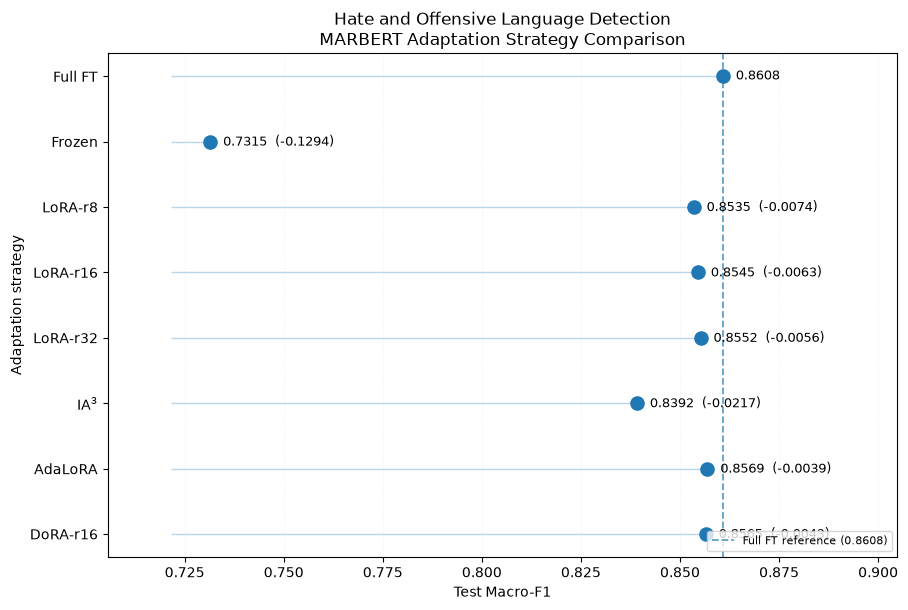

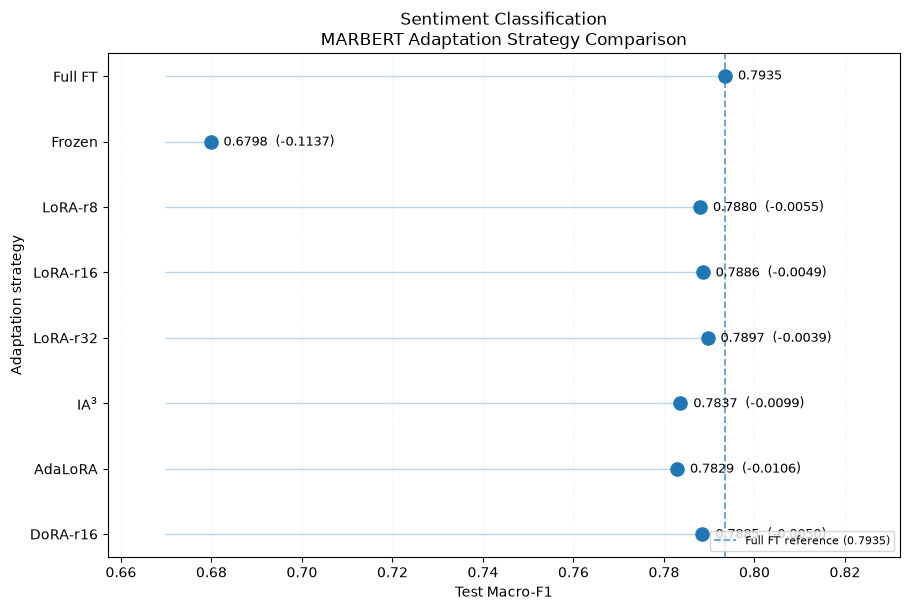

PERFORMANCE FIGURES GENERATED

HOF figure:
D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis\reviewer_ready_results\figures\figure_01_hof_macro_f1_all_methods.png

Sentiment figure:
D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis\reviewer_ready_results\figures\figure_01_sentiment_macro_f1_all_methods.png

Each figure is also exported as PDF.
Numbers in parentheses represent Δ Macro-F1 relative to Full FT.


In [40]:
# ============================================================
# CELL 63 — PUBLICATION-READY PERFORMANCE FIGURES
# ============================================================
#
# Purpose:
#   Visual comparison of all eight adaptation strategies.
#
# Reviewer relevance:
#   - shows that the revised study is not LoRA-only;
#   - includes IA3, AdaLoRA and DoRA;
#   - separates HOF and sentiment;
#   - compares every method against Full FT;
#   - avoids misleading truncated bar charts.
#
# No training.
# No model loading.
# No GPU use.
# ============================================================


# ============================================================
# DISPLAY LABELS
# ============================================================

METHOD_LABELS = {

    "Full_FT":
        "Full FT",

    "Frozen":
        "Frozen",

    "LoRA_r8":
        "LoRA-r8",

    "LoRA_r16":
        "LoRA-r16",

    "LoRA_r32":
        "LoRA-r32",

    "IA3":
        r"IA$^3$",

    "AdaLoRA":
        "AdaLoRA",

    "DoRA_r16":
        "DoRA-r16",
}


# ============================================================
# METHOD ORDER
# ============================================================

PLOT_METHOD_ORDER = [

    "Full_FT",

    "Frozen",

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


# ============================================================
# CREATE ONE FIGURE PER TASK
# ============================================================

for task_name in TASKS:

    # --------------------------------------------------------
    # Select task
    # --------------------------------------------------------

    plot_df = (

        results_df[

            results_df[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # --------------------------------------------------------
    # Scientific order
    # --------------------------------------------------------

    plot_df[
        "_order"
    ] = (

        plot_df[
            "method"
        ]

        .apply(
            PLOT_METHOD_ORDER.index
        )
    )


    plot_df = (

        plot_df

        .sort_values(
            "_order"
        )

        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Full FT reference
    # --------------------------------------------------------

    full_ft_score = float(

        plot_df.loc[

            plot_df[
                "method"
            ]
            ==
            "Full_FT",

            "test_macro_f1",

        ].iloc[0]
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(

        figsize=(
            9.2,
            6.2,
        )
    )


    y_positions = np.arange(

        len(
            plot_df
        )
    )


    # --------------------------------------------------------
    # Horizontal guide lines
    # --------------------------------------------------------

    for y_position in y_positions:

        ax.hlines(

            y=y_position,

            xmin=float(
                plot_df[
                    "test_macro_f1"
                ].min()
            )
            -
            0.01,

            xmax=float(
                plot_df.loc[
                    y_position,
                    "test_macro_f1",
                ]
            ),

            linewidth=1,

            alpha=0.30,
        )


    # --------------------------------------------------------
    # Performance points
    # --------------------------------------------------------

    ax.scatter(

        plot_df[
            "test_macro_f1"
        ],

        y_positions,

        s=90,

        zorder=3,
    )


    # --------------------------------------------------------
    # Full FT reference line
    # --------------------------------------------------------

    ax.axvline(

        full_ft_score,

        linestyle="--",

        linewidth=1.3,

        alpha=0.70,

        label=(
            f"Full FT reference "
            f"({full_ft_score:.4f})"
        ),
    )


    # --------------------------------------------------------
    # Method labels
    # --------------------------------------------------------

    ax.set_yticks(
        y_positions
    )


    ax.set_yticklabels([

        METHOD_LABELS[
            method
        ]

        for method
        in plot_df[
            "method"
        ]
    ])


    # ========================================================
    # SCORE + DELTA ANNOTATIONS
    # ========================================================

    score_range = (

        float(
            plot_df[
                "test_macro_f1"
            ].max()
        )

        -

        float(
            plot_df[
                "test_macro_f1"
            ].min()
        )
    )


    annotation_offset = max(

        score_range
        *
        0.025,

        0.0015,
    )


    for y_position, row in (

        plot_df.iterrows()
    ):

        score = float(

            row[
                "test_macro_f1"
            ]
        )


        delta = (

            score
            -
            full_ft_score
        )


        # ----------------------------------------------------
        # Full FT annotation
        # ----------------------------------------------------

        if (
            row[
                "method"
            ]
            ==
            "Full_FT"
        ):

            annotation = (

                f"{score:.4f}"
            )


        # ----------------------------------------------------
        # Other methods:
        # score and difference from Full FT
        # ----------------------------------------------------

        else:

            annotation = (

                f"{score:.4f}  "
                f"({delta:+.4f})"
            )


        ax.text(

            score
            +
            annotation_offset,

            y_position,

            annotation,

            va="center",

            fontsize=9,
        )


    # ========================================================
    # AXES
    # ========================================================

    minimum_score = float(

        plot_df[
            "test_macro_f1"
        ].min()
    )


    maximum_score = float(

        plot_df[
            "test_macro_f1"
        ].max()
    )


    padding = max(

        (
            maximum_score
            -
            minimum_score
        )
        *
        0.20,

        0.015,
    )


    ax.set_xlim(

        max(
            0,
            minimum_score
            -
            padding
        ),

        min(
            1,
            maximum_score
            +
            padding
            *
            1.7
        ),
    )


    ax.set_xlabel(

        "Test Macro-F1"
    )


    ax.set_ylabel(

        "Adaptation strategy"
    )


    # --------------------------------------------------------
    # Task-specific title
    # --------------------------------------------------------

    if (
        task_name
        ==
        "hof"
    ):

        task_title = (

            "Hate and Offensive "
            "Language Detection"
        )

    else:

        task_title = (

            "Sentiment Classification"
        )


    ax.set_title(

        task_title
        +
        "\n"
        +
        "MARBERT Adaptation Strategy Comparison"
    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(

        axis="x",

        alpha=0.20,

        linestyle=":",
    )


    # --------------------------------------------------------
    # Put best result at top
    # --------------------------------------------------------

    ax.invert_yaxis()


    ax.legend(

        loc="lower right",

        frameon=True,

        fontsize=8,
    )


    fig.tight_layout()


    # ========================================================
    # SAVE HIGH-RESOLUTION PUBLICATION FIGURES
    # ========================================================

    save_figure(

        fig,

        (
            "figure_01_"
            f"{task_name}_"
            "macro_f1_all_methods"
        ),
    )


    plt.show()


# ============================================================
# FIGURE SUMMARY
# ============================================================

print(
    "=" * 110
)

print(
    "PERFORMANCE FIGURES GENERATED"
)

print(
    "=" * 110
)


print()

print(
    "HOF figure:"
)

print(

    FIGURES_DIR
    /
    "figure_01_hof_macro_f1_all_methods.png"
)


print()

print(
    "Sentiment figure:"
)

print(

    FIGURES_DIR
    /
    "figure_01_sentiment_macro_f1_all_methods.png"
)


print()

print(
    "Each figure is also exported as PDF."
)

print(
    "Numbers in parentheses represent "
    "Δ Macro-F1 relative to Full FT."
)

print(
    "=" * 110
)

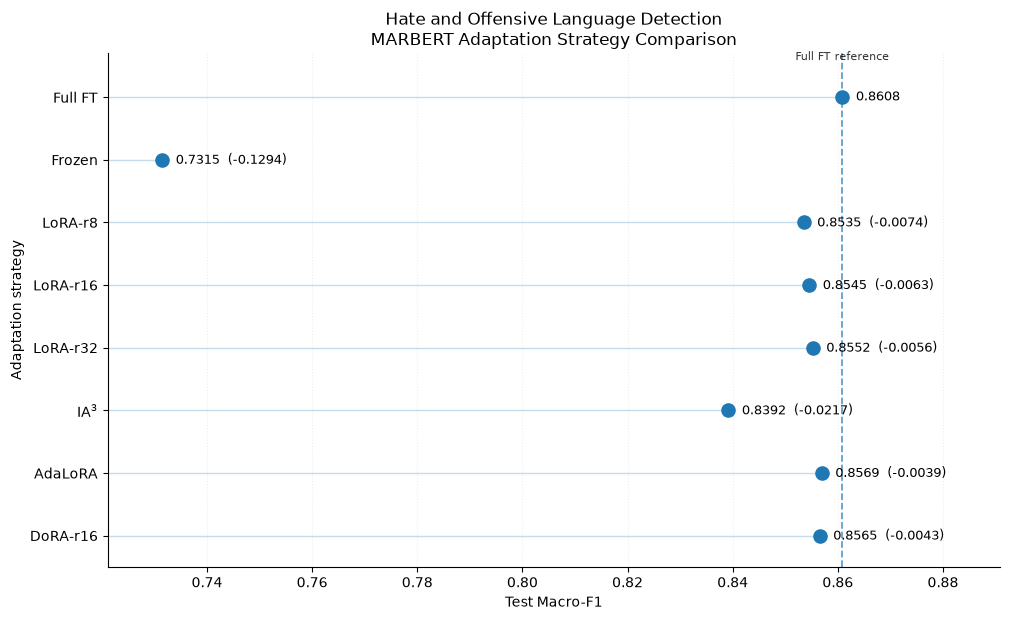

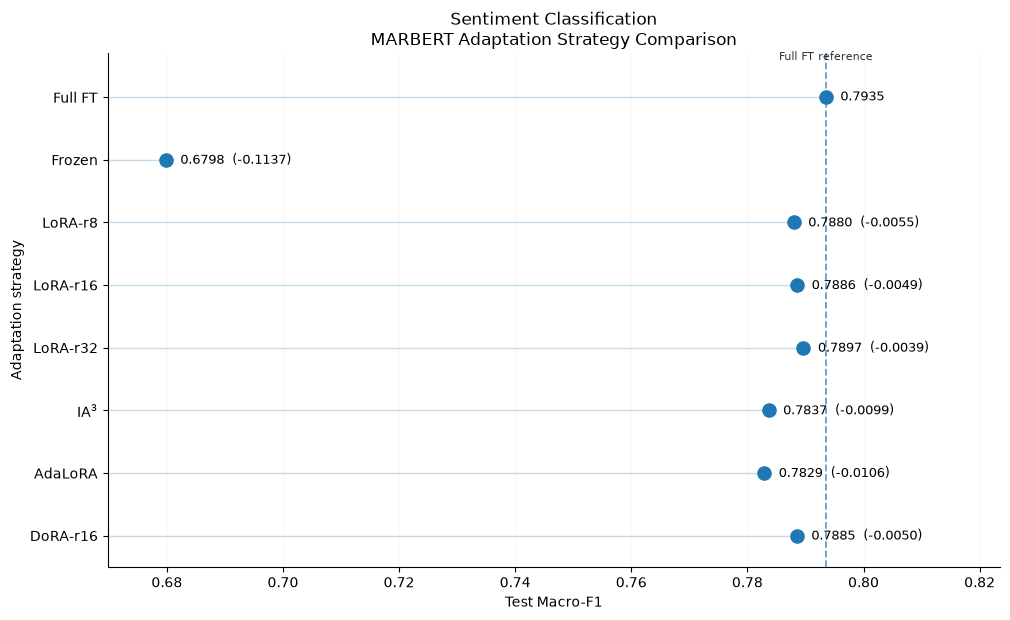

FINAL PERFORMANCE FIGURES GENERATED
D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis\reviewer_ready_results\figures\figure_01_hof_macro_f1_all_methods_FINAL.png
D:\Informatics\MARBERT_Final_Reviewer_Experiments\06_analysis\reviewer_ready_results\figures\figure_01_sentiment_macro_f1_all_methods_FINAL.png

PNG resolution : 300 dpi
Vector format  : PDF also saved
Δ values       : relative to Full FT


In [41]:
# ============================================================
# CELL 63B — FINAL PUBLICATION VERSION OF PERFORMANCE FIGURES
# ============================================================
#
# Improvements over Cell 63:
#   - removes overlapping legend;
#   - directly labels the Full FT reference line;
#   - keeps the complete scale including Frozen;
#   - reports Macro-F1 and Δ vs Full FT;
#   - exports PNG 300 dpi + vector PDF.
#
# No training.
# No GPU use.
# ============================================================


METHOD_LABELS = {

    "Full_FT":
        "Full FT",

    "Frozen":
        "Frozen",

    "LoRA_r8":
        "LoRA-r8",

    "LoRA_r16":
        "LoRA-r16",

    "LoRA_r32":
        "LoRA-r32",

    "IA3":
        r"IA$^3$",

    "AdaLoRA":
        "AdaLoRA",

    "DoRA_r16":
        "DoRA-r16",
}


PLOT_METHOD_ORDER = [

    "Full_FT",

    "Frozen",

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


TASK_TITLES = {

    "hof":
        "Hate and Offensive Language Detection",

    "sentiment":
        "Sentiment Classification",
}


for task_name in TASKS:

    # ========================================================
    # PREPARE TASK DATA
    # ========================================================

    plot_df = (

        results_df[

            results_df[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    plot_df[
        "_order"
    ] = (

        plot_df[
            "method"
        ]

        .apply(
            PLOT_METHOD_ORDER.index
        )
    )


    plot_df = (

        plot_df

        .sort_values(
            "_order"
        )

        .reset_index(
            drop=True
        )
    )


    full_ft_score = float(

        plot_df.loc[

            plot_df[
                "method"
            ]
            ==
            "Full_FT",

            "test_macro_f1",

        ].iloc[0]
    )


    minimum_score = float(

        plot_df[
            "test_macro_f1"
        ].min()
    )


    maximum_score = float(

        plot_df[
            "test_macro_f1"
        ].max()
    )


    score_span = (

        maximum_score
        -
        minimum_score
    )


    left_limit = max(

        0.0,

        minimum_score
        -
        max(
            0.010,
            score_span
            *
            0.08,
        ),
    )


    right_limit = min(

        1.0,

        maximum_score
        +
        max(
            0.030,
            score_span
            *
            0.23,
        ),
    )


    y_positions = np.arange(

        len(
            plot_df
        )
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(

        figsize=(
            10.2,
            6.3,
        )
    )


    # --------------------------------------------------------
    # Horizontal visual guides
    # --------------------------------------------------------

    for y_position, score in zip(

        y_positions,

        plot_df[
            "test_macro_f1"
        ],
    ):

        ax.hlines(

            y=y_position,

            xmin=left_limit,

            xmax=score,

            linewidth=1.0,

            alpha=0.25,
        )


    # --------------------------------------------------------
    # Model points
    # --------------------------------------------------------

    ax.scatter(

        plot_df[
            "test_macro_f1"
        ],

        y_positions,

        s=90,

        zorder=3,
    )


    # --------------------------------------------------------
    # Full FT reference
    # --------------------------------------------------------

    ax.axvline(

        full_ft_score,

        linestyle="--",

        linewidth=1.3,

        alpha=0.70,
    )


    # ========================================================
    # VALUE ANNOTATIONS
    # ========================================================

    text_offset = max(

        0.0025,

        score_span
        *
        0.020,
    )


    for y_position, row in (

        plot_df.iterrows()
    ):

        score = float(

            row[
                "test_macro_f1"
            ]
        )


        if (

            row[
                "method"
            ]
            ==
            "Full_FT"

        ):

            text = (

                f"{score:.4f}"
            )

        else:

            delta = (

                score
                -
                full_ft_score
            )


            text = (

                f"{score:.4f}  "
                f"({delta:+.4f})"
            )


        ax.text(

            score
            +
            text_offset,

            y_position,

            text,

            va="center",

            ha="left",

            fontsize=9,
        )


    # ========================================================
    # DIRECT LABEL FOR REFERENCE LINE
    # ========================================================

    ax.text(

        full_ft_score,

        -0.55,

        "Full FT reference",

        ha="center",

        va="bottom",

        fontsize=8,

        alpha=0.80,
    )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlim(

        left_limit,

        right_limit,
    )


    ax.set_ylim(

        -0.7,

        len(
            plot_df
        )
        -
        0.5,
    )


    ax.set_yticks(

        y_positions
    )


    ax.set_yticklabels([

        METHOD_LABELS[
            method
        ]

        for method
        in plot_df[
            "method"
        ]
    ])


    ax.invert_yaxis()


    ax.set_xlabel(

        "Test Macro-F1"
    )


    ax.set_ylabel(

        "Adaptation strategy"
    )


    ax.set_title(

        TASK_TITLES[
            task_name
        ]
        +
        "\n"
        +
        "MARBERT Adaptation Strategy Comparison"
    )


    ax.grid(

        axis="x",

        linestyle=":",

        alpha=0.20,
    )


    # --------------------------------------------------------
    # Remove unnecessary visual clutter
    # --------------------------------------------------------

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    fig.tight_layout()


    # ========================================================
    # SAVE
    # ========================================================

    save_figure(

        fig,

        (
            "figure_01_"
            f"{task_name}_"
            "macro_f1_all_methods_FINAL"
        ),
    )


    plt.show()


# ============================================================
# FINAL CHECK
# ============================================================

print(
    "=" * 110
)

print(
    "FINAL PERFORMANCE FIGURES GENERATED"
)

print(
    "=" * 110
)


print(

    FIGURES_DIR
    /
    "figure_01_hof_macro_f1_all_methods_FINAL.png"
)


print(

    FIGURES_DIR
    /
    "figure_01_sentiment_macro_f1_all_methods_FINAL.png"
)


print()

print(
    "PNG resolution : 300 dpi"
)

print(
    "Vector format  : PDF also saved"
)

print(
    "Δ values       : relative to Full FT"
)

print(
    "=" * 110
)

TABLE 4 — PERFORMANCE AND TRAINABLE-PARAMETER EFFICIENCY


,task,method,test_macro_f1,delta_macro_f1_vs_full_ft,performance_retention_pct,trainable_parameters,trainable_percentage,parameter_reduction_vs_full_ft_pct
0,hof,Full_FT,0.860849,0.000000,100.000,162842882,100.000000,0.000
1,hof,Frozen,0.731463,-0.129385,84.970,1538,0.000944,99.999
2,hof,LoRA_r8,0.853479,-0.007370,99.144,296450,0.181716,99.818
3,hof,LoRA_r16,0.854548,-0.006301,99.268,591362,0.361835,99.637
4,hof,LoRA_r32,0.855213,-0.005635,99.345,1181186,0.720130,99.275
5,hof,IA3,0.839162,-0.021686,97.481,56834,0.034889,99.965
6,hof,AdaLoRA,0.856931,-0.003917,99.545,444194,0.272033,99.727
7,hof,DoRA_r16,0.856529,-0.004320,99.498,609794,0.373071,99.626
8,sentiment,Full_FT,0.793507,0.000000,100.000,162843651,100.000000,0.000
9,sentiment,Frozen,0.679821,-0.113687,85.673,2307,0.001417,99.999



BEST PEFT — PERFORMANCE RETENTION VS FULL FT


,task,best_peft,macro_f1,delta_vs_full_ft,performance_retained_pct,trainable_pct,parameter_reduction_pct
0,hof,AdaLoRA,0.8569,-0.0039,99.545,0.2720,99.7272
1,sentiment,LoRA_r32,0.7897,-0.0039,99.514,0.7206,99.2742


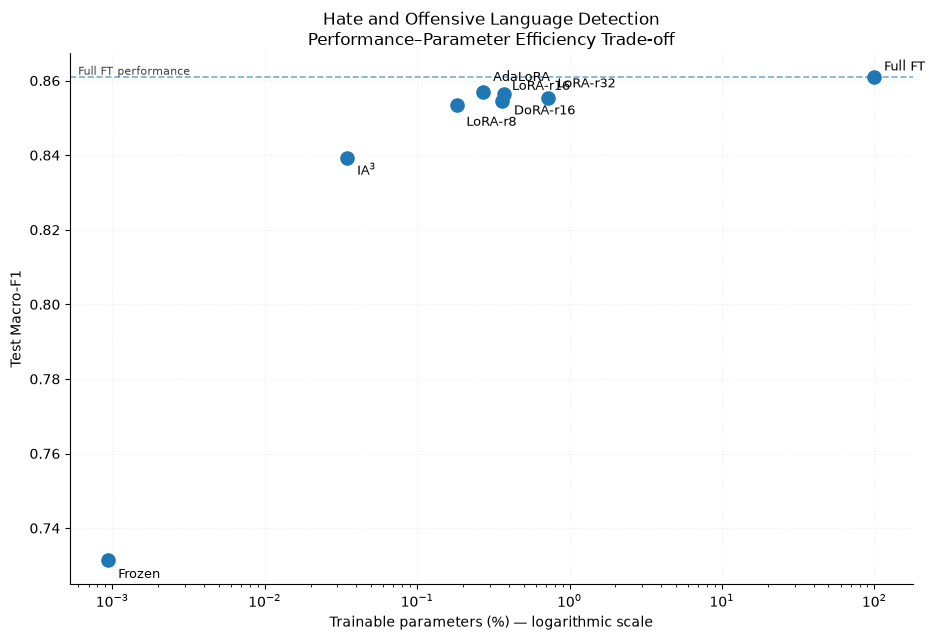

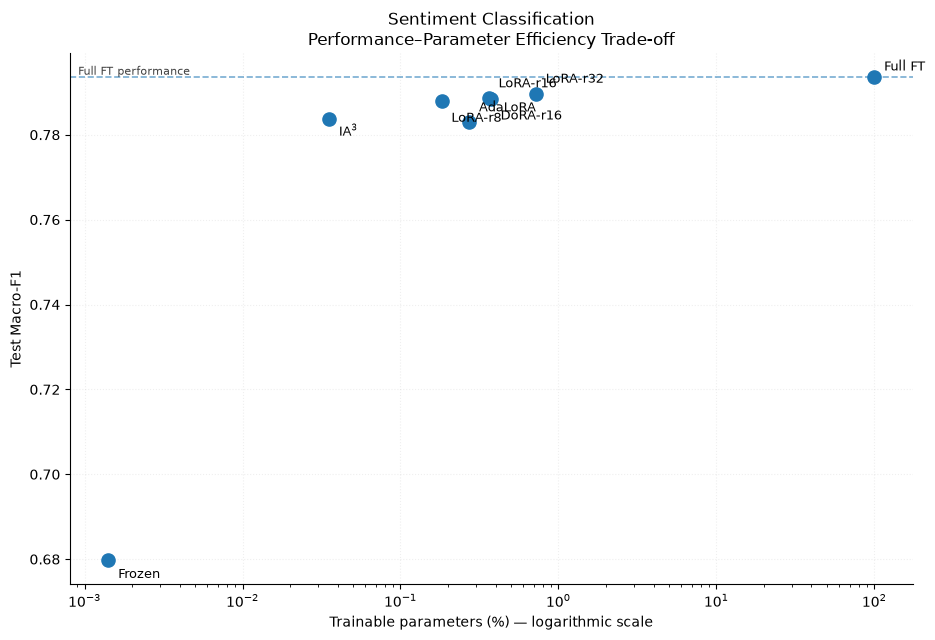


INTERPRETATION GUARDRAIL
This figure supports PARAMETER-EFFICIENCY claims.
It does NOT by itself demonstrate faster training or lower energy consumption.
Runtime and energy must be analysed separately because the methods stopped after different numbers of epochs.


In [42]:
# ============================================================
# CELL 65 — PERFORMANCE vs PARAMETER EFFICIENCY
# ============================================================
#
# Scientific objective:
#   Quantify how much predictive performance is retained
#   while reducing the trainable-parameter budget.
#
# Reviewer relevance:
#   - directly addresses practical parameter efficiency;
#   - compares ALL adaptation strategies;
#   - does not confuse parameter efficiency with runtime;
#   - keeps HOF and sentiment separated;
#   - reports Δ Macro-F1 and % performance retention vs Full FT.
#
# IMPORTANT:
#   This cell analyses TRAINABLE-PARAMETER efficiency only.
#   Runtime / energy will be interpreted separately because
#   early stopping leads to different executed epoch counts.
#
# No training.
# No GPU use.
# ============================================================


# ============================================================
# BUILD PARAMETER-EFFICIENCY TABLE
# ============================================================

parameter_efficiency_rows = []


for task_name in TASKS:

    # --------------------------------------------------------
    # Task results
    # --------------------------------------------------------

    task_df = (

        results_df[

            results_df[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # --------------------------------------------------------
    # Full FT reference
    # --------------------------------------------------------

    full_row = (

        task_df[

            task_df[
                "method"
            ]
            ==
            "Full_FT"

        ]

        .iloc[0]
    )


    full_f1 = float(

        full_row[
            "test_macro_f1"
        ]
    )


    full_trainable = float(

        full_row[
            "trainable_parameters"
        ]
    )


    # --------------------------------------------------------
    # All methods
    # --------------------------------------------------------

    for _, row in task_df.iterrows():

        macro_f1 = float(

            row[
                "test_macro_f1"
            ]
        )


        trainable_parameters = float(

            row[
                "trainable_parameters"
            ]
        )


        trainable_percentage = float(

            row[
                "trainable_percentage"
            ]
        )


        # ----------------------------------------------------
        # Reduction relative to Full FT
        # ----------------------------------------------------

        parameter_reduction_pct = (

            100.0
            *
            (
                1.0
                -
                trainable_parameters
                /
                full_trainable
            )
        )


        # ----------------------------------------------------
        # Macro-F1 loss / gain relative to Full FT
        # ----------------------------------------------------

        delta_macro_f1 = (

            macro_f1
            -
            full_f1
        )


        # ----------------------------------------------------
        # Percentage of Full FT Macro-F1 retained
        # ----------------------------------------------------

        performance_retention_pct = (

            100.0
            *
            macro_f1
            /
            full_f1
        )


        parameter_efficiency_rows.append({

            "task":
                task_name,

            "method":
                row[
                    "method"
                ],

            "test_macro_f1":
                macro_f1,

            "delta_macro_f1_vs_full_ft":
                delta_macro_f1,

            "performance_retention_pct":
                performance_retention_pct,

            "trainable_parameters":
                int(
                    trainable_parameters
                ),

            "trainable_percentage":
                trainable_percentage,

            "parameter_reduction_vs_full_ft_pct":
                parameter_reduction_pct,
        })


parameter_efficiency_table = pd.DataFrame(

    parameter_efficiency_rows
)


# ============================================================
# SCIENTIFIC ORDER
# ============================================================

parameter_efficiency_table[
    "_task_order"
] = (

    parameter_efficiency_table[
        "task"
    ]

    .map({
        "hof": 0,
        "sentiment": 1,
    })
)


parameter_efficiency_table[
    "_method_order"
] = (

    parameter_efficiency_table[
        "method"
    ]

    .map(
        METHOD_ORDER
    )
)


parameter_efficiency_table = (

    parameter_efficiency_table

    .sort_values(
        [
            "_task_order",
            "_method_order",
        ]
    )

    .drop(
        columns=[
            "_task_order",
            "_method_order",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# SAVE TABLE
# ============================================================

save_table(

    parameter_efficiency_table,

    "table_04_parameter_efficiency",
)


print(
    "=" * 125
)

print(
    "TABLE 4 — PERFORMANCE AND TRAINABLE-PARAMETER EFFICIENCY"
)

print(
    "=" * 125
)


display(

    parameter_efficiency_table

    .round({
        "test_macro_f1": 6,
        "delta_macro_f1_vs_full_ft": 6,
        "performance_retention_pct": 3,
        "trainable_percentage": 6,
        "parameter_reduction_vs_full_ft_pct": 3,
    })
)


# ============================================================
# BEST PEFT EFFICIENCY SUMMARY
# ============================================================

print()

print(
    "=" * 125
)

print(
    "BEST PEFT — PERFORMANCE RETENTION VS FULL FT"
)

print(
    "=" * 125
)


PEFT_METHODS = [

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


best_efficiency_rows = []


for task_name in TASKS:

    task_peft = (

        parameter_efficiency_table[

            (
                parameter_efficiency_table[
                    "task"
                ]
                ==
                task_name
            )

            &

            (
                parameter_efficiency_table[
                    "method"
                ]
                .isin(
                    PEFT_METHODS
                )
            )

        ]

        .sort_values(
            "test_macro_f1",
            ascending=False,
        )
    )


    best = (

        task_peft
        .iloc[0]
    )


    best_efficiency_rows.append({

        "task":
            task_name,

        "best_peft":
            best[
                "method"
            ],

        "macro_f1":
            best[
                "test_macro_f1"
            ],

        "delta_vs_full_ft":
            best[
                "delta_macro_f1_vs_full_ft"
            ],

        "performance_retained_pct":
            best[
                "performance_retention_pct"
            ],

        "trainable_pct":
            best[
                "trainable_percentage"
            ],

        "parameter_reduction_pct":
            best[
                "parameter_reduction_vs_full_ft_pct"
            ],
    })


best_parameter_efficiency = pd.DataFrame(

    best_efficiency_rows
)


display(

    best_parameter_efficiency

    .round(4)
)


# ============================================================
# FIGURE — PERFORMANCE vs TRAINABLE PARAMETERS
# ============================================================

TASK_TITLES = {

    "hof":
        "Hate and Offensive Language Detection",

    "sentiment":
        "Sentiment Classification",
}


METHOD_LABELS = {

    "Full_FT":
        "Full FT",

    "Frozen":
        "Frozen",

    "LoRA_r8":
        "LoRA-r8",

    "LoRA_r16":
        "LoRA-r16",

    "LoRA_r32":
        "LoRA-r32",

    "IA3":
        r"IA$^3$",

    "AdaLoRA":
        "AdaLoRA",

    "DoRA_r16":
        "DoRA-r16",
}


# ------------------------------------------------------------
# Manual annotation offsets
#
# Needed because several PEFT methods occupy a very compact
# region of the performance-efficiency space.
# ------------------------------------------------------------

ANNOTATION_OFFSETS = {

    "Full_FT":
        (7, 5),

    "Frozen":
        (7, -13),

    "LoRA_r8":
        (7, -15),

    "LoRA_r16":
        (7, 8),

    "LoRA_r32":
        (7, 8),

    "IA3":
        (7, -12),

    "AdaLoRA":
        (7, 8),

    "DoRA_r16":
        (7, -15),
}


for task_name in TASKS:

    plot_df = (

        parameter_efficiency_table[

            parameter_efficiency_table[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(

        figsize=(
            9.5,
            6.5,
        )
    )


    ax.scatter(

        plot_df[
            "trainable_percentage"
        ],

        plot_df[
            "test_macro_f1"
        ],

        s=90,

        zorder=3,
    )


    # ========================================================
    # LABEL EACH METHOD
    # ========================================================

    for _, row in plot_df.iterrows():

        method_name = (

            row[
                "method"
            ]
        )


        offset = (

            ANNOTATION_OFFSETS[
                method_name
            ]
        )


        ax.annotate(

            METHOD_LABELS[
                method_name
            ],

            (

                row[
                    "trainable_percentage"
                ],

                row[
                    "test_macro_f1"
                ],
            ),

            xytext=offset,

            textcoords="offset points",

            fontsize=9,
        )


    # ========================================================
    # AXIS
    #
    # Log scale is necessary because:
    #
    # Frozen    ≈ 0.001%
    # IA3       ≈ 0.035%
    # LoRA      ≈ 0.18–0.72%
    # Full FT   = 100%
    #
    # ========================================================

    ax.set_xscale(
        "log"
    )


    ax.set_xlabel(

        "Trainable parameters (%) — logarithmic scale"
    )


    ax.set_ylabel(

        "Test Macro-F1"
    )


    ax.set_title(

        TASK_TITLES[
            task_name
        ]
        +
        "\n"
        +
        "Performance–Parameter Efficiency Trade-off"
    )


    ax.grid(

        alpha=0.20,

        linestyle=":",
    )


    # ========================================================
    # FULL FT REFERENCE LINE
    # ========================================================

    full_ft_f1 = float(

        plot_df.loc[

            plot_df[
                "method"
            ]
            ==
            "Full_FT",

            "test_macro_f1",

        ].iloc[0]
    )


    ax.axhline(

        full_ft_f1,

        linestyle="--",

        linewidth=1.2,

        alpha=0.60,
    )


    ax.text(

        ax.get_xlim()[0],

        full_ft_f1,

        "  Full FT performance",

        va="bottom",

        fontsize=8,

        alpha=0.75,
    )


    # ========================================================
    # CLEAN PUBLICATION STYLE
    # ========================================================

    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    fig.tight_layout()


    # ========================================================
    # SAVE
    # ========================================================

    save_figure(

        fig,

        (
            "figure_02_"
            f"{task_name}_"
            "performance_parameter_efficiency"
        ),
    )


    plt.show()


# ============================================================
# SCIENTIFIC INTERPRETATION GUARDRAIL
# ============================================================

print()

print(
    "=" * 125
)

print(
    "INTERPRETATION GUARDRAIL"
)

print(
    "=" * 125
)


print(
    "This figure supports PARAMETER-EFFICIENCY claims."
)

print(
    "It does NOT by itself demonstrate faster training "
    "or lower energy consumption."
)

print(
    "Runtime and energy must be analysed separately because "
    "the methods stopped after different numbers of epochs."
)

print(
    "=" * 125
)

TABLE 4 — PERFORMANCE AND TRAINABLE-PARAMETER EFFICIENCY


,task,method,test_macro_f1,delta_macro_f1_vs_full_ft,performance_retention_pct,trainable_parameters,trainable_percentage,parameter_reduction_vs_full_ft_pct
0,hof,Full_FT,0.860849,0.000000,100.000,162842882,100.000000,0.000
1,hof,Frozen,0.731463,-0.129385,84.970,1538,0.000944,99.999
2,hof,LoRA_r8,0.853479,-0.007370,99.144,296450,0.181716,99.818
3,hof,LoRA_r16,0.854548,-0.006301,99.268,591362,0.361835,99.637
4,hof,LoRA_r32,0.855213,-0.005635,99.345,1181186,0.720130,99.275
5,hof,IA3,0.839162,-0.021686,97.481,56834,0.034889,99.965
6,hof,AdaLoRA,0.856931,-0.003917,99.545,444194,0.272033,99.727
7,hof,DoRA_r16,0.856529,-0.004320,99.498,609794,0.373071,99.626
8,sentiment,Full_FT,0.793507,0.000000,100.000,162843651,100.000000,0.000
9,sentiment,Frozen,0.679821,-0.113687,85.673,2307,0.001417,99.999



BEST PEFT — PERFORMANCE RETENTION VS FULL FT


,task,best_peft,macro_f1,delta_vs_full_ft,performance_retained_pct,trainable_pct,parameter_reduction_pct
0,hof,AdaLoRA,0.8569,-0.0039,99.545,0.2720,99.7272
1,sentiment,LoRA_r32,0.7897,-0.0039,99.514,0.7206,99.2742


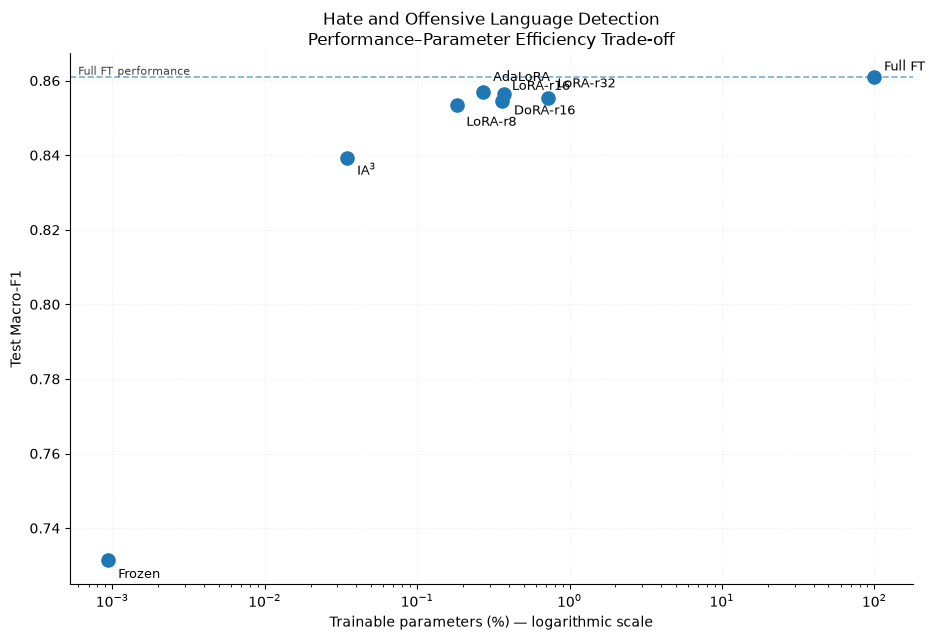

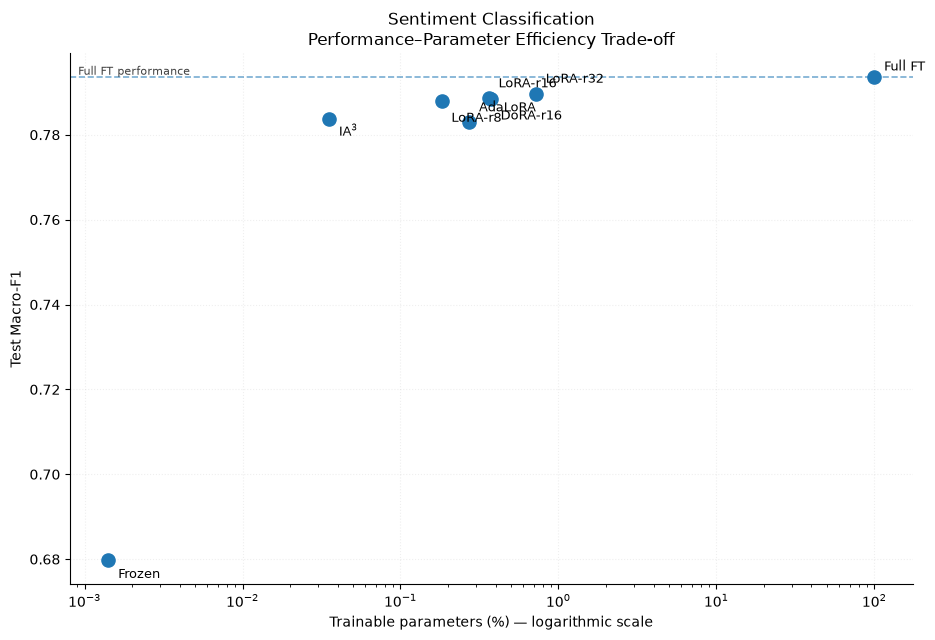


INTERPRETATION GUARDRAIL
This figure supports PARAMETER-EFFICIENCY claims.
It does NOT by itself demonstrate faster training or lower energy consumption.
Runtime and energy must be analysed separately because the methods stopped after different numbers of epochs.


In [43]:
# ============================================================
# CELL 65 — PERFORMANCE vs PARAMETER EFFICIENCY
# ============================================================
#
# Scientific objective:
#   Quantify how much predictive performance is retained
#   while reducing the trainable-parameter budget.
#
# Reviewer relevance:
#   - directly addresses practical parameter efficiency;
#   - compares ALL adaptation strategies;
#   - does not confuse parameter efficiency with runtime;
#   - keeps HOF and sentiment separated;
#   - reports Δ Macro-F1 and % performance retention vs Full FT.
#
# IMPORTANT:
#   This cell analyses TRAINABLE-PARAMETER efficiency only.
#   Runtime / energy will be interpreted separately because
#   early stopping leads to different executed epoch counts.
#
# No training.
# No GPU use.
# ============================================================


# ============================================================
# BUILD PARAMETER-EFFICIENCY TABLE
# ============================================================

parameter_efficiency_rows = []


for task_name in TASKS:

    # --------------------------------------------------------
    # Task results
    # --------------------------------------------------------

    task_df = (

        results_df[

            results_df[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # --------------------------------------------------------
    # Full FT reference
    # --------------------------------------------------------

    full_row = (

        task_df[

            task_df[
                "method"
            ]
            ==
            "Full_FT"

        ]

        .iloc[0]
    )


    full_f1 = float(

        full_row[
            "test_macro_f1"
        ]
    )


    full_trainable = float(

        full_row[
            "trainable_parameters"
        ]
    )


    # --------------------------------------------------------
    # All methods
    # --------------------------------------------------------

    for _, row in task_df.iterrows():

        macro_f1 = float(

            row[
                "test_macro_f1"
            ]
        )


        trainable_parameters = float(

            row[
                "trainable_parameters"
            ]
        )


        trainable_percentage = float(

            row[
                "trainable_percentage"
            ]
        )


        # ----------------------------------------------------
        # Reduction relative to Full FT
        # ----------------------------------------------------

        parameter_reduction_pct = (

            100.0
            *
            (
                1.0
                -
                trainable_parameters
                /
                full_trainable
            )
        )


        # ----------------------------------------------------
        # Macro-F1 loss / gain relative to Full FT
        # ----------------------------------------------------

        delta_macro_f1 = (

            macro_f1
            -
            full_f1
        )


        # ----------------------------------------------------
        # Percentage of Full FT Macro-F1 retained
        # ----------------------------------------------------

        performance_retention_pct = (

            100.0
            *
            macro_f1
            /
            full_f1
        )


        parameter_efficiency_rows.append({

            "task":
                task_name,

            "method":
                row[
                    "method"
                ],

            "test_macro_f1":
                macro_f1,

            "delta_macro_f1_vs_full_ft":
                delta_macro_f1,

            "performance_retention_pct":
                performance_retention_pct,

            "trainable_parameters":
                int(
                    trainable_parameters
                ),

            "trainable_percentage":
                trainable_percentage,

            "parameter_reduction_vs_full_ft_pct":
                parameter_reduction_pct,
        })


parameter_efficiency_table = pd.DataFrame(

    parameter_efficiency_rows
)


# ============================================================
# SCIENTIFIC ORDER
# ============================================================

parameter_efficiency_table[
    "_task_order"
] = (

    parameter_efficiency_table[
        "task"
    ]

    .map({
        "hof": 0,
        "sentiment": 1,
    })
)


parameter_efficiency_table[
    "_method_order"
] = (

    parameter_efficiency_table[
        "method"
    ]

    .map(
        METHOD_ORDER
    )
)


parameter_efficiency_table = (

    parameter_efficiency_table

    .sort_values(
        [
            "_task_order",
            "_method_order",
        ]
    )

    .drop(
        columns=[
            "_task_order",
            "_method_order",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# SAVE TABLE
# ============================================================

save_table(

    parameter_efficiency_table,

    "table_04_parameter_efficiency",
)


print(
    "=" * 125
)

print(
    "TABLE 4 — PERFORMANCE AND TRAINABLE-PARAMETER EFFICIENCY"
)

print(
    "=" * 125
)


display(

    parameter_efficiency_table

    .round({
        "test_macro_f1": 6,
        "delta_macro_f1_vs_full_ft": 6,
        "performance_retention_pct": 3,
        "trainable_percentage": 6,
        "parameter_reduction_vs_full_ft_pct": 3,
    })
)


# ============================================================
# BEST PEFT EFFICIENCY SUMMARY
# ============================================================

print()

print(
    "=" * 125
)

print(
    "BEST PEFT — PERFORMANCE RETENTION VS FULL FT"
)

print(
    "=" * 125
)


PEFT_METHODS = [

    "LoRA_r8",

    "LoRA_r16",

    "LoRA_r32",

    "IA3",

    "AdaLoRA",

    "DoRA_r16",
]


best_efficiency_rows = []


for task_name in TASKS:

    task_peft = (

        parameter_efficiency_table[

            (
                parameter_efficiency_table[
                    "task"
                ]
                ==
                task_name
            )

            &

            (
                parameter_efficiency_table[
                    "method"
                ]
                .isin(
                    PEFT_METHODS
                )
            )

        ]

        .sort_values(
            "test_macro_f1",
            ascending=False,
        )
    )


    best = (

        task_peft
        .iloc[0]
    )


    best_efficiency_rows.append({

        "task":
            task_name,

        "best_peft":
            best[
                "method"
            ],

        "macro_f1":
            best[
                "test_macro_f1"
            ],

        "delta_vs_full_ft":
            best[
                "delta_macro_f1_vs_full_ft"
            ],

        "performance_retained_pct":
            best[
                "performance_retention_pct"
            ],

        "trainable_pct":
            best[
                "trainable_percentage"
            ],

        "parameter_reduction_pct":
            best[
                "parameter_reduction_vs_full_ft_pct"
            ],
    })


best_parameter_efficiency = pd.DataFrame(

    best_efficiency_rows
)


display(

    best_parameter_efficiency

    .round(4)
)


# ============================================================
# FIGURE — PERFORMANCE vs TRAINABLE PARAMETERS
# ============================================================

TASK_TITLES = {

    "hof":
        "Hate and Offensive Language Detection",

    "sentiment":
        "Sentiment Classification",
}


METHOD_LABELS = {

    "Full_FT":
        "Full FT",

    "Frozen":
        "Frozen",

    "LoRA_r8":
        "LoRA-r8",

    "LoRA_r16":
        "LoRA-r16",

    "LoRA_r32":
        "LoRA-r32",

    "IA3":
        r"IA$^3$",

    "AdaLoRA":
        "AdaLoRA",

    "DoRA_r16":
        "DoRA-r16",
}


# ------------------------------------------------------------
# Manual annotation offsets
#
# Needed because several PEFT methods occupy a very compact
# region of the performance-efficiency space.
# ------------------------------------------------------------

ANNOTATION_OFFSETS = {

    "Full_FT":
        (7, 5),

    "Frozen":
        (7, -13),

    "LoRA_r8":
        (7, -15),

    "LoRA_r16":
        (7, 8),

    "LoRA_r32":
        (7, 8),

    "IA3":
        (7, -12),

    "AdaLoRA":
        (7, 8),

    "DoRA_r16":
        (7, -15),
}


for task_name in TASKS:

    plot_df = (

        parameter_efficiency_table[

            parameter_efficiency_table[
                "task"
            ]
            ==
            task_name

        ]

        .copy()
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(

        figsize=(
            9.5,
            6.5,
        )
    )


    ax.scatter(

        plot_df[
            "trainable_percentage"
        ],

        plot_df[
            "test_macro_f1"
        ],

        s=90,

        zorder=3,
    )


    # ========================================================
    # LABEL EACH METHOD
    # ========================================================

    for _, row in plot_df.iterrows():

        method_name = (

            row[
                "method"
            ]
        )


        offset = (

            ANNOTATION_OFFSETS[
                method_name
            ]
        )


        ax.annotate(

            METHOD_LABELS[
                method_name
            ],

            (

                row[
                    "trainable_percentage"
                ],

                row[
                    "test_macro_f1"
                ],
            ),

            xytext=offset,

            textcoords="offset points",

            fontsize=9,
        )


    # ========================================================
    # AXIS
    #
    # Log scale is necessary because:
    #
    # Frozen    ≈ 0.001%
    # IA3       ≈ 0.035%
    # LoRA      ≈ 0.18–0.72%
    # Full FT   = 100%
    #
    # ========================================================

    ax.set_xscale(
        "log"
    )


    ax.set_xlabel(

        "Trainable parameters (%) — logarithmic scale"
    )


    ax.set_ylabel(

        "Test Macro-F1"
    )


    ax.set_title(

        TASK_TITLES[
            task_name
        ]
        +
        "\n"
        +
        "Performance–Parameter Efficiency Trade-off"
    )


    ax.grid(

        alpha=0.20,

        linestyle=":",
    )


    # ========================================================
    # FULL FT REFERENCE LINE
    # ========================================================

    full_ft_f1 = float(

        plot_df.loc[

            plot_df[
                "method"
            ]
            ==
            "Full_FT",

            "test_macro_f1",

        ].iloc[0]
    )


    ax.axhline(

        full_ft_f1,

        linestyle="--",

        linewidth=1.2,

        alpha=0.60,
    )


    ax.text(

        ax.get_xlim()[0],

        full_ft_f1,

        "  Full FT performance",

        va="bottom",

        fontsize=8,

        alpha=0.75,
    )


    # ========================================================
    # CLEAN PUBLICATION STYLE
    # ========================================================

    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    fig.tight_layout()


    # ========================================================
    # SAVE
    # ========================================================

    save_figure(

        fig,

        (
            "figure_02_"
            f"{task_name}_"
            "performance_parameter_efficiency"
        ),
    )


    plt.show()


# ============================================================
# SCIENTIFIC INTERPRETATION GUARDRAIL
# ============================================================

print()

print(
    "=" * 125
)

print(
    "INTERPRETATION GUARDRAIL"
)

print(
    "=" * 125
)


print(
    "This figure supports PARAMETER-EFFICIENCY claims."
)

print(
    "It does NOT by itself demonstrate faster training "
    "or lower energy consumption."
)

print(
    "Runtime and energy must be analysed separately because "
    "the methods stopped after different numbers of epochs."
)

print(
    "=" * 125
)